# **Taller — Predicción de accidentalidad**

> Aprendizaje Automático  
> Taller, Semestre 2026-1  
> Clasificación binaria · Manejo de clases desbalanceadas · Datos en SQLite  
> Profesor: Marco Teran  
> Equipo: Sara Martinez, Kelly Enriquez, Heider Zapata y Yeison Londoño

---

## **1. Librerías y configuración inicial**

In [1]:
import sqlite3
import pandas as pd
import warnings
from typing import Tuple

# Configuración para mejorar la legibilidad en Jupyter
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Semilla de reproducibilidad
RANDOM_STATE = 42

# Ruta relativa a la base de datos (misma carpeta que el notebook)
DB_PATH = 'data_accidentes.sqlite3'

---

## **2. Importar datos y optimizar RAM**

### **2.1. Conexión a la base de datos SQLite con sqlite3**



In [2]:
def extraer_datos_sqlite(ruta_db: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Se conecta a la base de datos SQLite, extrae las tablas necesarias parseando 
    la columna temporal 'TW' y retorna los DataFrames. Asegura el cierre de la conexión.
    
    Args:
        ruta_db (str): Ruta al archivo .sqlite3
        
    Returns:
        Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]: (accidentes, clima, raw)
    """
    print(f"Iniciando conexión a la base de datos: '{ruta_db}'...")
    con = None
    
    try:
        # 1. Establecer conexión
        con = sqlite3.connect(ruta_db)
        
        # 2. Lectura y parseo estricto de fechas
        print("Extrayendo y parseando tabla 'accidentes'...")
        accidentes = pd.read_sql('SELECT * FROM accidentes', con, parse_dates=['TW'])
        
        print("Extrayendo y parseando tabla 'clima'...")
        clima = pd.read_sql('SELECT * FROM clima', con, parse_dates=['TW'])
        
        print("Extrayendo y parseando tabla 'raw_accidentes'...")
        raw = pd.read_sql('SELECT * FROM raw_accidentes', con, parse_dates=['TW'])
        
        print("¡Extracción exitosa!")
        
    except sqlite3.Error as e:
        print(f"Error crítico al interactuar con SQLite: {e}")
        raise
        
    finally:
        # 3. Cierre seguro de la conexión
        if con:
            con.close()
            print("Conexión a SQLite cerrada correctamente.")
            
    return accidentes, clima, raw

In [3]:
# Ejecución de la ingesta
df_accidentes, df_clima, df_raw = extraer_datos_sqlite(DB_PATH)

# Verificación visual rápida y revisión de tipos de dato en TW
print("\n" + "="*50)
print(f"Info df_accidentes: TW es tipo {df_accidentes['TW'].dtype}")
display(df_accidentes.head(3))

print("\n" + "="*50)
print(f"Info df_clima: TW es tipo {df_clima['TW'].dtype}")
display(df_clima.head(3))

print("\n" + "="*50)
print(f"Info df_raw: TW es tipo {df_raw['TW'].dtype}")
display(df_raw.head(3))

Iniciando conexión a la base de datos: 'data_accidentes.sqlite3'...
Extrayendo y parseando tabla 'accidentes'...
Extrayendo y parseando tabla 'clima'...
Extrayendo y parseando tabla 'raw_accidentes'...
¡Extracción exitosa!
Conexión a SQLite cerrada correctamente.

Info df_accidentes: TW es tipo datetime64[ns]


,TW,BARRIO,Lat,Lon,Dia_sem,Mes,Dia,Hora
0,2017-07-20 08:00:00,sandiego,6.233985,-75.570146,JUEVES,7,20,8
1,2017-06-15 16:00:00,lasacacias,6.238844,-75.600280,JUEVES,6,15,16
2,2017-07-02 16:00:00,lopezdemesa,6.285074,-75.584306,DOMINGO,7,2,16



Info df_clima: TW es tipo datetime64[ns]


,TW,BARRIO,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
2,2017-01-01 02:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,1.02,NaN,0.44,0.0,2.997



Info df_raw: TW es tipo datetime64[ns]


,Lon,Lat,OBJECTID,RADICADO,HORA,Dia_sem,PERIODO,CLASE,DIRECCION,DIRECCION_ENC,CBML,TIPO_GEOCOD,GRAVEDAD,BARRIO,COMUNA,DISENO,Mes,Dia,FECHA,MES_NOMBRE,Hora_num,TW
0,-75.570146,6.233985,504352,1590356,08:00 AM,JUEVES,2017,Caida Ocupante,CR 43 A CL 33,CR 043 A 033 000 00000,1020,Malla vial,HERIDO,sandiego,La Candelaria,Interseccion,7,20,2017-07-20,None,8,2017-07-20 08:00:00
1,-75.600280,6.238844,504353,1586285,04:50 PM,JUEVES,2017,Choque,CR 80 CL 33,CR 080 033 000 00000,1109,Malla vial,SOLO DAÑOS,lasacacias,Laureles Estadio,Glorieta,6,15,2017-06-15,None,16,2017-06-15 16:00:00
2,-75.584306,6.285074,504354,1588185,04:20 PM,DOMINGO,2017,Choque,CR 80 CL 80 A,CR 080 080 A 000 00000,0710,Malla vial,HERIDO,lopezdemesa,Robledo,Tramo de via,7,2,2017-07-02,None,16,2017-07-02 16:00:00


### **2.2. Optimización de memoria RAM**

#### 2.2.1 Diagnóstico

La tabla `clima` con 7,991,780 registros consume inicialmente ~2.1 GB de RAM bajo tipos crudos (`float64` y `object`). En entornos locales, continuar sin optimizar podría causar un colapso del kernel por desbordamiento de memoria. A continuación se mide el consumo inicial de cada tabla antes de aplicar cualquier transformación.

In [4]:
def diagnosticar_recursos_dataframes(
    accidentes: pd.DataFrame, 
    clima: pd.DataFrame, 
    raw: pd.DataFrame
) -> None:
    """
    Analiza y despliega de forma tabular y legible el tamaño en memoria RAM,
    el número de registros y las dimensiones de los tres DataFrames cargados.
    
    Args:
        accidentes (pd.DataFrame): DataFrame de accidentes agregados.
        clima (pd.DataFrame): DataFrame con la matriz climática barrio-hora.
        raw (pd.DataFrame): DataFrame de accidentes individuales en crudo.
    """
    dfs = {
        'df_accidentes': accidentes,
        'df_clima': clima,
        'df_raw': raw
    }
    
    registros_diagnostico = []
    
    print("=== DIAGNÓSTICO DE CONSUMO DE RECURSOS EN MEMORIA RAM ===")
    
    for nombre, df in dfs.items():
        # memory_usage(deep=True) evalúa el costo real de objetos/strings en bytes
        memoria_bytes = df.memory_usage(deep=True).sum()
        memoria_mb = memoria_bytes / (1024 ** 2)
        
        registros_diagnostico.append({
            'DataFrame': nombre,
            'Filas (N)': f"{df.shape[0]:,}",
            'Columnas (D)': df.shape[1],
            'RAM Usada (MB)': round(memoria_mb, 2),
            'Tipo de Carga': 'Ligera (<50MB)' if memoria_mb < 50 else ('Moderada (50-500MB)' if memoria_mb < 500 else 'Pesada (>500MB)')
        })
        
    # Crear un DataFrame resumen para visualización limpia
    df_resumen = pd.DataFrame(registros_diagnostico)
    display(df_resumen)
    
    # Evaluar viabilidad local general
    total_ram_mb = df_resumen['RAM Usada (MB)'].sum()
    print(f"\nConsumo total inicial en RAM: {total_ram_mb:.2f} MB")
    
    print("\n💡 RECOMENDACIÓN:")
    if total_ram_mb < 200:
        print("-> Viabilidad: ALTA. Los datos base pesan muy poco. Puedes trabajar en tu máquina local sin problema.")
        print("   Nota: Ten presente que al realizar el LEFT JOIN con 'df_clima' el dataset crecerá, pero seguirá siendo perfectamente manejable.")
    elif total_ram_mb < 1000:
        print("-> Viabilidad: MODERADA. Monitorea los procesos de optimización de hiperparámetros de modelos de ensamble.")
    else:
        print("-> Viabilidad: CRÍTICA. Se sugiere aplicar optimización de tipos de datos (downcasting) o usar entornos de nube.")

In [5]:
# Ejecución del diagnóstico pasándole las variables creadas en la celda anterior
diagnosticar_recursos_dataframes(df_accidentes, df_clima, df_raw)

=== DIAGNÓSTICO DE CONSUMO DE RECURSOS EN MEMORIA RAM ===


,DataFrame,Filas (N),Columnas (D),RAM Usada (MB),Tipo de Carga
0,df_accidentes,"120,587",8,18.82,Ligera (<50MB)
1,df_clima,"7,991,780",15,2093.03,Pesada (>500MB)
2,df_raw,"125,122",22,105.74,Moderada (50-500MB)



Consumo total inicial en RAM: 2217.59 MB

💡 RECOMENDACIÓN:
-> Viabilidad: CRÍTICA. Se sugiere aplicar optimización de tipos de datos (downcasting) o usar entornos de nube.


#### 2.2.2. Protocolo de tratamiento aplicado

- **Downcasting numérico** (`float64` → `float32`): Las 11 variables continuas meteorológicas se transforman de `float64` a `float32`. Mientras que `float64` ofrece una precisión de 15 a 17 decimales significativos, `float32` retiene hasta 7 dígitos. Dado que los sensores climáticos tienen una incertidumbre física intrínseca de ±0.1 a ±0.5 unidades, la reducción descarta el ruido digital de los decimales lejanos conservando el 100% de la señal explicativa y reduciendo el peso numérico a la mitad.

- **Categorización sincronizada global** (`str` → `category`): Las columnas de texto como `BARRIO`, `summary` e `icon` concentran el 65% del peso total de la RAM (~1.36 GB) por almacenar strings repetitivos en millones de filas. Al convertirlas a tipo categórico, pandas almacena un único mapa indexado y reemplaza cada ocurrencia por un entero ligero. Para evitar desalineación entre tablas, se extrae un `CategoricalDtype` maestro global y se aplica de forma idéntica a `df_clima`, `df_accidentes` y `df_raw` — garantizando que el mismo índice represente el mismo barrio en las tres tablas.

#### 2.2.3 Auditoría de seguridad numérica

Antes de reducir los tipos numéricos, se validan los rangos de cada variable para confirmar que el cambio de `float64` a `float32` no corrompe ningún valor. Si algún número supera los límites de `float32`, la conversión lo truncaría silenciosamente.

In [6]:
def auditar_limites_variables(df: pd.DataFrame, nombre_df: str) -> None:
    """
    Evalúa los rangos de las variables numéricas y la cardinalidad de las categóricas
    para confirmar si es seguro aplicar downcasting (optimización de memoria).
    """
    print(f"=== AUDITORÍA DE SEGURIDAD PARA DOWNCASTING: {nombre_df} ===\n")
    
    perfil = []
    for col in df.columns:
        tipo = df[col].dtype
        
        if 'int' in str(tipo) or 'float' in str(tipo):
            val_min = df[col].min()
            val_max = df[col].max()
            perfil.append({
                'Columna': col,
                'Tipo Actual': str(tipo),
                'Mínimo': val_min,
                'Máximo': val_max,
                'Recomendación Segura': 'int8' if ('int' in str(tipo) and val_min >= -128 and val_max <= 127) else 'float32' if 'float' in str(tipo) else 'Mantener'
            })
            
        elif tipo == 'object':
            cardinalidad = df[col].nunique()
            perfil.append({
                'Columna': col,
                'Tipo Actual': str(tipo),
                'Mínimo': f"N/A ({cardinalidad} únicos)",
                'Máximo': 'N/A',
                'Recomendación Segura': 'category' if cardinalidad < (len(df) * 0.1) else 'Mantener'
            })
            
    df_perfil = pd.DataFrame(perfil)
    display(df_perfil)

# Ejecutamos la auditoría en la tabla que nos causa el cuello de botella
auditar_limites_variables(df_clima, "df_clima")

=== AUDITORÍA DE SEGURIDAD PARA DOWNCASTING: df_clima ===



,Columna,Tipo Actual,Mínimo,Máximo,Recomendación Segura
0,BARRIO,object,N/A (319 únicos),N/A,category
1,summary,object,N/A (20 únicos),N/A,category
2,icon,object,N/A (8 únicos),N/A,category
3,precipIntensity,float64,0.0,20.8236,float32
4,precipProbability,float64,0.0,1.0,float32
5,temperature,float64,4.51,35.99,float32
6,apparentTemperature,float64,4.51,38.06,float32
7,dewPoint,float64,2.16,24.04,float32
8,humidity,float64,0.17,1.0,float32
9,windSpeed,float64,0.0,15.26,float32


> Los rangos de todas las variables numéricas están dentro de los límites de `float32`. La conversión es segura para las 11 variables climáticas continuas.

#### 2.2.4 Auditoría de columnas categóricas

Se identifican las columnas de texto y se calcula su cardinalidad — es decir, cuántos valores únicos tienen. Una columna con pocos valores únicos que se repiten millones de veces es candidata ideal para convertir a tipo categórico.

In [7]:
def auditar_columnas_categoricas(df: pd.DataFrame, nombre_df: str) -> None:
    """
    Identifica las columnas de tipo object o string en el DataFrame, calcula su cardinalidad
    y extrae una muestra representativa de sus valores únicos para validar la conversión.
    
    Args:
        df (pd.DataFrame): DataFrame a analizar.
        nombre_df (str): Nombre identificador del DataFrame para el reporte.
    """
    # Seleccionar únicamente columnas de tipo texto u objeto
    cols_objeto = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not cols_objeto:
        print(f"No se encontraron columnas categóricas en el DataFrame '{nombre_df}'.\n")
        return
        
    print(f"=== AUDITORÍA DE COLUMNAS CATEGÓRICAS: {nombre_df} ===")
    print(f"Total registros evaluados: {len(df):,}\n")
    
    resumen_cats = []
    
    for col in cols_objeto:
        # Obtener valores únicos omitiendo nulos para el conteo de categorías
        valores_unicos = df[col].dropna().unique()
        n_unicos = len(valores_unicos)
        porcentaje_unicos = (n_unicos / len(df)) * 100
        
        # Tomar una muestra de los primeros 5 valores para inspección visual
        muestra = list(valores_unicos[:5])
        muestra_str = ", ".join([f"'{v}'" for v in muestra])
        if n_unicos > 5:
            muestra_str += " ... "
            
        resumen_cats.append({
            'Columna': col,
            'Nº Valores Únicos': f"{n_unicos:,}",
            '% de Valores Únicos': f"{porcentaje_unicos:.4f}%",
            'Muestra de Valores': muestra_str,
            '¿Seguro para Categoria?': 'SÍ (Baja cardinalidad)' if porcentaje_unicos < 5.0 else 'Evaluar (Alta cardinalidad)'
        })
        
    df_resumen = pd.DataFrame(resumen_cats)
    display(df_resumen)

In [8]:
# Ejecutamos la función sobre el dataset principal de clima
auditar_columnas_categoricas(df_clima, "df_clima")

=== AUDITORÍA DE COLUMNAS CATEGÓRICAS: df_clima ===
Total registros evaluados: 7,991,780



,Columna,Nº Valores Únicos,% de Valores Únicos,Muestra de Valores,¿Seguro para Categoria?
0,BARRIO,319,0.0040%,"'aguasfrias', 'aldeapablovi', 'alejandria', 'a...",SÍ (Baja cardinalidad)
1,summary,20,0.0003%,"'Partly Cloudy', 'Foggy', 'Mostly Cloudy', 'Cl...",SÍ (Baja cardinalidad)
2,icon,8,0.0001%,"'partly-cloudy-night', 'fog', 'partly-cloudy-d...",SÍ (Baja cardinalidad)


> Las columnas `BARRIO`, `summary` e `icon` tienen cardinalidad baja — pocos valores únicos que se repiten millones de veces. La conversión a tipo categórico es segura y representa el mayor ahorro de memoria de todo el protocolo.

#### 2.2.5 Ejecución de la optimización

Con las auditorías anteriores completadas y confirmado que es seguro transformar, se aplica la función `optimizar_memoria()` sobre los tres DataFrames protegiendo la columna `TW` para no alterar el tipo de dato de las fechas.

In [9]:
def optimizar_memoria(df: pd.DataFrame, ignorar_columnas: list = None) -> pd.DataFrame:
    """
    Optimiza el uso de memoria RAM en un DataFrame convirtiendo flotantes a float32,
    enteros al menor tipo posible, y objetos string a categorías si aplica.
    
    Args:
        df (pd.DataFrame): DataFrame original.
        ignorar_columnas (list): Columnas que no deben ser alteradas (ej. fechas).
        
    Returns:
        pd.DataFrame: DataFrame optimizado.
    """
    df_optimizado = df.copy()
    if ignorar_columnas is None:
        ignorar_columnas = []
        
    for col in df_optimizado.columns:
        if col in ignorar_columnas:
            continue
            
        tipo_actual = df_optimizado[col].dtype
        
        # 1. Optimizar Cadenas de Texto (Objects) a Categorías
        if tipo_actual == 'object':
            # Solo convertimos si tiene una cardinalidad razonable (no IDs únicos)
            num_unicos = df_optimizado[col].nunique()
            if num_unicos < (len(df_optimizado) * 0.5):
                df_optimizado[col] = df_optimizado[col].astype('category')
                
        # 2. Optimizar Números Enteros
        elif 'int' in str(tipo_actual):
            c_min = df_optimizado[col].min()
            c_max = df_optimizado[col].max()
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df_optimizado[col] = df_optimizado[col].astype('int8')
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df_optimizado[col] = df_optimizado[col].astype('int16')
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df_optimizado[col] = df_optimizado[col].astype('int32')
                
        # 3. Optimizar Números Flotantes
        elif 'float' in str(tipo_actual):
            df_optimizado[col] = df_optimizado[col].astype('float32')
            
    return df_optimizado

In [10]:
import numpy as np

print("Iniciando la conversión y optimización de tipos de datos en RAM...")

# 1. Aplicamos la función optimizar_memoria (definida previamente) protegiendo 'TW'
df_accidentes_opt = optimizar_memoria(df_accidentes, ignorar_columnas=['TW'])
df_clima_opt      = optimizar_memoria(df_clima,      ignorar_columnas=['TW'])
df_raw_opt        = optimizar_memoria(df_raw,        ignorar_columnas=['TW'])

# 2. Reemplazamos las variables del entorno para liberar la memoria vieja
df_accidentes = df_accidentes_opt
df_clima = df_clima_opt
df_raw = df_raw_opt

print("\n--- PROCESO COMPLETADO ---")
print("Los DataFrames optimizados ya están cargados y listos en memoria.")

Iniciando la conversión y optimización de tipos de datos en RAM...

--- PROCESO COMPLETADO ---
Los DataFrames optimizados ya están cargados y listos en memoria.


#### 2.2.6 Verificación de integridad

Una vez aplicadas las transformaciones, se verifica que los datos no se hayan corrompido en el proceso. Se usa `np.allclose()` para comparar los valores antes y después de la transformación y confirmar que son prácticamente idénticos.

In [11]:
import pandas as pd
import numpy as np
import sqlite3
import gc

# =====================================================================
# 1. FUNCIÓN PARA FORZAR CATEGORÍAS UNIFICADAS
# =====================================================================
def forzar_categorias_unificadas(df1, df2, df3, columnas):
    """
    Fuerza la conversión a categoría extrayendo los valores únicos globales.
    Garantiza que el cruce posterior (merge) no colapse la memoria.
    """
    print("Forzando conversión categórica global...")
    dfs = [df1, df2, df3]
    
    for col in columnas:
        valores_unicos = set()
        for df in dfs:
            if col in df.columns:
                valores_unicos.update(df[col].dropna().astype(str).unique())
                
        if not valores_unicos:
            continue
            
        tipo_maestro = pd.CategoricalDtype(categories=sorted(list(valores_unicos)), ordered=False)
        
        for i, df in enumerate(dfs):
            if col in df.columns:
                dfs[i][col] = dfs[i][col].astype(str).astype(tipo_maestro)
                
        print(f" -> '{col}' unificada y convertida a categoría en todo el ecosistema.")
        
    print("¡Transformación categórica finalizada!\n")

# =====================================================================
# 2. FUNCIÓN DE AUDITORÍA GLOBAL MASIVA
# =====================================================================
def auditar_impacto_optimizacion_completo(df_origen: pd.DataFrame, db_path: str) -> None:
    print("🔬 Iniciando auditoría cruzada MASIVA para toda la tabla 'clima'...")
    print("⚠️  Aviso: Esto generará un pico temporal de RAM de ~2.2 GB. Por favor espera...")
    
    con = sqlite3.connect(db_path)
    df_crudo_ref = pd.read_sql('SELECT * FROM clima', con, parse_dates=['TW'])
    con.close()
    
    reporte_columnas = []
    
    for col in df_crudo_ref.columns:
        ram_cruda = df_crudo_ref[col].memory_usage(deep=True) / (1024 ** 2)
        ram_opt = df_origen[col].memory_usage(deep=True) / (1024 ** 2)
        ahorro_pct = ((ram_cruda - ram_opt) / ram_cruda) * 100
        
        if 'float' in str(df_crudo_ref[col].dtype):
            integridad = np.allclose(df_crudo_ref[col].fillna(0), df_origen[col].fillna(0), atol=1e-4)
        else:
            # CORRECCIÓN: Pasamos a 'object' antes de aplicar fillna para que Pandas no nos bloquee
            str_crudo = df_crudo_ref[col].astype(object).fillna("<NULO_CONTROL>").astype(str)
            str_opt = df_origen[col].astype(object).fillna("<NULO_CONTROL>").astype(str)
            integridad = (str_crudo == str_opt).all()
            
        reporte_columnas.append({
            'Variable': col,
            'Tipo Crudo': str(df_crudo_ref[col].dtype),
            'Tipo Opt': str(df_origen[col].dtype),
            'RAM Cruda (MB)': round(ram_cruda, 2),
            'RAM Opt (MB)': round(ram_opt, 2),
            'Ahorro (%)': f"{ahorro_pct:.1f}%",
            'Integridad': '✅ INTACTA' if integridad else '❌ ALTERADA'
        })
        
    df_reporte = pd.DataFrame(reporte_columnas)
    
    ram_total_cruda = df_crudo_ref.memory_usage(deep=True).sum() / (1024 ** 2)
    ram_total_opt = df_origen.memory_usage(deep=True).sum() / (1024 ** 2)
    ahorro_total_pct = ((ram_total_cruda - ram_total_opt) / ram_total_cruda) * 100
    
    del df_crudo_ref
    gc.collect()
    
    print("\n=======================================================")
    print("       REPORTE DE LOGÍSTICA DE RECURSOS (GLOBAL)")
    print("=======================================================")
    print(f"-> RAM Cruda Real (8M Filas):       {ram_total_cruda:.2f} MB")
    print(f"-> RAM Optimizada Real (8M Filas):  {ram_total_opt:.2f} MB")
    print(f"-> Reducción neta del espacio:       {ahorro_total_pct:.1f}%")
    print("=======================================================\n")
    
    display(df_reporte)

# =====================================================================
# 3. EJECUCIÓN SECUENCIAL
# =====================================================================
columnas_texto = ['BARRIO', 'summary', 'icon']
forzar_categorias_unificadas(df_accidentes, df_clima, df_raw, columnas_texto)

auditar_impacto_optimizacion_completo(df_clima, DB_PATH)

Forzando conversión categórica global...
 -> 'BARRIO' unificada y convertida a categoría en todo el ecosistema.
 -> 'summary' unificada y convertida a categoría en todo el ecosistema.
 -> 'icon' unificada y convertida a categoría en todo el ecosistema.
¡Transformación categórica finalizada!

🔬 Iniciando auditoría cruzada MASIVA para toda la tabla 'clima'...
⚠️  Aviso: Esto generará un pico temporal de RAM de ~2.2 GB. Por favor espera...

       REPORTE DE LOGÍSTICA DE RECURSOS (GLOBAL)
-> RAM Cruda Real (8M Filas):       2093.03 MB
-> RAM Optimizada Real (8M Filas):  426.84 MB
-> Reducción neta del espacio:       79.6%



,Variable,Tipo Crudo,Tipo Opt,RAM Cruda (MB),RAM Opt (MB),Ahorro (%),Integridad
0,TW,datetime64[ns],datetime64[ns],60.97,60.97,0.0%,✅ INTACTA
1,BARRIO,object,category,464.69,15.27,96.7%,✅ INTACTA
2,summary,object,category,449.76,7.62,98.3%,✅ INTACTA
3,icon,object,category,446.90,7.62,98.3%,✅ INTACTA
4,precipIntensity,float64,float32,60.97,30.49,50.0%,✅ INTACTA
5,precipProbability,float64,float32,60.97,30.49,50.0%,✅ INTACTA
6,temperature,float64,float32,60.97,30.49,50.0%,✅ INTACTA
7,apparentTemperature,float64,float32,60.97,30.49,50.0%,✅ INTACTA
8,dewPoint,float64,float32,60.97,30.49,50.0%,✅ INTACTA
9,humidity,float64,float32,60.97,30.49,50.0%,✅ INTACTA


>    Se liberaron 1.67 GB de RAM (79.7% de espacio neta). El entorno local se declara optimizado y estructuralmente alineado para proceder hacia la Fase 2: Construcción de la Variable Objetivo (Target).

#### 2.2.7 Purga de memoria

Una vez completada la optimización, se eliminan las variables temporales que ya no son necesarias para liberar RAM adicional. Se conservan únicamente los DataFrames optimizados y las variables de configuración esenciales.

In [12]:
import gc
import pandas as pd

print("🧹 Iniciando proceso de saneamiento analítico de la memoria RAM...")

# 1. Definir lista de variables críticas de infraestructura y datos que SÍ deben sobrevivir
variables_sagradas = ['df_clima', 'df_accidentes', 'df_raw', 'DB_PATH', 'RANDOM_STATE']

# 2. Identificar dinámicamente qué objetos existen en el espacio local que no son sagrados
# Se omiten funciones y librerías del sistema (que empiezan por '_')
objetos_a_eliminar = [
    obj for obj in dir() 
    if not obj.startswith('_') 
    and obj not in variables_sagradas 
    and not callable(globals()[obj]) # No borra nuestras funciones modularizadas
    and type(globals()[obj]).__name__ != 'module' # No borra los imports de librerías
]

print(f" -> Detectados {len(objetos_a_eliminar)} objetos huérfanos o temporales para eliminación.")

# 3. Eliminar físicamente las referencias del espacio de variables local
for obj in objetos_a_eliminar:
    del globals()[obj]

# 4. Invocación explícita al recolector de basura de Python (C++)
# Esto libera el espacio real asignado en los bloques de la RAM de tu máquina
gc.collect()

print("✅ Purga finalizada. Ecosistema de datos libre de ruido.")

# =====================================================================
# 4. CONTROL DE STOCK ANALÍTICO (REPORTE DE SUPERVIVIENTES)
# =====================================================================
reporte_supervivientes = []
dfs_vivos = {'df_clima': df_clima, 'df_accidentes': df_accidentes, 'df_raw': df_raw}

for nombre, df in dfs_vivos.items():
    memoria_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    reporte_supervivientes.append({
        'DataFrame Sagrado': nombre,
        'Registros (N)': f"{df.shape[0]:,}",
        'Dimensiones (D)': df.shape[1],
        ' RAM Peso Real (MB)': round(memoria_mb, 2)
    })

df_status_ram = pd.DataFrame(reporte_supervivientes)
display(df_status_ram)

print(f"\nConsumo Neto Consolidado actual en RAM: {df_status_ram[' RAM Peso Real (MB)'].sum():.2f} MB")

🧹 Iniciando proceso de saneamiento analítico de la memoria RAM...
 -> Detectados 7 objetos huérfanos o temporales para eliminación.
✅ Purga finalizada. Ecosistema de datos libre de ruido.


,DataFrame Sagrado,Registros (N),Dimensiones (D),RAM Peso Real (MB)
0,df_clima,"7,991,780",15,426.84
1,df_accidentes,"120,587",8,2.56
2,df_raw,"125,122",22,16.92



Consumo Neto Consolidado actual en RAM: 446.32 MB


---

## **3. Análisis Exploratorio de Datos (EDA)**

In [13]:
# =============================================================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA) - CONFIGURACIÓN INICIAL
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del entorno visual
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams['figure.figsize'] = (15, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("[INFO]: Entorno gráfico inicializado para la caracterización de distribuciones.")

[INFO]: Entorno gráfico inicializado para la caracterización de distribuciones.


### **3.1. Distribución temporal de la accidentalidad**

La distribución temporal analiza cuándo ocurren los accidentes — por hora del día, día de la semana y mes. Identificar estos patrones es fundamental porque si existen ciclos temporales, el modelo puede aprenderlos y usarlos para predecir. Se analizan tres niveles: tendencias macro-anuales, ciclos estacionales y la interacción entre día y hora.

In [14]:
df_accidentes.head()

,TW,BARRIO,Lat,Lon,Dia_sem,Mes,Dia,Hora
0,2017-07-20 08:00:00,sandiego,6.233985,-75.570145,JUEVES,7,20,8
1,2017-06-15 16:00:00,lasacacias,6.238844,-75.600281,JUEVES,6,15,16
2,2017-07-02 16:00:00,lopezdemesa,6.285074,-75.584305,DOMINGO,7,2,16
3,2017-03-29 18:00:00,losconquistadores,6.239497,-75.583061,MIERCOLES,3,29,18
4,2017-07-26 20:00:00,cuartabrigada,6.260463,-75.590195,MIERCOLES,7,26,20


#### 3.1.1 Tendencias macro-anuales (2017 - 2019)

El análisis univariado y cruzado del componente temporal revela que la accidentalidad vial en los barrios de Medellín no se distribuye de manera uniforme, sino que responde a dinámicas cíclicas estacionales y comportamientos socioeconómicos.

Auditoría temporal del dataset de accidentes
Fecha inicial:   2017-01-01 00:00:00
Fecha final:     2019-12-31 23:00:00
Cobertura total: 1095 días calendario (inclusivo)

Estadística descriptiva: volumen diario de accidentes


,Total histórico,2017,2018,2019
count,1095.0,365.0,365.0,365.0
sum,120587.0,40903.0,38809.0,40875.0
mean,110.1,112.1,106.3,112.0
std,26.0,26.0,23.9,27.5
min,34.0,44.0,34.0,37.0
25%,93.5,95.0,93.0,93.0
50%,115.0,117.0,111.0,117.0
75%,128.0,130.0,123.0,132.0
max,206.0,206.0,161.0,193.0


----------------------------------------------------------------------


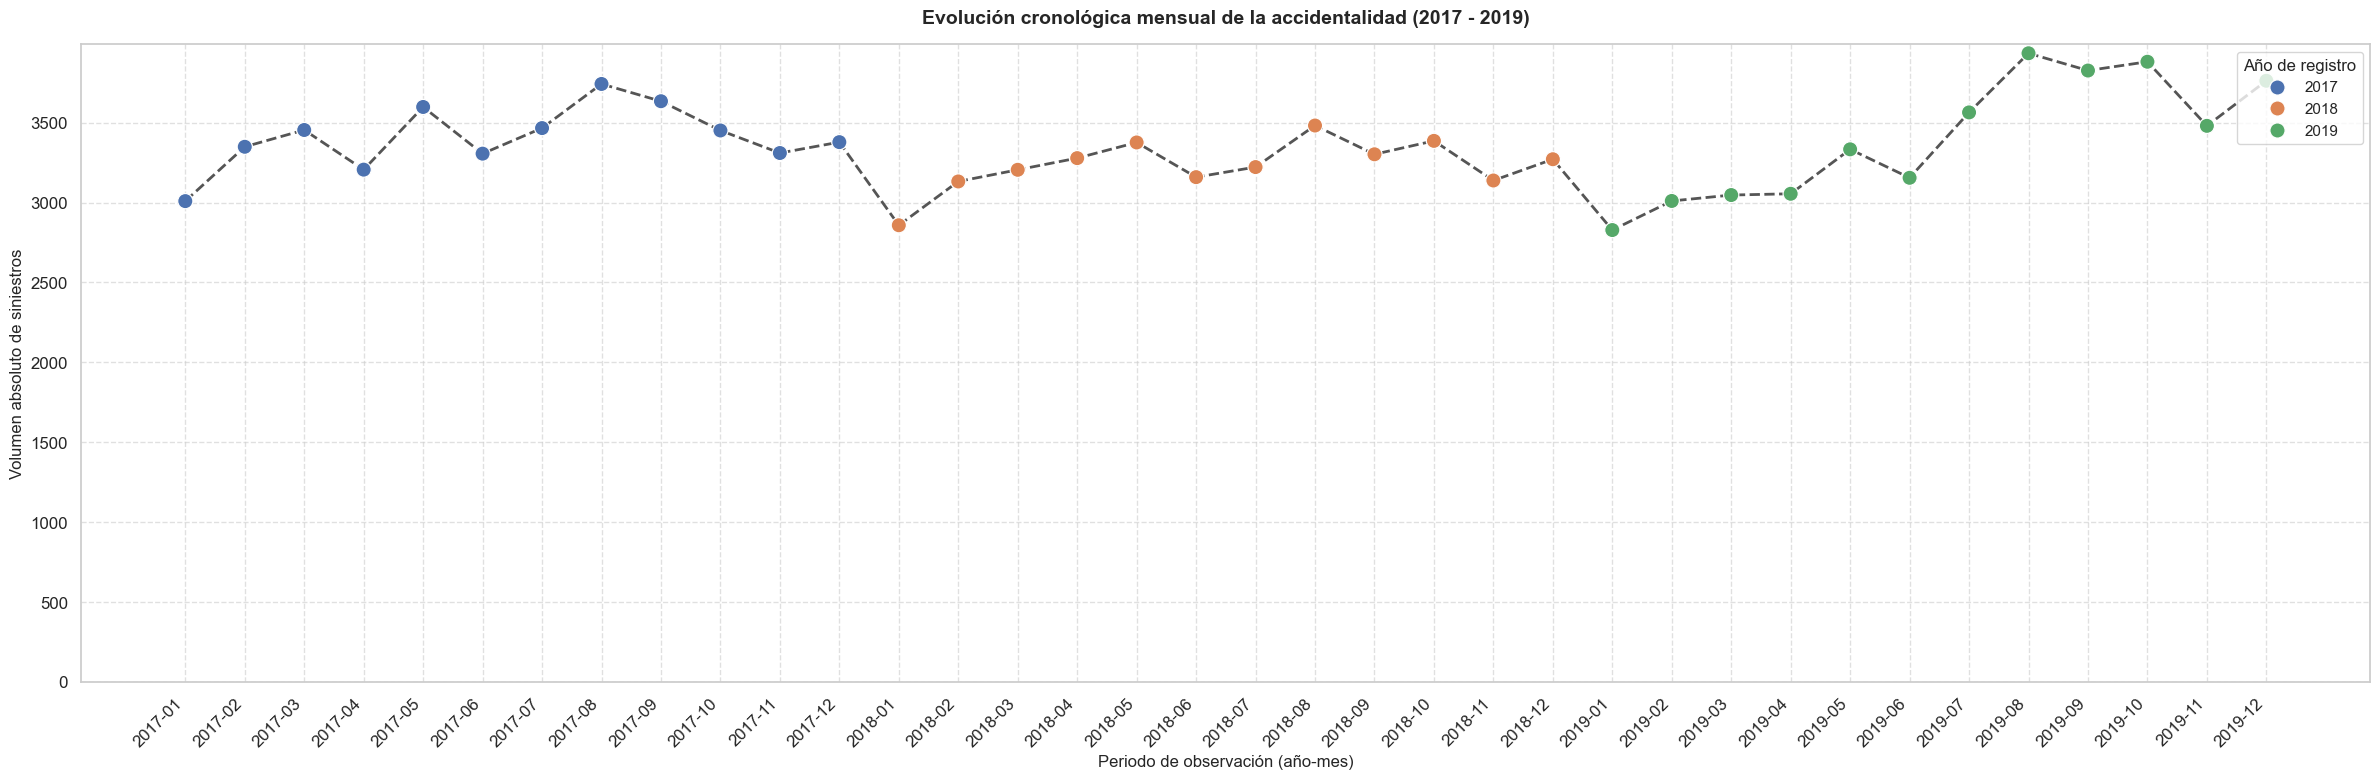

In [15]:
# =============================================================================
# Caracterización temporal: límites, macro-patrones y mapa de calor
# =============================================================================

# 1. Análisis de límites temporales inclusivos a nivel de fecha
fecha_inicial = df_accidentes['TW'].min()
fecha_final = df_accidentes['TW'].max()

# Conteo exacto de días transcurridos
cobertura_dias_calendario = (df_accidentes['TW'].dt.date.max() - df_accidentes['TW'].dt.date.min()).days + 1

print("="*70)
print("Auditoría temporal del dataset de accidentes")
print("="*70)
print(f"Fecha inicial:   {fecha_inicial.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Fecha final:     {fecha_final.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Cobertura total: {cobertura_dias_calendario} días calendario (inclusivo)\n")

# 2. Estadística descriptiva del volumen diario (total histórico vs anual)
# Agrupamiento por día completo para la serie de tiempo diaria
accidentes_diarios = df_accidentes.set_index('TW').resample('D').size()

# Resúmenes base
desc_global = accidentes_diarios.describe().to_frame(name='Total histórico')
desc_anual = accidentes_diarios.groupby(accidentes_diarios.index.year).describe().T

# Concatenación horizontal
tabla_descriptiva_completa = pd.concat([desc_global, desc_anual], axis=1)

# Inyección manual del volumen absoluto (suma)
suma_global = accidentes_diarios.sum()
suma_anual = accidentes_diarios.groupby(accidentes_diarios.index.year).sum()

fila_suma = pd.DataFrame(
    [[suma_global] + list(suma_anual.values)],
    columns=tabla_descriptiva_completa.columns,
    index=['sum']
)

# Reestructuración y reindexación formal de la tabla descriptiva
tabla_descriptiva_completa = pd.concat([tabla_descriptiva_completa, fila_suma])
orden_filas = ['count', 'sum', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
tabla_descriptiva_completa = tabla_descriptiva_completa.reindex(orden_filas)

print("Estadística descriptiva: volumen diario de accidentes")
display(tabla_descriptiva_completa.round(1))
print("-" * 70)

# 3. Extracción de componentes de fecha y tiempo para variables de análisis
df_accidentes['año'] = df_accidentes['TW'].dt.year
df_accidentes['mes'] = df_accidentes['TW'].dt.month
df_accidentes['hora'] = df_accidentes['TW'].dt.hour
df_accidentes['dia_semana'] = df_accidentes['TW'].dt.dayofweek



# 5. Gráfico B: Evolución mensual continua estructurada como gráfico de líneas (origen en 0)
evolucion_mensual = df_accidentes.groupby(['año', 'mes']).size().reset_index(name='total_accidentes')
evolucion_mensual['periodo'] = evolucion_mensual['año'].astype(str) + '-' + evolucion_mensual['mes'].astype(str).str.zfill(2)

fig_ev, ax_ev = plt.subplots(figsize=(24, 8))

sns.lineplot(
    data=evolucion_mensual,
    x='periodo',
    y='total_accidentes',
    color='#555555',
    linewidth=2,
    linestyle='--',
    ax=ax_ev,
    legend=False
)

sns.scatterplot(
    data=evolucion_mensual,
    x='periodo',
    y='total_accidentes',
    hue='año',
    palette='deep',
    s=120,
    zorder=5,
    ax=ax_ev
)

ax_ev.set_title('Evolución cronológica mensual de la accidentalidad (2017 - 2019)', fontweight='bold', fontsize=14, pad=15)
ax_ev.set_xlabel('Periodo de observación (año-mes)', fontsize=12)
ax_ev.set_ylabel('Volumen absoluto de siniestros', fontsize=12)
ax_ev.set_xticklabels(evolucion_mensual['periodo'], rotation=45, ha='right')
ax_ev.set_ylim(bottom=0)
ax_ev.grid(True, linestyle='--', alpha=0.6)
ax_ev.legend(title='Año de registro', loc='upper right', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.savefig('evolucion_mensual_lineas.png', bbox_inches='tight')

A lo largo de los 1,095 días analizados se registra un volumen acumulado de 120,587 accidentes, con una media histórica de 110.1 siniestros diarios.

La serie cronológica mensual evidencia una fluctuación estructural notable en 2018. Mientras que 2017 y 2019 muestran un comportamiento simétrico (~40,900 accidentes al año y medias de ~112 diarios), el año 2018 registra una contracción significativa cayendo a 38,809 siniestros y reduciendo la media diaria a 106.3. Al observar el gráfico de líneas, se descarta una tendencia lineal decreciente — el comportamiento califica como un ciclo macro-estacional o una variación exógena puntual en 2018.

> Este hallazgo justifica metodológicamente la necesidad de variables de memoria histórica (lags y rolling means) para que el modelo capture correctamente estos ciclos temporales.

#### 3.1.2 Ciclos estacionales — hora, día de la semana y mes

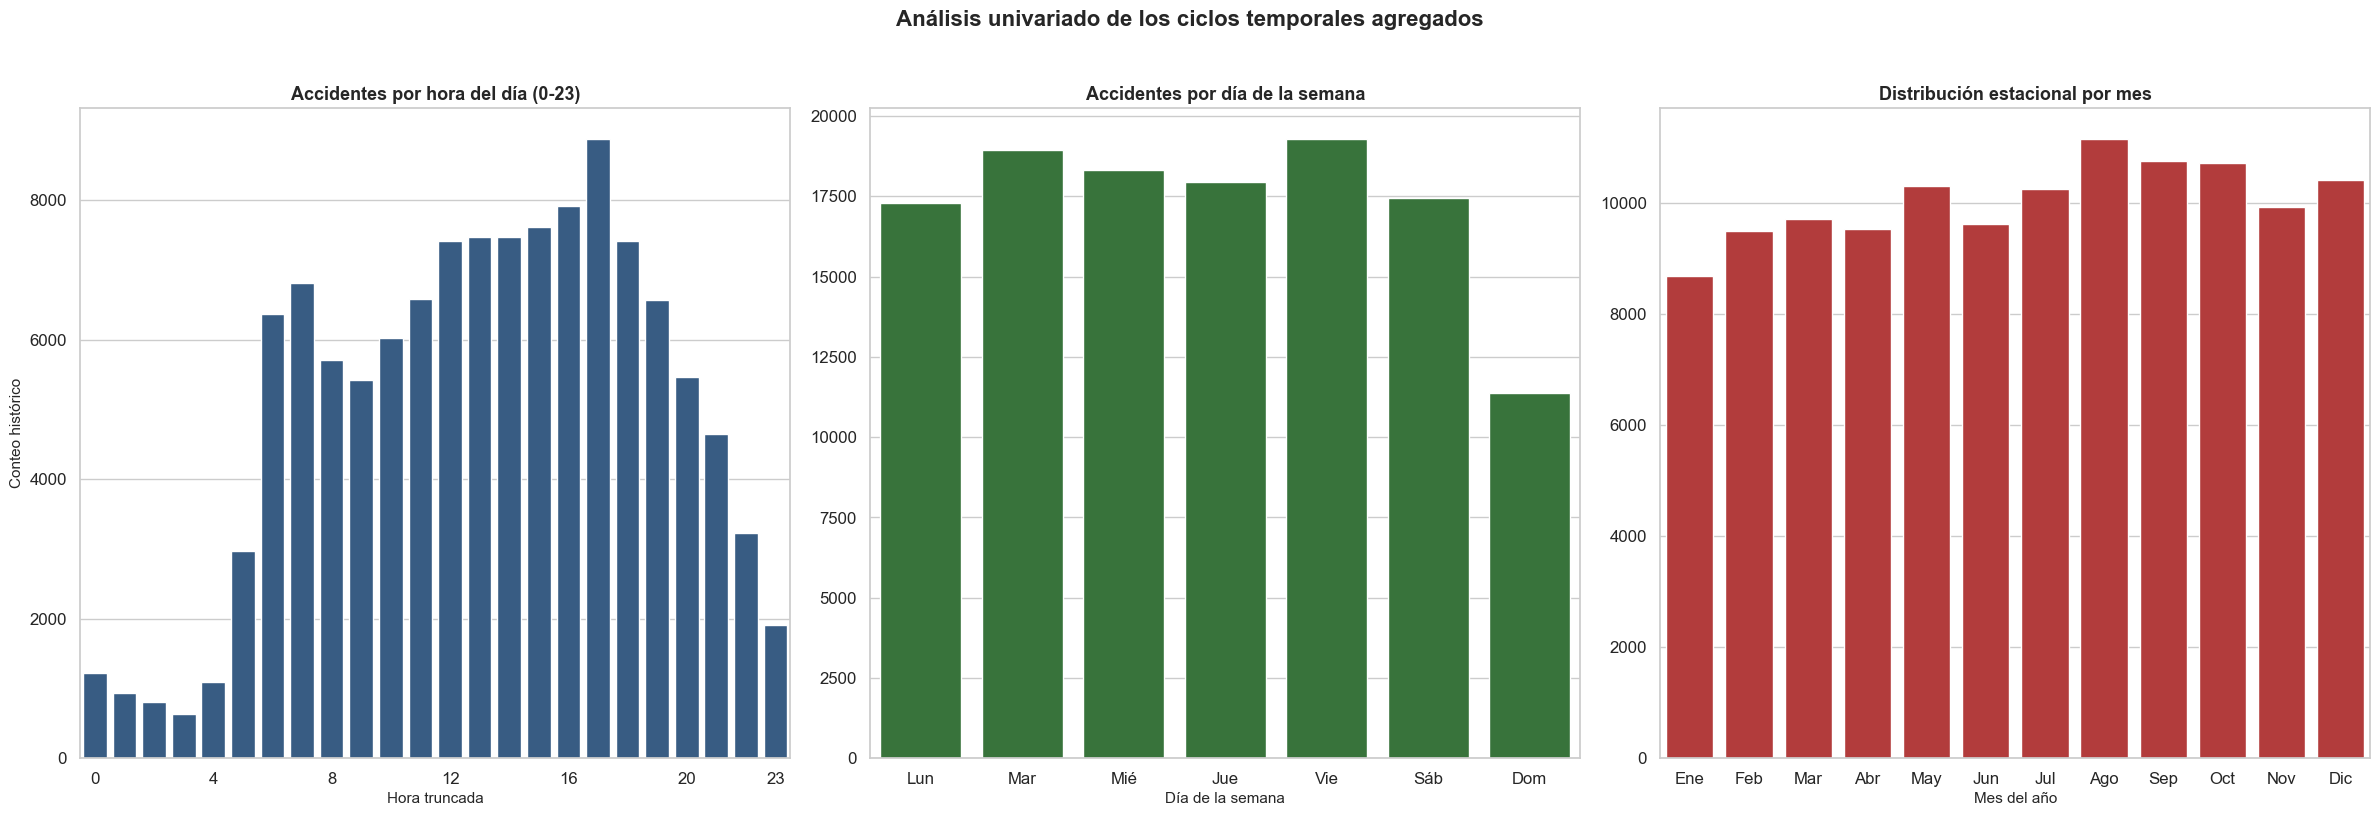

In [16]:
# 4. Gráfico A: Macro-patrones cíclicos univariados (origen en 0)
fig_ciclos, axes_ciclos = plt.subplots(1, 3, figsize=(24, 8))

# Subplot de horas
sns.countplot(data=df_accidentes, x='hora', color='#2b5c8f', ax=axes_ciclos[0])
axes_ciclos[0].set_title('Accidentes por hora del día (0-23)', fontweight='bold', fontsize=13)
axes_ciclos[0].set_xlabel('Hora truncada', fontsize=11)
axes_ciclos[0].set_ylabel('Conteo histórico', fontsize=11)
axes_ciclos[0].set_xticks([0, 4, 8, 12, 16, 20, 23])
axes_ciclos[0].set_ylim(bottom=0)

# Subplot de días de la semana
sns.countplot(data=df_accidentes, x='dia_semana', color='#2e7d32', ax=axes_ciclos[1])
axes_ciclos[1].set_title('Accidentes por día de la semana', fontweight='bold', fontsize=13)
axes_ciclos[1].set_xlabel('Día de la semana', fontsize=11)
axes_ciclos[1].set_ylabel('')
axes_ciclos[1].set_xticklabels(['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'])
axes_ciclos[1].set_ylim(bottom=0)

# Subplot de meses (ciclo anual regular)
sns.countplot(data=df_accidentes, x='mes', color='#c62828', ax=axes_ciclos[2])
axes_ciclos[2].set_title('Distribución estacional por mes', fontweight='bold', fontsize=13)
axes_ciclos[2].set_xlabel('Mes del año', fontsize=11)
axes_ciclos[2].set_ylabel('')
axes_ciclos[2].set_xticks(range(12))
axes_ciclos[2].set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
axes_ciclos[2].set_ylim(bottom=0)

fig_ciclos.suptitle('Análisis univariado de los ciclos temporales agregados', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ciclos_temporales_expandidos.png', bbox_inches='tight')

**Estacionalidad mensual:** La distribución por meses muestra valles pronunciados en enero y Semana Santa (marzo/abril), consistentes con las épocas de vacaciones colectivas y menor movilidad vehicular. Los picos se concentran en agosto y los meses de cierre de año.

**Estacionalidad semanal:** El volumen de accidentes se mantiene estable durante la semana laboral, consolidándose el viernes como el día más crítico. El domingo opera como el valle de la serie, asociado a la reducción natural de movilidad laboral.

**Estacionalidad por hora:** Se observan concentraciones críticas en las franjas de 7:00-9:00 y 17:00-19:00, correspondientes a las horas pico de conmutación. El viernes expande su ventana de riesgo desde las 14:00 hasta las 19:00, reflejando la salida anticipada combinada con el inicio de actividades de ocio. Durante el fin de semana el riesgo migra hacia las madrugadas (1:00-5:00), asociado a conducción bajo fatiga o estado de embriaguez.

> Los tres patrones estacionales — mensual, semanal y horario — confirman que el tiempo no es una variable lineal en este problema. Su comportamiento es cíclico y requiere codificación especial.

#### 3.1.3 Interacción día × hora

El análisis univariado de hora y día por separado no captura toda la información. El mapa de calor siguiente muestra la interacción entre ambas variables — permite identificar combinaciones específicas de día y hora con mayor concentración de accidentes.

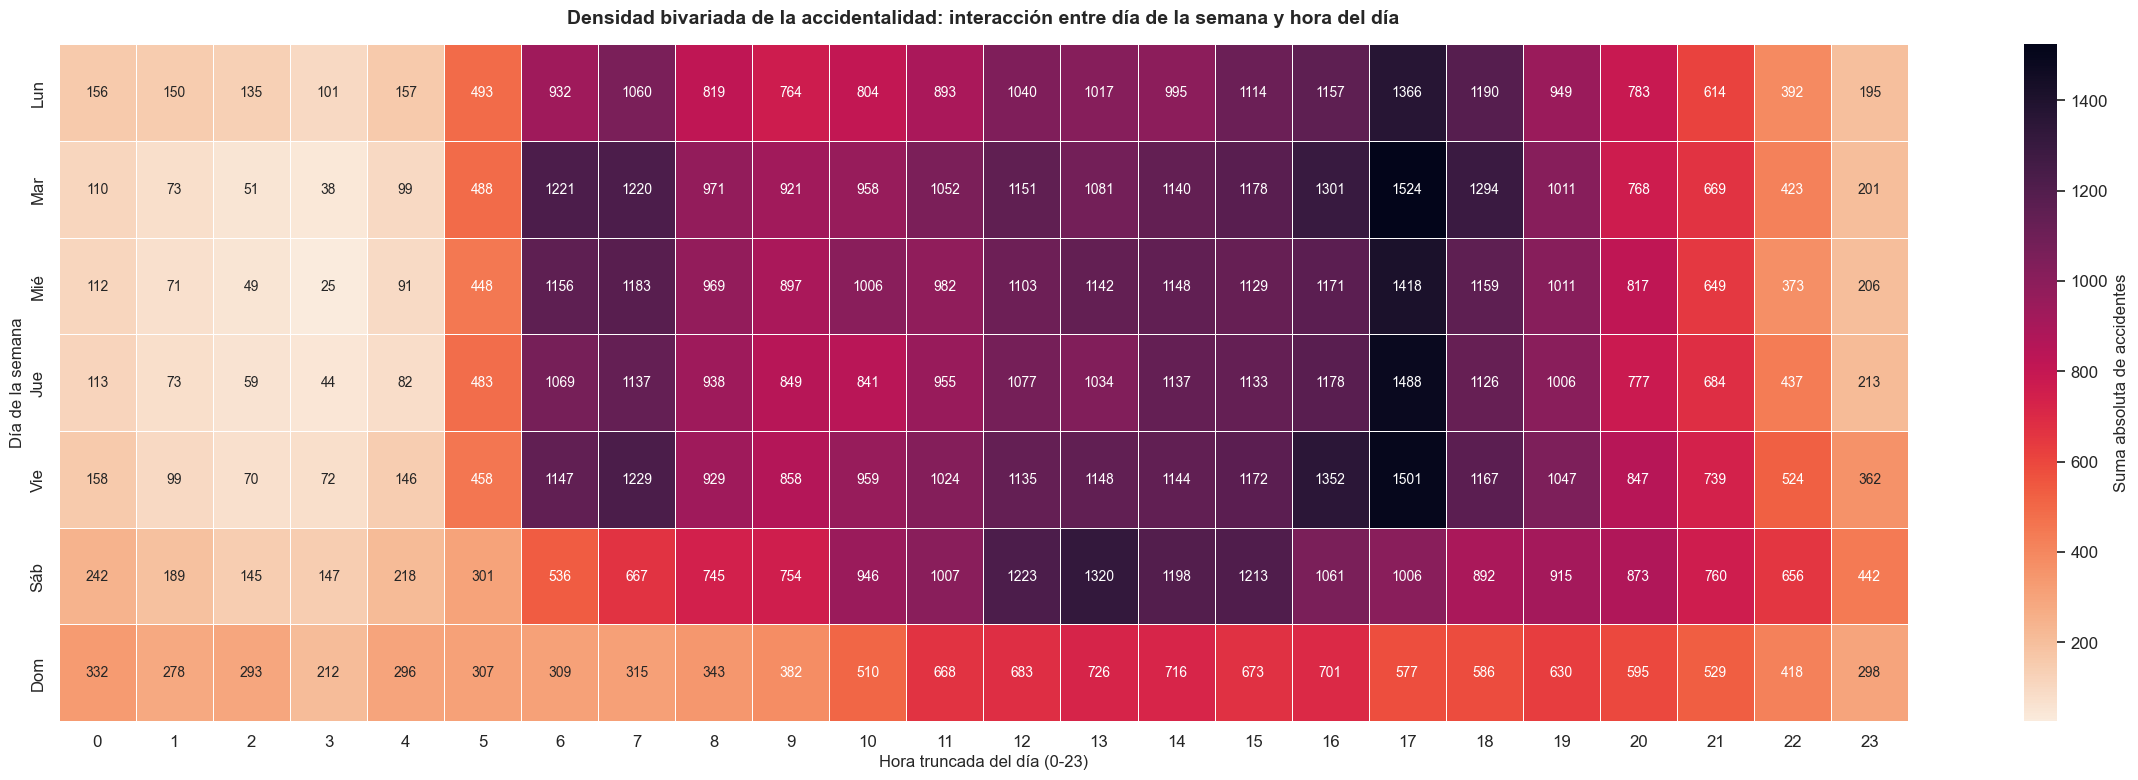

In [17]:
# 6. Gráfico C: Mapa de calor de interacciones bivariadas (día de la semana vs hora)
# Se construye la matriz de contingencia calculando la sumatoria de eventos por celda
matriz_tiempo = df_accidentes.groupby(['dia_semana', 'hora']).size().unstack(fill_value=0)
matriz_tiempo.index = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig_heat, ax_heat = plt.subplots(figsize=(24, 8))

# Se utiliza una paleta secuencial perceptualmente uniforme (rocket_r) para resaltar los picos
sns.heatmap(
    matriz_tiempo,
    cmap='rocket_r',
    annot=True,
    fmt='d',
    linewidths=0.5,
    annot_kws={"size": 10},
    cbar_kws={'label': 'Suma absoluta de accidentes'},
    ax=ax_heat
)

ax_heat.set_title('Densidad bivariada de la accidentalidad: interacción entre día de la semana y hora del día', fontweight='bold', fontsize=14, pad=15)
ax_heat.set_xlabel('Hora truncada del día (0-23)', fontsize=12)
ax_heat.set_ylabel('Día de la semana', fontsize=12)

plt.tight_layout()
plt.savefig('heatmap_interaccion_temporal.png', bbox_inches='tight')

#### 3.1.4 Implicaciones para el modelado

Los hallazgos de la distribución temporal demuestran que tratar la hora como un entero del 0 al 23 destruiría el desempeño predictivo — el modelo vería las 23:00 y las 00:00 como extremos opuestos cuando son horas adyacentes. Lo mismo aplica para el día de la semana y el mes.

Esto obliga a:

- **Codificación cíclica** con seno y coseno para hora, día de la semana y mes — preserva la continuidad circular de cada variable.
- **Variables de interacción** como `dia_laboral × hora_pico` — captura los picos de conmutación diaria frente al riesgo de madrugada en fin de semana.
- **Indicador de festivos** — los días festivos en Colombia mimetizan el comportamiento del fin de semana y alteran los patrones típicos de conmutación.

> Estas tres decisiones de feature engineering están directamente motivadas por los patrones encontrados en el EDA temporal.

### **3.2. Distribución espacial de la accidentalidad**

La distribución espacial analiza dónde ocurren los accidentes — por barrio y por comuna. Entender qué zonas concentran más accidentes es fundamental para el modelo porque el barrio no es una variable cualquiera: hay zonas que por su diseño vial, nivel de tráfico y uso del suelo tienen históricamente más accidentes que otras.

Se realizan dos análisis: una auditoría de reconciliación entre `df_raw` y `df_accidentes`, y una caracterización visual de la concentración espacial por barrio y comuna.

#### 3.2.1 Auditoría de reconciliación espacial

In [18]:
display(df_accidentes)
display(df_raw)

,TW,BARRIO,Lat,Lon,Dia_sem,Mes,Dia,Hora,año,mes,hora,dia_semana
0,2017-07-20 08:00:00,sandiego,6.233985,-75.570145,JUEVES,7,20,8,2017,7,8,3
1,2017-06-15 16:00:00,lasacacias,6.238844,-75.600281,JUEVES,6,15,16,2017,6,16,3
2,2017-07-02 16:00:00,lopezdemesa,6.285074,-75.584305,DOMINGO,7,2,16,2017,7,16,6
3,2017-03-29 18:00:00,losconquistadores,6.239497,-75.583061,MIERCOLES,3,29,18,2017,3,18,2
4,2017-07-26 20:00:00,cuartabrigada,6.260463,-75.590195,MIERCOLES,7,26,20,2017,7,20,2
...,...,...,...,...,...,...,...,...,...,...,...,...
120582,2019-03-19 07:00:00,lafloresta,6.257358,-75.603531,MARTES,3,19,7,2019,3,7,1
120583,2019-02-04 07:00:00,alejandroechavarria,6.239886,-75.550865,LUNES,2,4,7,2019,2,7,0
120584,2019-06-18 14:00:00,moscuno1,6.293053,-75.554840,MARTES,6,18,14,2019,6,14,1
120585,2019-05-08 18:00:00,boyaca,6.301662,-75.567131,MIERCOLES,5,8,18,2019,5,18,2


,Lon,Lat,OBJECTID,RADICADO,HORA,Dia_sem,PERIODO,CLASE,DIRECCION,DIRECCION_ENC,CBML,TIPO_GEOCOD,GRAVEDAD,BARRIO,COMUNA,DISENO,Mes,Dia,FECHA,MES_NOMBRE,Hora_num,TW
0,-75.570145,6.233985,504352,1590356,08:00 AM,JUEVES,2017,Caida Ocupante,CR 43 A CL 33,CR 043 A 033 000 00000,1020,Malla vial,HERIDO,sandiego,La Candelaria,Interseccion,7,20,2017-07-20,NaN,8,2017-07-20 08:00:00
1,-75.600281,6.238844,504353,1586285,04:50 PM,JUEVES,2017,Choque,CR 80 CL 33,CR 080 033 000 00000,1109,Malla vial,SOLO DAÑOS,lasacacias,Laureles Estadio,Glorieta,6,15,2017-06-15,NaN,16,2017-06-15 16:00:00
2,-75.584305,6.285074,504354,1588185,04:20 PM,DOMINGO,2017,Choque,CR 80 CL 80 A,CR 080 080 A 000 00000,0710,Malla vial,HERIDO,lopezdemesa,Robledo,Tramo de via,7,2,2017-07-02,NaN,16,2017-07-02 16:00:00
3,-75.583061,6.239497,504355,1576853,06:29 PM,MIERCOLES,2017,Choque,CL 33 Norte CR 65,CL 033 065 000 00000,1105,Malla vial,SOLO DAÑOS,losconquistadores,Laureles Estadio,Tramo de via,3,29,2017-03-29,NaN,18,2017-03-29 18:00:00
4,-75.590195,6.260463,504356,1591283,08:10 PM,MIERCOLES,2017,Atropello,CL 50 CR 74,CL 050 074 000 00000,1115,Malla vial,HERIDO,cuartabrigada,Laureles Estadio,Tramo de via,7,26,2017-07-26,NaN,20,2017-07-26 20:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125117,-75.574532,6.246080,726806,1673279,2:20:00 p. m.,MARTES,2019,Caida Ocupante,CR 55 CL 44,CR 055 044 000 00000,1007,Malla vial,HERIDO,guayaquil,La Candelaria,Tramo de via,6,4,2019-06-04,JUNIO,14,2019-06-04 14:00:00
125118,-75.550865,6.239886,726807,1659105,7:05:00 a. m.,LUNES,2019,Choque,CL 49 CR 27 A,CL 049 027 A 000 00000,0905,Malla vial,HERIDO,alejandroechavarria,Buenos Aires,Interseccion,2,4,2019-02-04,FEBRERO,7,2019-02-04 07:00:00
125119,-75.554840,6.293053,726809,1675103,2:00:00 p. m.,MARTES,2019,Choque,CR 48 A CL 102,CR 048 A 102 000 00000,0209,Malla vial cruce invertido,SOLO DAÑOS,moscuno1,Santa Cruz,Tramo de via,6,18,2019-06-18,JUNIO,14,2019-06-18 14:00:00
125120,-75.567131,6.301662,726810,1669874,6:35:00 p. m.,MIERCOLES,2019,Choque,CR 67 CL 104 A,CR 067 104 A 000 00000,0505,Malla vial,SOLO DAÑOS,boyaca,Castilla,Tramo de via,5,8,2019-05-08,MAYO,18,2019-05-08 18:00:00


In [19]:
# =============================================================================
# Auditoría de Reconciliación Espacial: df_raw vs df_accidentes
# =============================================================================
import pandas as pd

print("="*70)
print("AUDITORÍA DE RECONCILIACIÓN ESPACIAL (RAW vs ACCIDENTES)")
print("="*70)

# 1. Calcular el volumen absoluto de accidentes por barrio en ambas tablas
# Asumimos que en ambas tablas cada fila es un accidente (log de eventos)
conteo_raw = df_raw['BARRIO'].value_counts().rename('accidentes_raw')
conteo_acc = df_accidentes['BARRIO'].value_counts().rename('accidentes_limpios')

# 2. Unir ambos conteos para compararlos barrio a barrio
df_reconciliacion = pd.concat([conteo_raw, conteo_acc], axis=1).fillna(0)

# 3. Calcular la diferencia matemática
df_reconciliacion['diferencia'] = df_reconciliacion['accidentes_raw'] - df_reconciliacion['accidentes_limpios']

# 4. Diagnóstico de pérdida de datos
barrios_con_perdida = df_reconciliacion[df_reconciliacion['diferencia'] != 0]

if barrios_con_perdida.empty:
    print("✅ RECONCILIACIÓN EXITOSA: La volumetría por barrio coincide perfectamente.")
else:
    print(f"⚠️ ALERTA: Se detectaron {len(barrios_con_perdida)} barrios con diferencias volumétricas.")
    print("Top 5 barrios con mayor diferencia (Raw - Limpio):")
    display(barrios_con_perdida.sort_values('diferencia', ascending=False).head())
print("-" * 70)

# =============================================================================
# EXTRACCIÓN E INYECCIÓN DEL MAPEO COMUNA -> BARRIO
# =============================================================================
print("Inyectando jerarquía espacial (Comuna) desde df_raw hacia df_accidentes...")

# 1. Extraer el diccionario único de relaciones Barrio -> Comuna desde df_raw
# Eliminamos duplicados para tener la tabla de verdad geográfica
mapeo_geografico = df_raw[['BARRIO', 'COMUNA']].dropna().drop_duplicates(subset=['BARRIO'])

# Convertimos a diccionario para un mapeo hiper-rápido en RAM (O(1))
dict_barrio_comuna = dict(zip(mapeo_geografico['BARRIO'], mapeo_geografico['COMUNA']))

# 2. Inyectar la Comuna en df_accidentes respetando la categorización
df_accidentes['COMUNA'] = df_accidentes['BARRIO'].map(dict_barrio_comuna)

# 3. Validar si quedaron barrios huérfanos de Comuna
barrios_sin_comuna = df_accidentes[df_accidentes['COMUNA'].isna()]['BARRIO'].unique()

if len(barrios_sin_comuna) > 0:
    print(f"⚠️ ADVERTENCIA: Hay {len(barrios_sin_comuna)} barrios en df_accidentes que no tienen Comuna en df_raw.")
    print(f"Ejemplos: {barrios_sin_comuna[:3]}")
    # Rellenar con 'SIN INFO' para que no rompa las gráficas
    df_accidentes['COMUNA'] = df_accidentes['COMUNA'].fillna('SIN_INFO_COMUNA')
else:
    print("✅ Mapeo completado. Todos los barrios tienen su comuna asignada.")

# 4. Crear la variable combinada solicitada para los gráficos posteriores
df_accidentes['Comuna-Barrio'] = df_accidentes['COMUNA'].astype(str) + ' - ' + df_accidentes['BARRIO'].astype(str)

print("Variable 'Comuna-Barrio' creada exitosamente y lista para visualización.")
print("="*70)

AUDITORÍA DE RECONCILIACIÓN ESPACIAL (RAW vs ACCIDENTES)
⚠️ ALERTA: Se detectaron 223 barrios con diferencias volumétricas.
Top 5 barrios con mayor diferencia (Raw - Limpio):


,accidentes_raw,accidentes_limpios,diferencia
BARRIO,,,
lacandelaria,3037,2734,303
campoamor,2785,2533,252
perpetuosocorro,2534,2320,214
caribe,2506,2297,209
santafe,2169,1994,175


----------------------------------------------------------------------
Inyectando jerarquía espacial (Comuna) desde df_raw hacia df_accidentes...
✅ Mapeo completado. Todos los barrios tienen su comuna asignada.
Variable 'Comuna-Barrio' creada exitosamente y lista para visualización.


Al contrastar `df_raw` contra `df_accidentes` se identificó una diferencia de ~4,500 registros distribuida en 223 barrios. El top 5 de zonas críticas muestra una contracción entre el 8% y el 10% de sus registros históricos — por ejemplo, `lacandelaria` pasa de 3,037 a 2,734 registros.

Esta discrepancia es esperada y está fuera del control del pipeline: obedece a un preprocesamiento previo que pudo responder a depuración por criterios de calidad o al colapso por co-ocurrencia espacio-temporal (múltiples accidentes en la misma combinación barrio-hora colapsados en un solo registro).

> Se asume que no hay errores en los datos dado que el enunciado describe `df_accidentes` como *"la fuente natural para construir la variable objetivo"*.

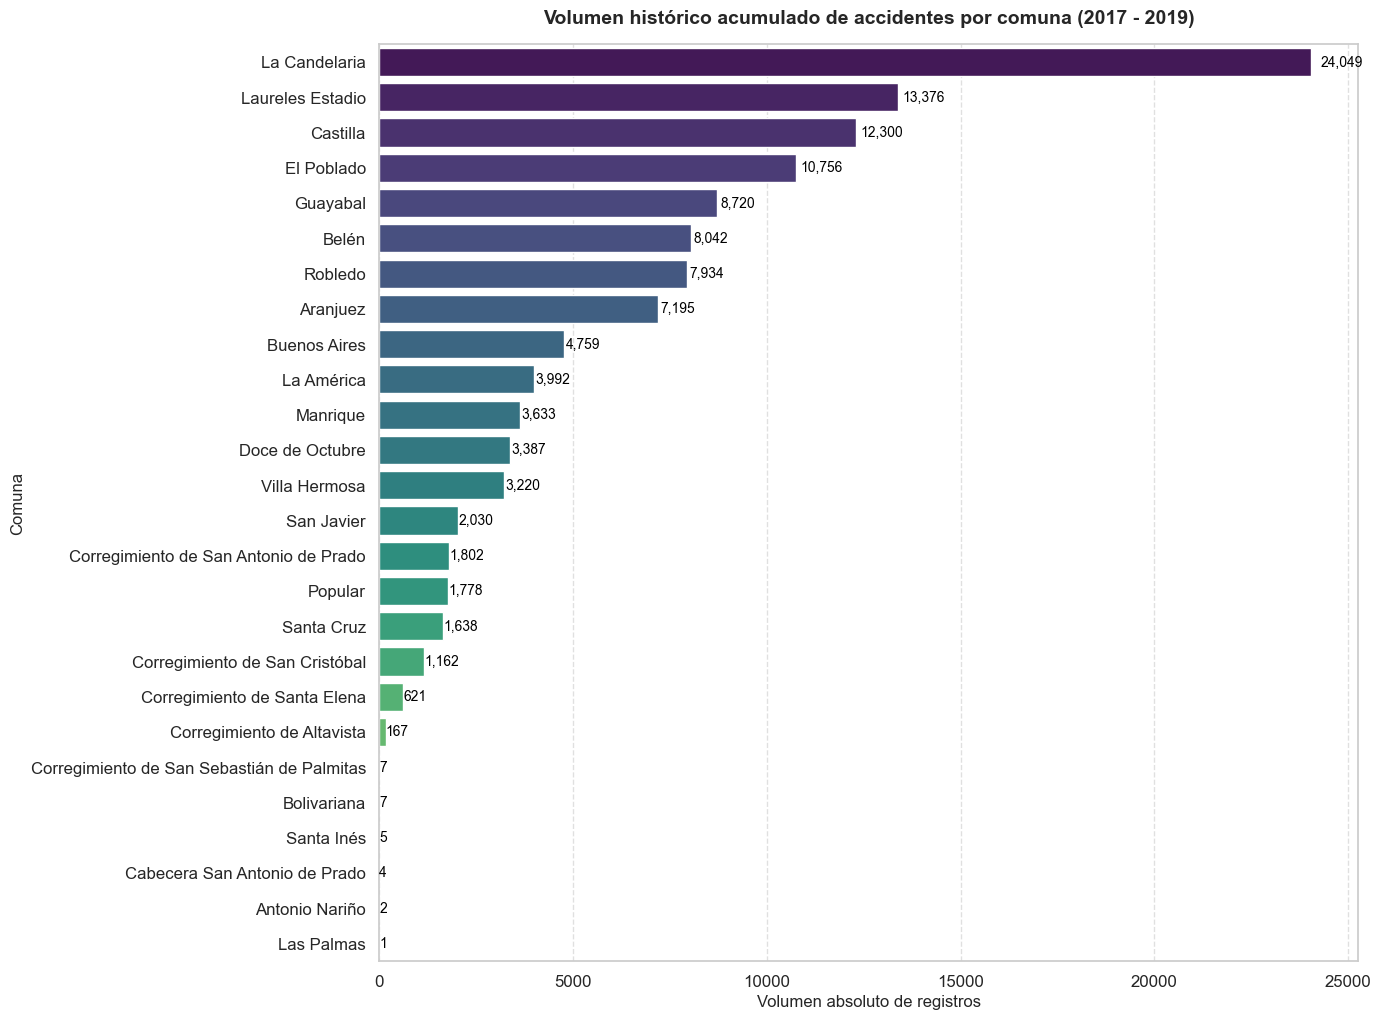

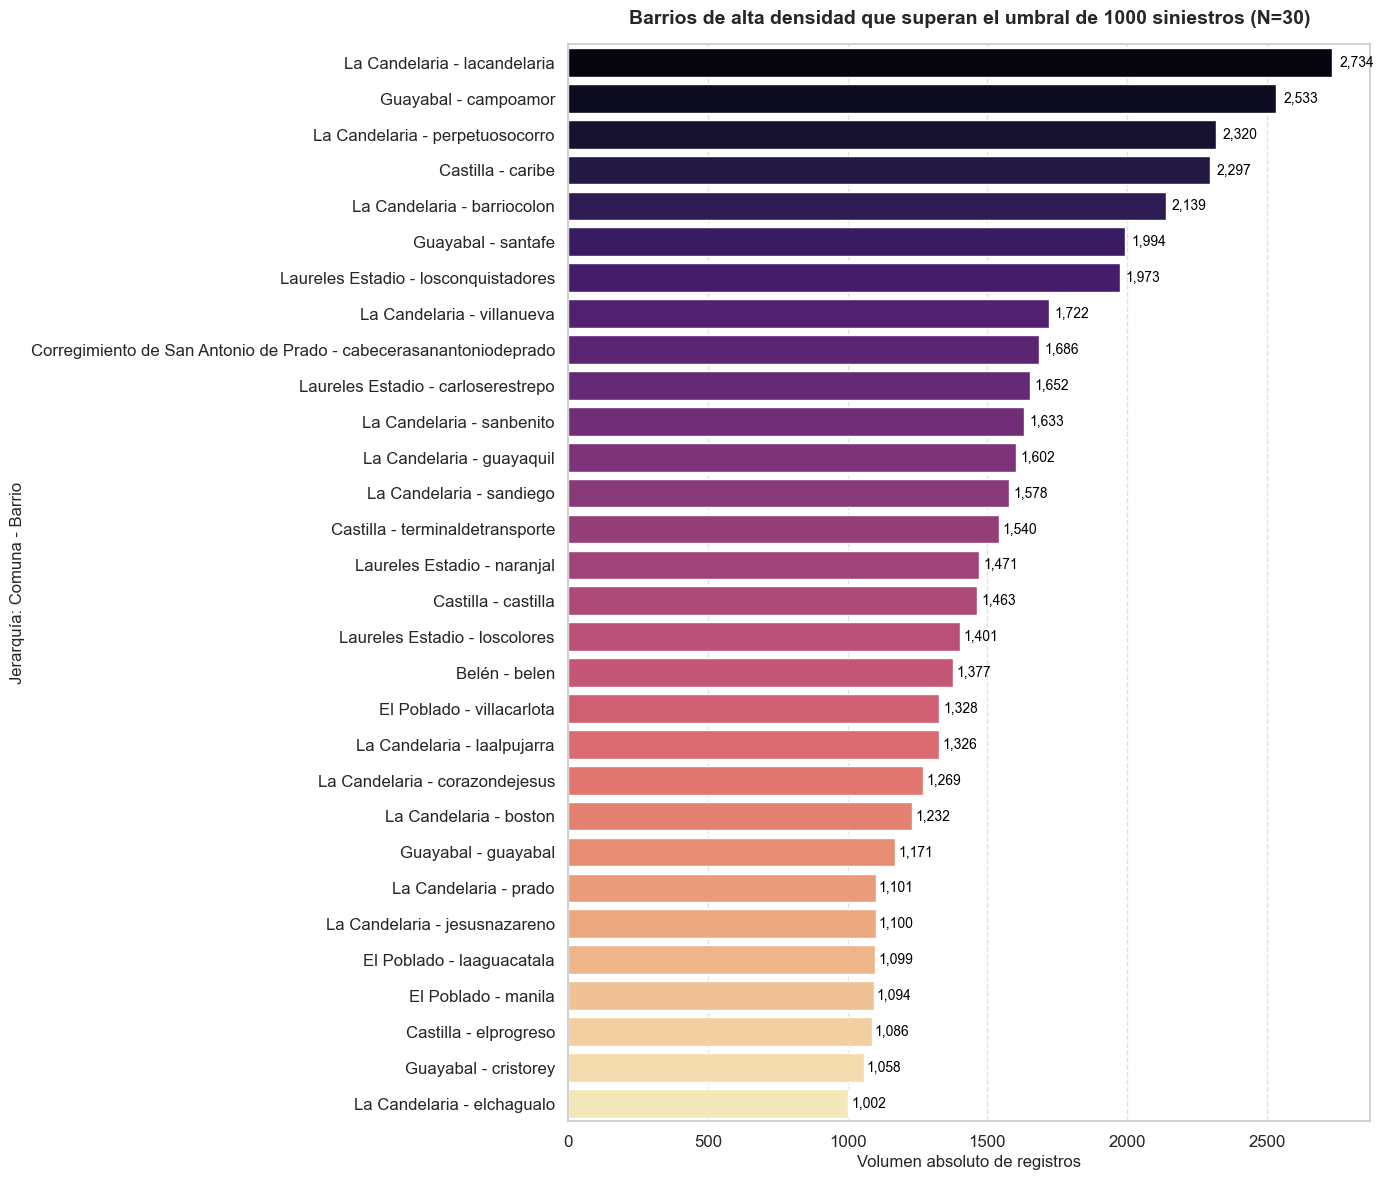

In [20]:
# =============================================================================
# 4.1.2 Caracterización espacial: visualización de jerarquías y top de riesgo
# =============================================================================

# -----------------------------------------------------------------------------
# Gráfico 1: Distribución completa por comunas (macro-entorno)
# -----------------------------------------------------------------------------
# Agregación y ordenamiento descendente estricto
frecuencia_comunas = df_accidentes['COMUNA'].value_counts().sort_values(ascending=False)

# Definición del lienzo mediante subplots (altura dinámica basada en categorías)
altura_comunas = max(8.0, len(frecuencia_comunas) * 0.4)
fig_comuna, ax_comuna = plt.subplots(figsize=(14, altura_comunas))

# Renderizado utilizando una paleta secuencial de alta legibilidad
sns.barplot(
    x=frecuencia_comunas.values, 
    y=frecuencia_comunas.index.astype(str), 
    palette='viridis', 
    ax=ax_comuna
)

# Configuración estética y blindaje de la línea base en 0
ax_comuna.set_title('Volumen histórico acumulado de accidentes por comuna (2017 - 2019)', fontweight='bold', fontsize=14, pad=15)
ax_comuna.set_xlabel('Volumen absoluto de registros', fontsize=12)
ax_comuna.set_ylabel('Comuna', fontsize=12)
ax_comuna.set_xlim(left=0)  # Forzar inicio del eje en cero absoluto

# Inyección de etiquetas numéricas con formato de millares
for i, v in enumerate(frecuencia_comunas.values):
    ax_comuna.text(v + (v * 0.01), i, f"{v:,}", color='black', va='center', fontsize=10)

ax_comuna.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('distribucion_espacial_comunas_total.png', bbox_inches='tight')

# -----------------------------------------------------------------------------
# Gráfico 2: Top barrios con más de 1.000 accidentes (contexto comuna-barrio)
# -----------------------------------------------------------------------------
# Definición del umbral operativo de alta densidad
UMBRAL_ACCIDENTES = 1000

# Agregación y filtrado por la variable combinada jerárquica
frecuencia_cb = df_accidentes['Comuna-Barrio'].value_counts()
barrios_significativos = frecuencia_cb[frecuencia_cb >= UMBRAL_ACCIDENTES].sort_values(ascending=False)

cantidad_barrios_significativos = len(barrios_significativos)

# Definición del lienzo específico para el desglose de barrios
altura_barrios = max(8.0, cantidad_barrios_significativos * 0.4)
fig_cb, ax_cb = plt.subplots(figsize=(14, altura_barrios))

# Renderizado con paleta de alto contraste para puntos calientes (hotspots)
sns.barplot(
    x=barrios_significativos.values, 
    y=barrios_significativos.index.astype(str), 
    palette='magma', 
    ax=ax_cb
)

# Ajustes de títulos y control del origen geométrico
ax_cb.set_title(f'Barrios de alta densidad que superan el umbral de {UMBRAL_ACCIDENTES} siniestros (N={cantidad_barrios_significativos})', fontweight='bold', fontsize=14, pad=15)
ax_cb.set_xlabel('Volumen absoluto de registros', fontsize=12)
ax_cb.set_ylabel('Jerarquía: Comuna - Barrio', fontsize=12)
ax_cb.set_xlim(left=0)  # Forzar inicio del eje en cero absoluto

# Inyección de etiquetas de datos al final de cada barra
for i, v in enumerate(barrios_significativos.values):
    ax_cb.text(v + (v * 0.01), i, f"{v:,}", color='black', va='center', fontsize=10)

ax_cb.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('distribucion_espacial_comuna_barrio_1000.png', bbox_inches='tight')

Descargando archivo desde Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1bxxsP-_a9x8jNMvYIGHNYL5viSbqJBoL
To: c:\Users\Usuario\Repositorios git\AprendizajeAutomatico\comunas_temp.zip
100%|██████████| 3.49M/3.49M [00:00<00:00, 5.15MB/s]


Descomprimiendo el archivo...
¡Mapa exportado con éxito!


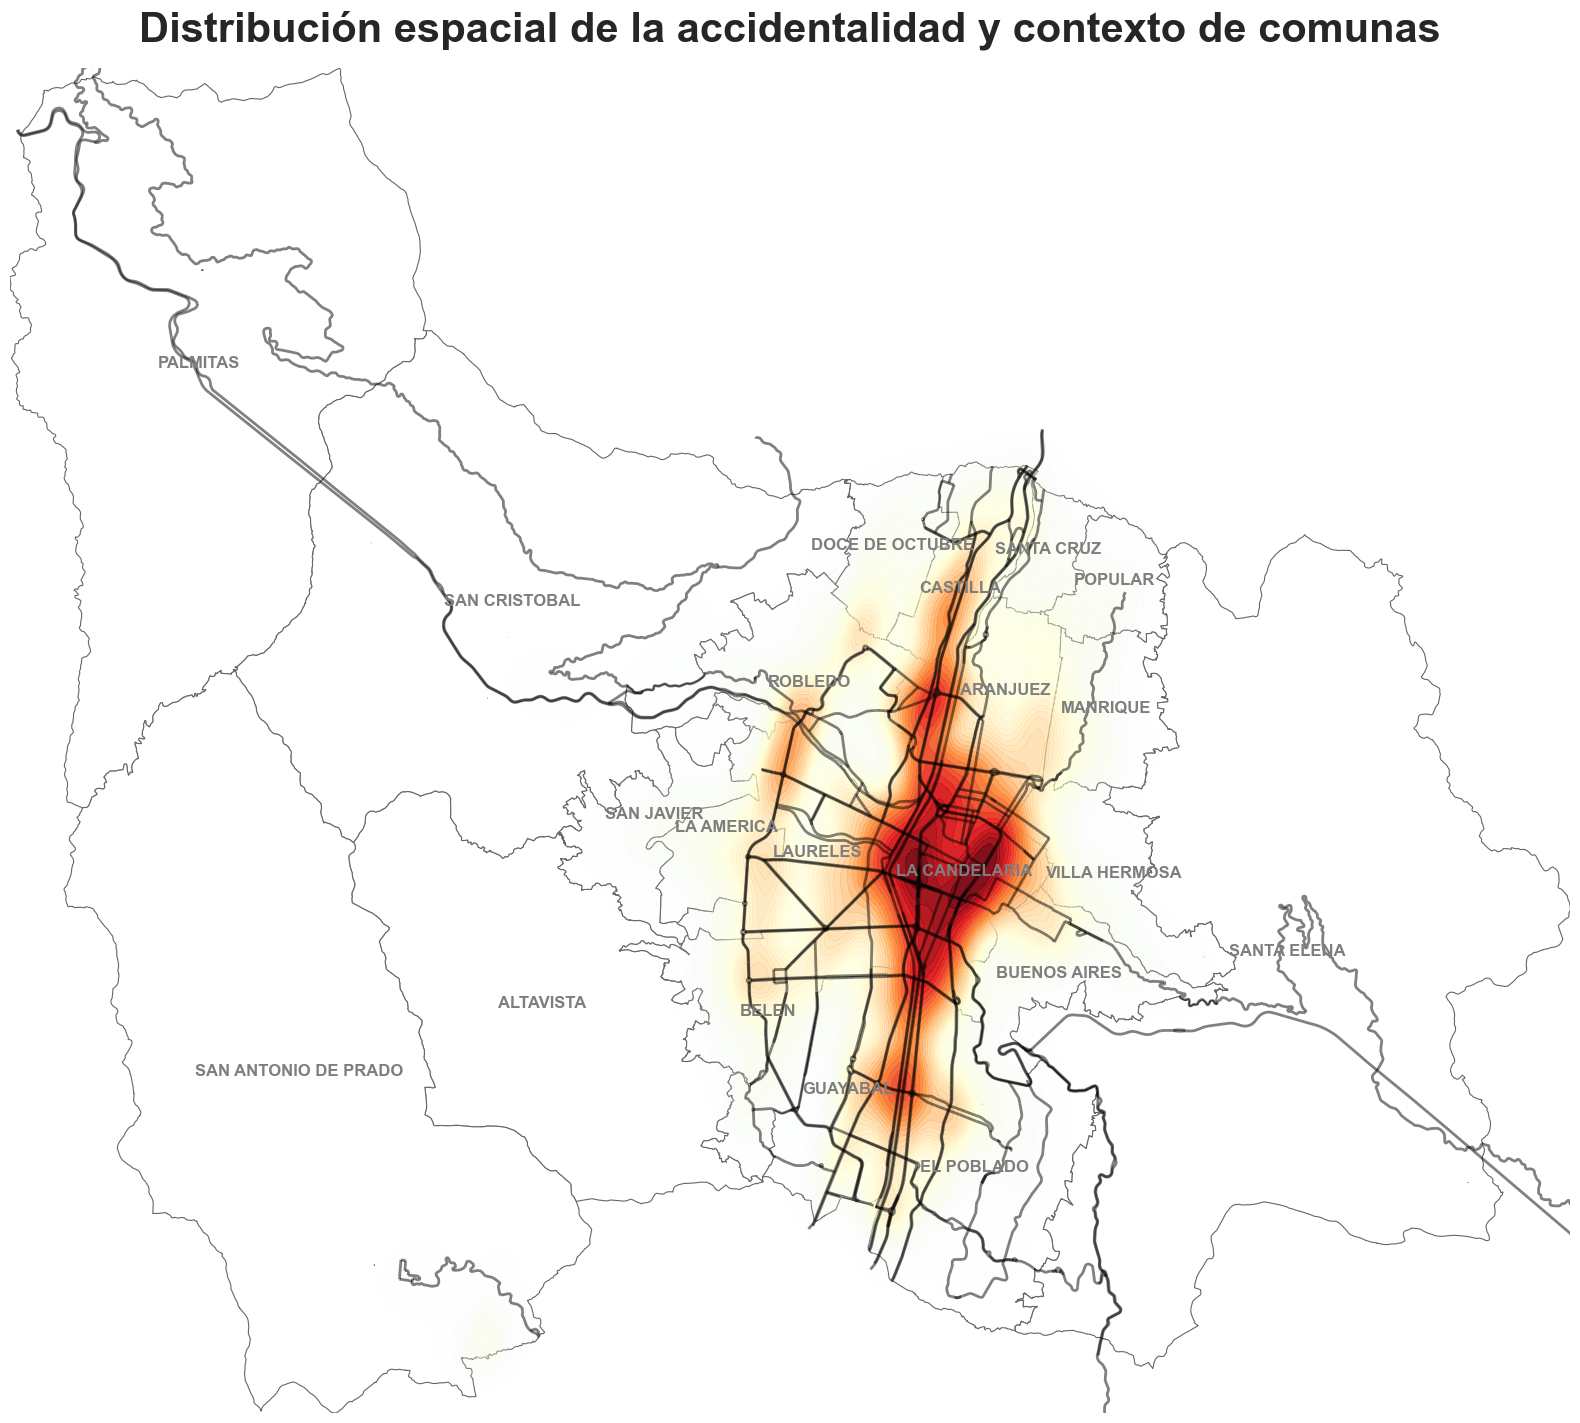

In [21]:
# =============================================================================
# Mapa de densidad espacial
# =============================================================================
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown  
import os
import zipfile
import glob
import osmnx as ox
import numpy as np
import matplotlib.colors as mcolors

# 1. Configuración del área de interés (Medellín, Colombia)
place_name = "Medellín, Colombia"

# 2. Descarga de vías principales usando osmnx
tags = {'highway': ['motorway', 'trunk', 'primary', 'secondary']}
vias_principales = ox.features_from_place(place_name, tags=tags)
vias_principales = vias_principales.to_crs("EPSG:4326")

# 3. Importación desde Google Drive y extracción segura
file_id = "1bxxsP-_a9x8jNMvYIGHNYL5viSbqJBoL"
ruta_zip_temporal = "comunas_temp.zip"
carpeta_extraccion = "comunas_extraidas"

print("Descargando archivo desde Google Drive...")
gdown.download(id=file_id, output=ruta_zip_temporal, quiet=False)

print("Descomprimiendo el archivo...")
with zipfile.ZipFile(ruta_zip_temporal, 'r') as zip_ref:
    zip_ref.extractall(carpeta_extraccion)

archivos_shp = glob.glob(f"{carpeta_extraccion}/**/*.shp", recursive=True)
if not archivos_shp:
    raise ValueError("Error: No se encontró ningún archivo .shp dentro del ZIP.")

ruta_shp = archivos_shp[0]
gdf_comunas = gpd.read_file(ruta_shp)

# 4. Asegurar alineación de sistemas de referencia (CRS)
gdf_accidentes = gpd.GeoDataFrame(
    df_accidentes, 
    geometry=gpd.points_from_xy(df_accidentes['Lon'], df_accidentes['Lat']),
    crs="EPSG:4326"
)

gdf_comunas = gdf_comunas.to_crs("EPSG:4326")
vias_principales = vias_principales.to_crs("EPSG:4326")

# 5. Definir límites del área de estudio
minx, miny, maxx, maxy = gdf_comunas.total_bounds

# 6. Definición del lienzo
fig_mapa, ax_mapa = plt.subplots(figsize=(16, 16))

# Capa 1: Comunas (Fondo) - ZORDER 1
gdf_comunas.plot(ax=ax_mapa, color='#ffffff', edgecolor='#666666', linewidth=0.8, zorder=1)

# =============================================================================
# NUEVA PALETA Y TRUCO DE TRANSPARENCIA
# =============================================================================
# Definimos los colores basados en tu imagen:
# Verde marino claro -> Amarillo pálido -> Naranja -> Rojo -> Vinotinto
colores_hex = ['#e0f3f8', '#ffffcc', '#fd8d3c', '#e31a1c', '#67000d']
cmap_base = mcolors.LinearSegmentedColormap.from_list('mi_paleta', colores_hex)

# Extraemos 256 niveles de la paleta
colores = cmap_base(np.linspace(0, 1, 256))

# Ajustamos la transparencia de forma inteligente:
# Hacemos que los valores bajos sean transparentes (0), pero que la opacidad 
# suba rápido a casi sólido (0.95) para que el centro no se vea débil.
alphas = np.linspace(0, 1, 256)
colores[:, 3] = np.clip(alphas * 2.0, 0, 0.95) 
cmap_vinotinto = mcolors.LinearSegmentedColormap.from_list('paleta_vinotinto', colores)

# Capa 2: Densidad de accidentes (KDE) - ZORDER 2 (DEBAJO DE LAS VÍAS)
sns.kdeplot(
    data=df_accidentes,
    x='Lon', 
    y='Lat',
    fill=True,
    thresh=0.02, # Mantenemos el umbral bajo para conservar el halo exterior
    levels=40,   # Alto nivel de detalle en las curvas
    cmap=cmap_vinotinto, # Aplicamos la nueva paleta
    cut=0, 
    ax=ax_mapa,
    zorder=2
)

# Capa 3: Vías principales - ZORDER 3
vias_principales.plot(ax=ax_mapa, color="#020202", linewidth=2, alpha=0.5, zorder=3)

# Capa 4: Etiquetas de comunas - ZORDER 4
for idx, row in gdf_comunas.iterrows():
    ax_mapa.text(
        s=row['NOMBRE'], 
        x=row.geometry.centroid.x, 
        y=row.geometry.centroid.y, 
        fontsize=12, 
        color="#7E7E7E", 
        ha='center', 
        fontweight='bold',
        zorder=4
    )

# 7. Ajustar límites al área urbana y quitar ejes
ax_mapa.set_xlim(minx, maxx)
ax_mapa.set_ylim(miny, maxy)
ax_mapa.set_axis_off()

# 8. Estética final
ax_mapa.set_title('Distribución espacial de la accidentalidad y contexto de comunas', fontweight='bold', fontsize=30, pad=20)

plt.tight_layout()
plt.savefig('mapa_comunas_etiquetado.png', bbox_inches='tight', dpi=300) 
print("¡Mapa exportado con éxito!")

#### 3.2.2. Distribución jerárquica: comunas y barrios

Los accidentes de tránsito no están distribuidos aleatoriamente en el territorio; se concentran de forma estructural en zonas con alta densidad vial y comercial.

El análisis por comunas revela una asimetría extrema: **La Candelaria** acumula más de 23,000 accidentes, duplicando e incluso triplicando a las comunas que le siguen (Castilla y Laureles-Estadio). Este comportamiento responde al concepto de "población flotante": La Candelaria concentra la mayor densidad comercial, institucional y de nodos de transporte del Valle de Aburrá, atrayendo flujos vehiculares masivos que no necesariamente residen en la zona.

Al aplicar un umbral de significancia de 1,000 registros por barrio, emergen *hotspots* secundarios más allá del centro tradicional: **Campoamor** (Guayabal) y **Caribe** (Castilla), sectores con terminales de transporte y conexiones logísticas de alto tráfico. El mapa de densidad confirma visualmente que el riesgo máximo forma una mancha elíptica en el centroide geográfico de la ciudad, con elongación a lo largo del eje del río Medellín siguiendo las vías de mayor jerarquía (Autopista Norte/Sur y Avenida Regional).

> La autocorrelación espacial positiva confirma que el contexto geográfico es una dimensión explicativa estructural del modelo, no un atributo accesorio.

#### 3.2.3. Implicaciones para el modelado

La evaluación espacial indica que el modelo deberá incorporar obligatoriamente el contexto geográfico. La variable `COMUNA` captura de forma eficiente la mayor parte de la varianza del riesgo vial a nivel macro. Utilizar únicamente `BARRIO` como predictor introduciría alta cardinalidad y ruido; por eso se construyó la variable combinada `Comuna-Barrio`, que preserva la granularidad barrial sin perder el contexto de la unidad administrativa superior.

> Para modelos basados en árboles (*boosting*), esta variable de jerarquía espacial es especialmente valiosa porque permite aprender interacciones locales sin necesidad de codificación exhaustiva.

### **3.3. Caracterización del clima**

La caracterización climática analiza las condiciones ambientales registradas hora a hora en cada barrio: temperatura, precipitación, humedad, viento y visibilidad, entre otras. Entender estas variables es fundamental para el modelo porque el clima no es un factor neutral — la lluvia, la visibilidad reducida y las variaciones térmicas modifican el comportamiento del conductor y, por tanto, la probabilidad de accidente.

Se realizan tres análisis: una inspección de correlación entre variables climáticas para detectar multicolinealidad, una auditoría de calidad y completitud de los datos, y una caracterización de las distribuciones físicas más relevantes para el modelado.

In [22]:
print(df_clima.shape)
display(df_clima)

(7991780, 15)


,TW,BARRIO,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0000,0.00,16.43,16.430000,14.00,0.86,1.50,0.0,0.44,0.0,6.004
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0000,0.00,16.43,16.430000,14.00,0.86,1.50,0.0,0.44,0.0,6.004
2,2017-01-01 02:00:00,aguasfrias,Foggy,fog,0.0000,0.00,15.43,15.430000,13.00,0.85,1.02,NaN,0.44,0.0,2.997
3,2017-01-01 03:00:00,aguasfrias,Foggy,fog,0.0000,0.00,15.43,15.430000,13.00,0.85,2.09,140.0,0.44,0.0,0.199
4,2017-01-01 04:00:00,aguasfrias,Foggy,fog,0.0000,0.00,15.43,15.430000,13.00,0.85,2.09,350.0,1.00,0.0,0.099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7991775,2019-12-31 19:00:00,yolombo,Rain,rain,3.0905,0.38,15.33,16.049999,15.33,1.00,1.20,348.0,0.99,0.0,10.165
7991776,2019-12-31 20:00:00,yolombo,Rain,rain,2.8501,0.38,15.00,15.690000,15.00,1.00,1.36,225.0,0.99,0.0,10.737
7991777,2019-12-31 21:00:00,yolombo,Possible Light Rain,rain,2.0769,0.40,14.68,15.270000,14.68,1.00,1.12,152.0,0.99,0.0,14.227
7991778,2019-12-31 22:00:00,yolombo,Possible Light Rain,rain,1.7971,0.41,14.34,14.830000,14.34,1.00,0.66,169.0,0.98,0.0,16.093


#### 3.3.1. Correlación y multicolinealidad entre variables climáticas

AUDITORÍA DE CALIDAD Y COMPLETITUD CLIMÁTICA
Visualizaciones climáticas generadas y guardadas correctamente.


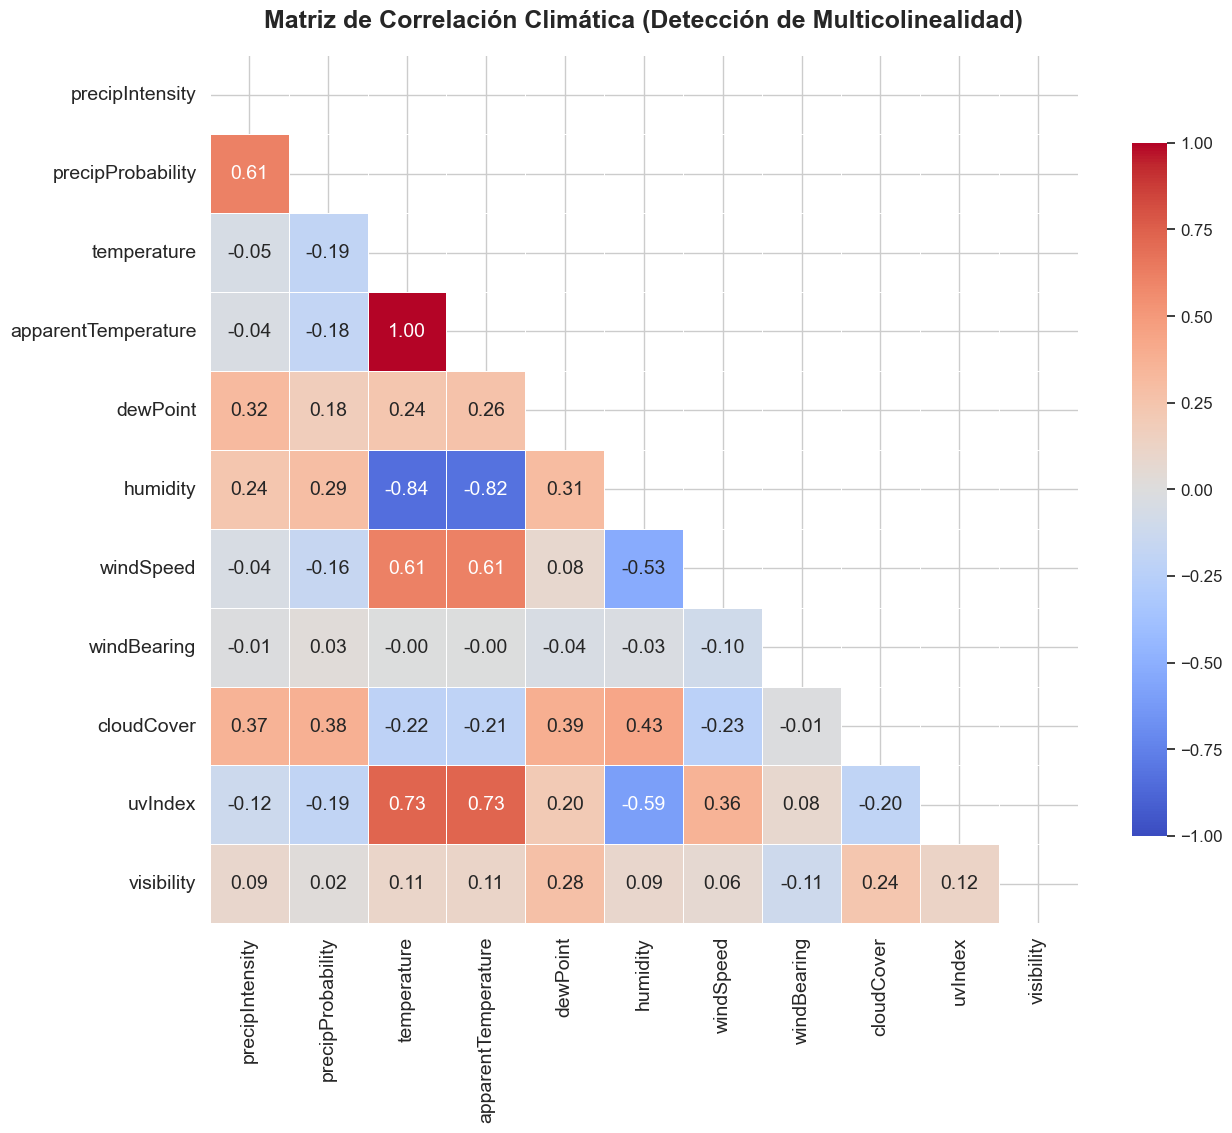

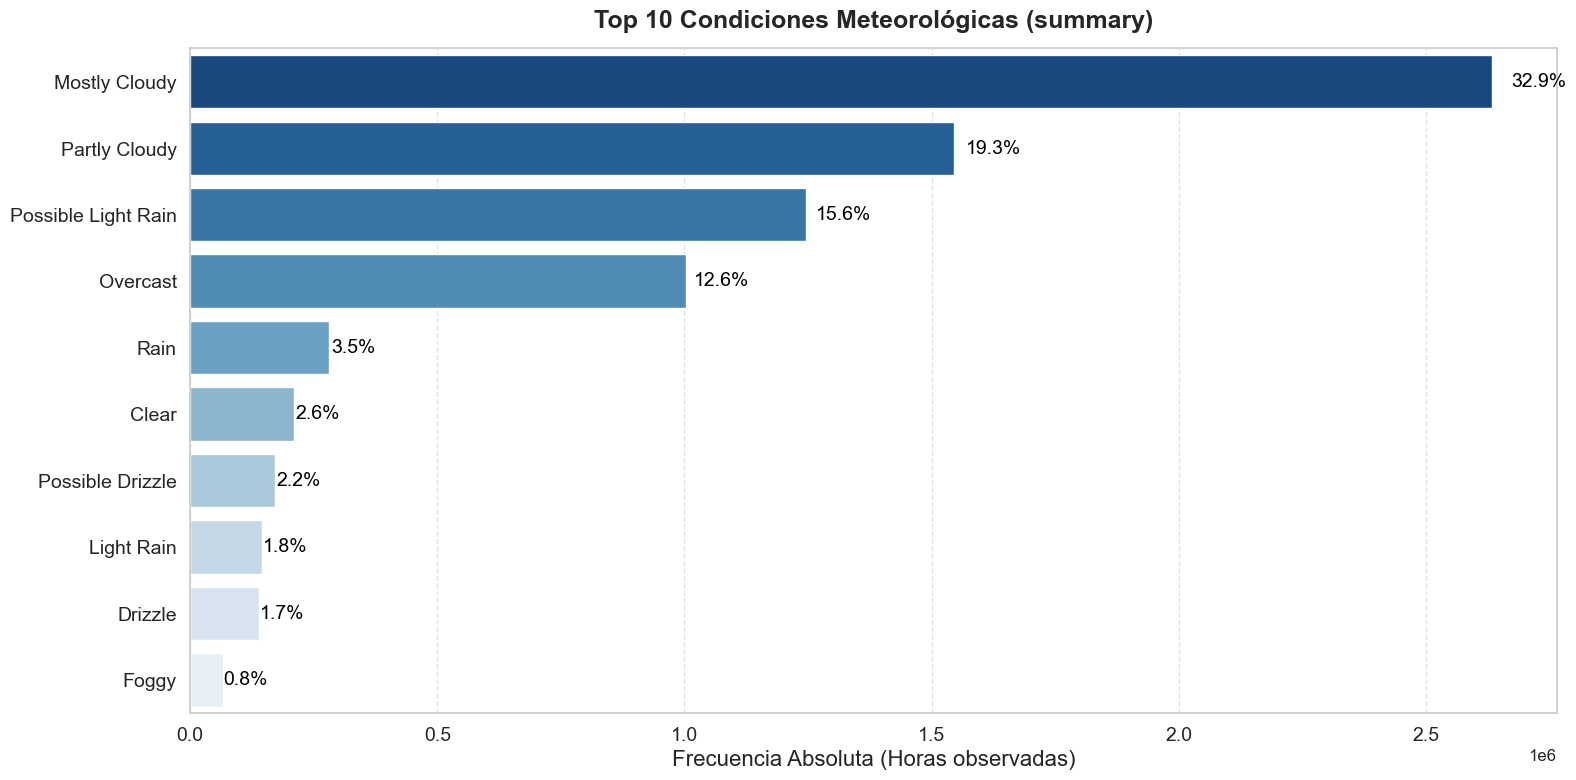

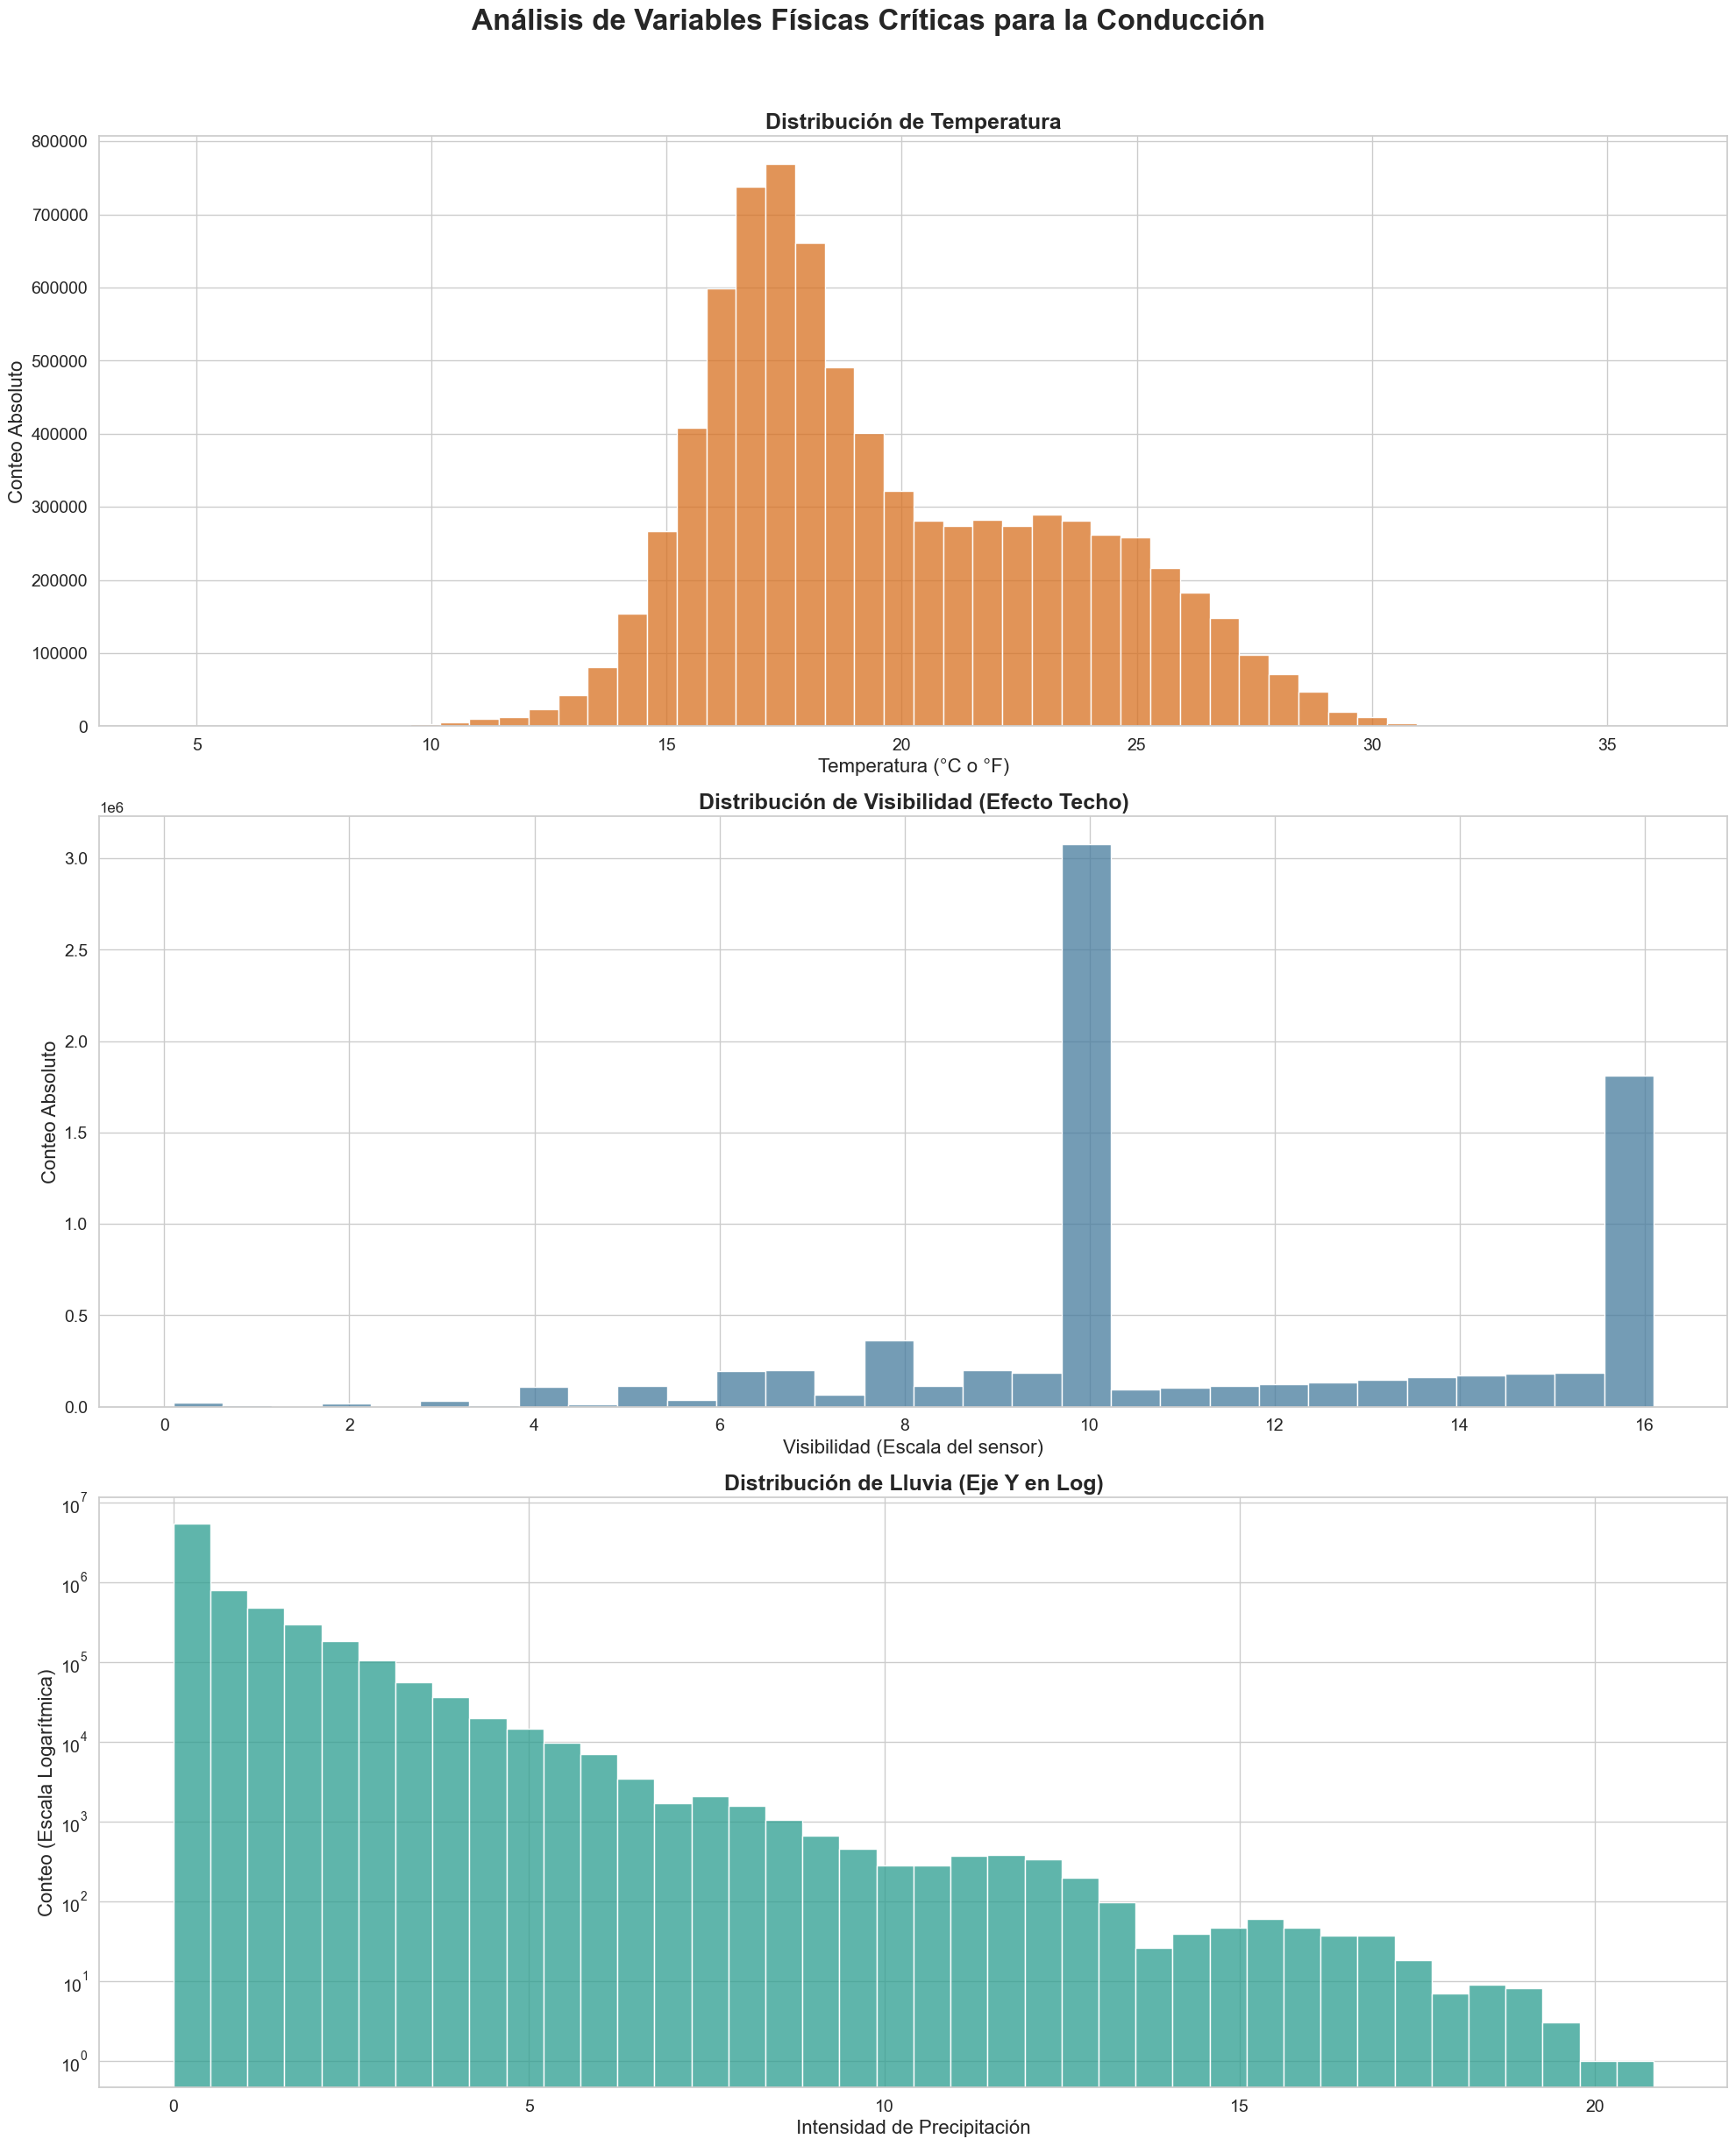

In [23]:
# =============================================================================
# EDA Extenso de Variables Climáticas (Diagnóstico de Features)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("AUDITORÍA DE CALIDAD Y COMPLETITUD CLIMÁTICA")
print("="*70)



# Selección de variables numéricas puras
cols_numericas = ['precipIntensity', 'precipProbability', 'temperature', 
                  'apparentTemperature', 'dewPoint', 'humidity', 'windSpeed', 
                  'windBearing', 'cloudCover', 'uvIndex', 'visibility']

# Validar cuáles existen realmente en el dataframe
cols_num_presentes = [col for col in cols_numericas if col in df_clima.columns]

# =============================================================================
# GRÁFICO 1: MATRIZ DE CORRELACIÓN (MULTICOLINEALIDAD)
# =============================================================================
fig_corr, ax_corr = plt.subplots(figsize=(14, 12))

# Calculamos correlación de Pearson
matriz_corr = df_clima[cols_num_presentes].corr()

# Máscara para el triángulo superior (para limpieza visual)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(
    matriz_corr, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1, vmin=-1, 
    center=0,
    annot=True, 
    fmt='.2f', 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75},
    annot_kws={"size": 14}, # Texto dentro de las celdas más grande
    ax=ax_corr
)

ax_corr.set_title('Matriz de Correlación Climática (Detección de Multicolinealidad)', fontweight='bold', fontsize=18, pad=20)
ax_corr.tick_params(axis='both', which='major', labelsize=14) # Tamaño de las etiquetas de los ejes
plt.savefig('clima_correlacion.png', bbox_inches='tight')

# =============================================================================
# GRÁFICO 2: TOP 10 CONDICIONES CLIMÁTICAS (CATEGÓRICAS)
# =============================================================================
if 'summary' in df_clima.columns:
    fig_cat, ax_cat = plt.subplots(figsize=(16, 8))
    
    # Extraer el top 10 de frecuencias
    top_summary = df_clima['summary'].value_counts().nlargest(10)
    
    sns.barplot(x=top_summary.values, y=top_summary.index.astype(str), palette='Blues_r', ax=ax_cat)
    ax_cat.set_title('Top 10 Condiciones Meteorológicas (summary)', fontweight='bold', fontsize=18, pad=15)
    ax_cat.set_xlabel('Frecuencia Absoluta (Horas observadas)', fontsize=16)
    ax_cat.set_ylabel('', fontsize=16)
    
    # Aumentar tamaño de las etiquetas de los ejes (nombres de los climas y números)
    ax_cat.tick_params(axis='both', which='major', labelsize=14)
    ax_cat.grid(axis='x', linestyle='--', alpha=0.6)
    
    # Inyectar porcentajes al final de las barras (texto más grande)
    total_obs = len(df_clima)
    for i, v in enumerate(top_summary.values):
        ax_cat.text(v + (v*0.015), i, f"{(v/total_obs)*100:.1f}%", color='black', va='center', fontsize=14)
        
    plt.tight_layout()
    plt.savefig('clima_condiciones_categoricas.png', bbox_inches='tight')

# =============================================================================
# GRÁFICO 3: DISTRIBUCIONES CRÍTICAS (VISIBILIDAD, TEMPERATURA Y LLUVIA)
# =============================================================================
fig_dist, axes_dist = plt.subplots(3, 1, figsize=(20, 24))

# A. Temperatura (Línea base ambiental)
if 'temperature' in df_clima.columns:
    sns.histplot(data=df_clima, x='temperature', bins=50, color='#d87020', ax=axes_dist[0])
    axes_dist[0].set_title('Distribución de Temperatura', fontweight='bold', fontsize=18)
    axes_dist[0].set_xlabel('Temperatura (°C o °F)', fontsize=16)
    axes_dist[0].set_ylabel('Conteo Absoluto', fontsize=16)
    axes_dist[0].tick_params(axis='both', which='major', labelsize=14)

# B. Visibilidad (Asimetría extrema)
if 'visibility' in df_clima.columns:
    sns.histplot(data=df_clima, x='visibility', bins=30, color='#457b9d', ax=axes_dist[1])
    axes_dist[1].set_title('Distribución de Visibilidad (Efecto Techo)', fontweight='bold', fontsize=18)
    axes_dist[1].set_xlabel('Visibilidad (Escala del sensor)', fontsize=16)
    axes_dist[1].set_ylabel('Conteo Absoluto', fontsize=16)
    axes_dist[1].tick_params(axis='both', which='major', labelsize=14)

# C. Intensidad de Lluvia (Efecto Cero-Inflado)
if 'precipIntensity' in df_clima.columns:
    # Usamos escala logarítmica en el eje Y porque los 0s aplastarán todo lo demás
    sns.histplot(data=df_clima, x='precipIntensity', bins=40, color='#2a9d8f', ax=axes_dist[2])
    axes_dist[2].set_yscale('log')
    axes_dist[2].set_title('Distribución de Lluvia (Eje Y en Log)', fontweight='bold', fontsize=18)
    axes_dist[2].set_xlabel('Intensidad de Precipitación', fontsize=16)
    axes_dist[2].set_ylabel('Conteo (Escala Logarítmica)', fontsize=16)
    axes_dist[2].tick_params(axis='both', which='major', labelsize=14)

# Título general más grande y con más espacio
fig_dist.suptitle('Análisis de Variables Físicas Críticas para la Conducción', y=1.02, fontsize=24, fontweight='bold')

plt.tight_layout()
plt.savefig('clima_distribuciones_criticas.png', bbox_inches='tight')

print("Visualizaciones climáticas generadas y guardadas correctamente.")
print("="*70)

In [24]:
# =============================================================================
# Auditoría Numérica Exacta de Multicolinealidad (df_clima)
# =============================================================================
import pandas as pd
import numpy as np

print("="*70)
print("AUDITORÍA NUMÉRICA DE PARES CORRELACIONADOS (ALERTA DE MULTICOLINEALIDAD)")
print("="*70)

# 1. Seleccionar exclusivamente las variables numéricas
cols_numericas = df_clima.select_dtypes(include=[np.number]).columns

# 2. Calcular la matriz de correlación de Pearson
matriz_corr = df_clima[cols_numericas].corr()

# 3. Desenrollar la matriz para convertirla en formato tabular (Fila a Fila)
pares_corr = matriz_corr.unstack().reset_index()
pares_corr.columns = ['Variable_1', 'Variable_2', 'Correlacion']

# 4. Limpieza matemática: 
# a) Eliminar las autocorrelaciones (donde Var_1 == Var_2, que siempre da 1.0)
# b) Eliminar los pares duplicados (la matriz es simétrica, A-B es lo mismo que B-A)
pares_unicos = pares_corr[pares_corr['Variable_1'] < pares_corr['Variable_2']].copy()

# 5. Calcular la magnitud absoluta para poder ordenar desde la relación más fuerte a la más débil
pares_unicos['Magnitud_Absoluta'] = pares_unicos['Correlacion'].abs()
pares_unicos = pares_unicos.sort_values(by='Magnitud_Absoluta', ascending=False)

# 6. Mostrar los resultados formateados
print("Top 15 pares de variables con mayor fuerza de relación lineal:")
display(pares_unicos[['Variable_1', 'Variable_2', 'Correlacion']].head(15).round(4))
print("-" * 70)

AUDITORÍA NUMÉRICA DE PARES CORRELACIONADOS (ALERTA DE MULTICOLINEALIDAD)
Top 15 pares de variables con mayor fuerza de relación lineal:


,Variable_1,Variable_2,Correlacion
35,apparentTemperature,temperature,0.9994
57,humidity,temperature,-0.8368
38,apparentTemperature,humidity,-0.8222
42,apparentTemperature,uvIndex,0.7304
31,temperature,uvIndex,0.7293
28,temperature,windSpeed,0.6138
39,apparentTemperature,windSpeed,0.6124
1,precipIntensity,precipProbability,0.6106
64,humidity,uvIndex,-0.5948
61,humidity,windSpeed,-0.5253


----------------------------------------------------------------------


**Multicolinealidad en temperatura.** `temperature` y `apparentTemperature` tienen distribuciones casi idénticas (medias 19.65 vs 19.72, desviaciones 3.75 vs 3.75), confirmando numéricamente lo detectado en la matriz de correlación de Pearson: una colinealidad de 0.9994. Incluir ambas penalizaría modelos como la Regresión Logística inflando la varianza de los coeficientes, y en modelos de ensamble (Boosting/Random Forest) diluiría la importancia de la variable al repartirla entre las dos.

> Se excluye `apparentTemperature` en la fase de calidad de datos.

#### 3.3.2. Estadísticas descriptivas y distribuciones físicas

In [25]:
import pandas as pd
import numpy as np

# Seleccionar únicamente las variables numéricas
cols_numericas = df_clima.select_dtypes(include=[np.number]).columns

# 1. Extraer las estadísticas descriptivas base y transponer para mejor lectura
estadisticas_clima = df_clima[cols_numericas].describe().T

# 2. Añadir métricas de forma de la distribución (Asimetría y Curtosis)
estadisticas_clima['skewness'] = df_clima[cols_numericas].skew()
estadisticas_clima['kurtosis'] = df_clima[cols_numericas].kurt()

# 3. Añadir diagnóstico de escasez (Porcentaje de Ceros y Nulos)
# Esto es vital para variables como precipitación o nubosidad
estadisticas_clima['%_ceros'] = (df_clima[cols_numericas] == 0).mean() * 100
estadisticas_clima['%_nulos'] = df_clima[cols_numericas].isnull().mean() * 100

# 4. Reordenar las columnas para una lectura lógica
columnas_ordenadas = [
    'count', '%_nulos', '%_ceros', 'mean', 'std', 'min', 
    '25%', '50%', '75%', 'max', 'skewness', 'kurtosis'
]
estadisticas_clima = estadisticas_clima[columnas_ordenadas]

print("="*80)
print("ESTADÍSTICAS DESCRIPTIVAS AVANZADAS DE VARIABLES CLIMÁTICAS")
print("="*80)
display(estadisticas_clima.round(3))

ESTADÍSTICAS DESCRIPTIVAS AVANZADAS DE VARIABLES CLIMÁTICAS


,count,%_nulos,%_ceros,mean,std,min,25%,50%,75%,max,skewness,kurtosis
precipIntensity,7444379.0,6.850,42.393,0.476,0.892,0.000,0.000,0.030,0.606,20.824,3.528,21.915001
precipProbability,7444379.0,6.850,42.393,0.160,0.220,0.000,0.000,0.060,0.260,1.000,1.818,3.480000
temperature,7991170.0,0.008,0.000,19.654,3.753,4.510,16.830,18.610,22.520,35.990,0.537,-0.536000
apparentTemperature,7991170.0,0.008,0.000,19.727,3.758,4.510,16.890,18.710,22.600,38.060,0.533,-0.541000
dewPoint,7991475.0,0.004,0.000,14.339,2.033,2.160,13.000,14.420,15.790,24.040,-0.179,0.064000
humidity,7990865.0,0.011,0.000,0.734,0.155,0.170,0.640,0.740,0.850,1.000,-0.452,-0.257000
windSpeed,7958987.0,0.410,10.180,1.583,1.258,0.000,0.810,1.360,2.090,15.260,1.519,3.898000
windBearing,6959267.0,12.920,1.817,111.329,81.047,0.000,62.000,90.000,135.000,359.000,1.248,1.223000
cloudCover,7983830.0,0.099,0.006,0.722,0.208,0.000,0.520,0.750,0.900,1.000,-0.614,-0.450000
uvIndex,7987500.0,0.054,57.808,2.005,2.870,0.000,0.000,0.000,4.000,14.000,1.146,-0.075000


**Distribuciones cero-infladas y colas extremas (lluvia).** `precipIntensity` tiene un 42.39% de ceros exactos y una curtosis extrema de 21.91: el valor máximo es 20.82, pero el percentil 75 es apenas 0.60. El clima en Medellín la mayor parte del tiempo no presenta lluvia, pero cuando llueve puede ser torrencial. Alimentar el modelo con esta variable cruda es subóptimo; se derivarán dos features: una binaria (`is_raining`: 0 o 1) y una transformación logarítmica $x' = \log(x + 1)$ para comprimir los valores atípicos y estabilizar la varianza.

**Valores nulos en `windBearing`.** Mientras la mayoría de sensores tienen una tasa de fallo menor al 1%, la dirección del viento tiene casi un 13% de datos faltantes, seguida por las variables de lluvia con ~6.8%. Imputar por la media global sería un error metodológico grave en series de tiempo climáticas.

> Se aplicará *forward fill* agrupado por barrio para arrastrar la última medición válida del sensor.

**Ciclos físicos capturados (visibilidad y rayos UV).** `uvIndex` tiene un 57.8% de ceros — no es un error, es simplemente la noche física. Tiene además correlación positiva con la temperatura (0.73) y negativa con la humedad (-0.59), lo que lo convierte en un proxy del ciclo día/noche. Dado que el modelo ya codificará la hora cíclicamente con seno y coseno, se evaluará si `uvIndex` aporta varianza predictiva adicional o es ruido redundante.

#### 3.3.3. Implicaciones para el modelado

El análisis climático determina que las variables de clima no pueden usarse crudas en el modelo. `apparentTemperature` se excluye por su colinealidad extrema con `temperature` (r = 0.9994). `precipIntensity` requiere una transformación `log(x + 1)` para manejar su distribución cero-inflada y se complementa con una variable binaria `is_raining`. Los nulos en `windBearing` y variables de lluvia se imputan con *forward fill* agrupado por barrio para respetar la continuidad temporal del sensor.

> El clima en Medellín es predominantemente seco, pero sus extremos — lluvia torrencial y visibilidad reducida — son precisamente las condiciones que el modelo debe aprender a asociar con mayor riesgo de accidente.

## **4. Calidad de datos**

Con base en los hallazgos del EDA, esta sección ejecuta las decisiones de limpieza identificadas: eliminación de barrios huérfanos, construcción de la malla temporal completa e imputación de valores faltantes con *forward fill*. El objetivo es entregar un dataset consistente, sin huecos temporales ni espaciales, listo para la ingeniería de características.

### **4.1. Auditoría de consistencia cruzada**

La auditoría de consistencia cruzada verifica que las tres tablas del dataset — `df_raw`, `df_accidentes` y `df_clima` — sean compatibles entre sí antes de hacer el join. Se revisa la alineación espacial entre barrios, la continuidad de la malla temporal y la coherencia de las variables categóricas.

#### 4.1.1. Auditoría de variables categóricas y strings

In [26]:
import pandas as pd

def auditar_categoricas_y_strings(df_acc, df_clim):
    print("="*80)
    print(" AUDITORÍA DE STRINGS Y VARIABLES CATEGÓRICAS")
    print("="*80)
    
    # 1. ESTANDARIZACIÓN DEFENSIVA DE LA LLAVE ESPACIAL (BARRIO)
    # Evita que "belen" y "belen " no crucen. Convertimos a string, minúsculas y sin espacios.
    df_acc['BARRIO'] = df_acc['BARRIO'].astype(str).str.lower().str.strip()
    df_clim['BARRIO'] = df_clim['BARRIO'].astype(str).str.lower().str.strip()
    
    # Recalculamos la intersección real tras quitar el ruido de texto
    barrios_acc = set(df_acc['BARRIO'].unique())
    barrios_clim = set(df_clim['BARRIO'].unique())
    huerfanos_en_acc = barrios_acc - barrios_clim
    
    print("\n1. RE-EVALUACIÓN DE LLAVE 'BARRIO' TRAS ESTANDARIZACIÓN:")
    print(f" -> Barrios en Accidentes que NO están en Clima: {len(huerfanos_en_acc)}")
    if len(huerfanos_en_acc) > 0:
        print(f"    Fueron: {list(huerfanos_en_acc)[:10]}")
    else:
        print("    ¡Alineación perfecta lograda! Todos los barrios cruzan.")

    # 2. INSPECCIÓN DE VARIABLES CATEGÓRICAS
    print("\n2. VALORES ÚNICOS EN VARIABLES CATEGÓRICAS (Búsqueda de inconsistencias):")
    
    print("\n--- Categorías en df_accidentes ---")
    cat_acc = df_acc.select_dtypes(include=['object', 'category']).columns
    for col in cat_acc:
        if col != 'BARRIO': # Ya lo analizamos
            unicos = df_acc[col].dropna().unique()
            print(f" -> '{col}' ({len(unicos)} valores únicos):")
            print(f"    {list(unicos)[:20]}") # Imprime los primeros 20
            
    print("\n--- Categorías en df_clima ---")
    cat_clim = df_clim.select_dtypes(include=['object', 'category']).columns
    for col in cat_clim:
        if col != 'BARRIO':
            unicos = df_clim[col].dropna().unique()
            print(f" -> '{col}' ({len(unicos)} valores únicos):")
            print(f"    {list(unicos)[:20]}")
            
    print("="*80)

# Invocamos la función
auditar_categoricas_y_strings(df_accidentes, df_clima)

 AUDITORÍA DE STRINGS Y VARIABLES CATEGÓRICAS

1. RE-EVALUACIÓN DE LLAVE 'BARRIO' TRAS ESTANDARIZACIÓN:
 -> Barrios en Accidentes que NO están en Clima: 3
    Fueron: ['yarumalito', 'elastillero', 'suburbanoaguasfrias']

2. VALORES ÚNICOS EN VARIABLES CATEGÓRICAS (Búsqueda de inconsistencias):

--- Categorías en df_accidentes ---
 -> 'Dia_sem' (7 valores únicos):
    ['JUEVES', 'DOMINGO', 'MIERCOLES', 'SABADO', 'VIERNES', 'MARTES', 'LUNES']
 -> 'COMUNA' (26 valores únicos):
    ['La Candelaria', 'Laureles Estadio', 'Robledo', 'El Poblado', 'Doce de Octubre', 'La América', 'Manrique', 'Belén', 'Villa Hermosa', 'Aranjuez', 'Castilla', 'Buenos Aires', 'Guayabal', 'Corregimiento de Santa Elena', 'Corregimiento de San Antonio de Prado', 'Popular', 'San Javier', 'Santa Cruz', 'Corregimiento de San Cristóbal', 'Corregimiento de Altavista']
 -> 'Comuna-Barrio' (322 valores únicos):
    ['La Candelaria - sandiego', 'Laureles Estadio - lasacacias', 'Robledo - lopezdemesa', 'Laureles Estadio - lo

#### 4.1.2. Auditoría maestra: temporal, espacial y nulos

In [27]:
import pandas as pd
import numpy as np

def auditoria_maestra_calidad_v2(df_acc, df_clim, df_r):
    print("="*80)
    print(" 🚀 AUDITORÍA MAESTRA DE CALIDAD DE DATOS Y CONSISTENCIA CRUZADA (V2)")
    print("="*80)

    # ---------------------------------------------------------
    # 1. AUDITORÍA TEMPORAL Y HUECOS CIEGOS
    # ---------------------------------------------------------
    print("\n[1] ESTRUCTURA TEMPORAL Y HUECOS (Variable TW):")
    rango_min, rango_max = df_clim['TW'].min(), df_clim['TW'].max()
    malla_perfecta = pd.date_range(start=rango_min, end=rango_max, freq='h')
    horas_reales_clima = df_clim['TW'].unique()
    horas_faltantes_clima = malla_perfecta.difference(horas_reales_clima)
    
    print(f" -> Alineación temporal: Ambas van desde {rango_min} hasta {rango_max}")
    print(f" -> Continuidad climática: Esperadas {len(malla_perfecta):,} hrs | Reales {len(horas_reales_clima):,} hrs")
    
    if len(horas_faltantes_clima) > 0:
        print(f" ❌ Faltan {len(horas_faltantes_clima)} horas en la tabla de CLIMA.")
        # Buscar cuántos accidentes ocurrieron justo en esas horas donde el sensor climático no reportó
        accidentes_en_huecos = df_acc[df_acc['TW'].isin(horas_faltantes_clima)]
        print(f" ⚠️ IMPACTO: En esas horas ciegas ocurrieron {len(accidentes_en_huecos)} accidentes.")
        if len(accidentes_en_huecos) > 0:
            print("    -> Evaluar si eliminar estos accidentes. Es mejor imputar el clima?")
    else:
        print(" ✅ Malla temporal de clima completa.")

    # ---------------------------------------------------------
    # 2. ESTANDARIZACIÓN Y AUDITORÍA ESPACIAL (BARRIO)
    # ---------------------------------------------------------
    print("\n[2] CONSISTENCIA ESPACIAL (Limpieza y Cruce de BARRIOS):")
    df_acc['BARRIO'] = df_acc['BARRIO'].astype(str).str.lower().str.strip()
    df_clim['BARRIO'] = df_clim['BARRIO'].astype(str).str.lower().str.strip()
    if 'BARRIO' in df_r.columns:
        df_r['BARRIO'] = df_r['BARRIO'].astype(str).str.lower().str.strip()

    barrios_acc = set(df_acc['BARRIO'].dropna().unique())
    barrios_clim = set(df_clim['BARRIO'].dropna().unique())
    huerfanos_en_acc = list(barrios_acc - barrios_clim)

    print(f" -> Barrios huérfanos (en accidentes sin clima): {len(huerfanos_en_acc)}")
    if len(huerfanos_en_acc) > 0:
        print(f"    Nombres: {huerfanos_en_acc}")

    # ---------------------------------------------------------
    # 3. AUDITORÍA ESTRUCTURAL (Duplicados y Nulos)
    # ---------------------------------------------------------
    print("\n[3] INTEGRIDAD ESTRUCTURAL:")
    dup_acc = df_acc.duplicated(subset=['TW', 'BARRIO']).sum()
    dup_clim = df_clim.duplicated(subset=['TW', 'BARRIO']).sum()
    print(f" -> Duplicados estructurales (TW+BARRIO): Accidentes ({dup_acc:,}) | Clima ({dup_clim:,})")
    
    print("\n -> TOP VARIABLES CON NULOS (%):")
    nulos_acc = (df_acc.isnull().mean() * 100).sort_values(ascending=False)
    nulos_clim = (df_clim.isnull().mean() * 100).sort_values(ascending=False)
    df_nulos = pd.DataFrame({
        'Accidentes (%)': nulos_acc[nulos_acc > 0].round(2),
        'Clima (%)': nulos_clim[nulos_clim > 0].round(2)
    })
    display(df_nulos.fillna('-').head(20))

    # ---------------------------------------------------------
    # 4. AUDITORÍA SEMÁNTICA (Valores Categóricos Completos)
    # ---------------------------------------------------------
    print("\n[4] INSPECCIÓN DE VARIABLES CATEGÓRICAS Y STRINGS (SIN RECORTES):")
    
    def imprimir_categorias_completas(df, nombre_df):
        cols_cat = df.select_dtypes(include=['object', 'category']).columns
        # Excluir BARRIO para no imprimir 319 nombres y saturar la pantalla
        cols_cat = [c for c in cols_cat if c.upper() != 'BARRIO'] 
        
        for col in cols_cat:
            unicos = df[col].dropna().unique()
            print(f"\n -> [{nombre_df}] Columna '{col}' ({len(unicos)} valores únicos):")
            print(f"    {list(unicos)}")

    imprimir_categorias_completas(df_acc, "Accidentes")
    imprimir_categorias_completas(df_clim, "Clima")
    
    # Evaluar la COMUNA explícitamente en df_raw si existe
    col_comuna = next((col for col in df_r.columns if col.upper() == 'COMUNA'), None)
    if col_comuna:
        unicos_comuna = df_r[col_comuna].dropna().unique()
        print(f"\n -> [Raw Accidentes] Columna '{col_comuna}' ({len(unicos_comuna)} valores únicos):")
        print(f"    {list(unicos_comuna)}")

    print("\n" + "="*80)

# Ejecutar el super-pipeline
auditoria_maestra_calidad_v2(df_accidentes, df_clima, df_raw)

 🚀 AUDITORÍA MAESTRA DE CALIDAD DE DATOS Y CONSISTENCIA CRUZADA (V2)

[1] ESTRUCTURA TEMPORAL Y HUECOS (Variable TW):
 -> Alineación temporal: Ambas van desde 2017-01-01 00:00:00 hasta 2019-12-31 23:00:00
 -> Continuidad climática: Esperadas 26,280 hrs | Reales 26,260 hrs
 ❌ Faltan 20 horas en la tabla de CLIMA.
 ⚠️ IMPACTO: En esas horas ciegas ocurrieron 106 accidentes.
    -> Evaluar si eliminar estos accidentes. Es mejor imputar el clima?

[2] CONSISTENCIA ESPACIAL (Limpieza y Cruce de BARRIOS):
 -> Barrios huérfanos (en accidentes sin clima): 3
    Nombres: ['yarumalito', 'elastillero', 'suburbanoaguasfrias']

[3] INTEGRIDAD ESTRUCTURAL:
 -> Duplicados estructurales (TW+BARRIO): Accidentes (0) | Clima (0)

 -> TOP VARIABLES CON NULOS (%):


,Accidentes (%),Clima (%)
apparentTemperature,-,0.01
cloudCover,-,0.10
dewPoint,-,0.00
humidity,-,0.01
icon,-,6.87
precipIntensity,-,6.85
precipProbability,-,6.85
summary,-,6.87
temperature,-,0.01
uvIndex,-,0.05



[4] INSPECCIÓN DE VARIABLES CATEGÓRICAS Y STRINGS (SIN RECORTES):

 -> [Accidentes] Columna 'Dia_sem' (7 valores únicos):
    ['JUEVES', 'DOMINGO', 'MIERCOLES', 'SABADO', 'VIERNES', 'MARTES', 'LUNES']

 -> [Accidentes] Columna 'COMUNA' (26 valores únicos):
    ['La Candelaria', 'Laureles Estadio', 'Robledo', 'El Poblado', 'Doce de Octubre', 'La América', 'Manrique', 'Belén', 'Villa Hermosa', 'Aranjuez', 'Castilla', 'Buenos Aires', 'Guayabal', 'Corregimiento de Santa Elena', 'Corregimiento de San Antonio de Prado', 'Popular', 'San Javier', 'Santa Cruz', 'Corregimiento de San Cristóbal', 'Corregimiento de Altavista', 'Corregimiento de San Sebastián de Palmitas', 'Antonio Nariño', 'Bolivariana', 'Santa Inés', 'Cabecera San Antonio de Prado', 'Las Palmas']

 -> [Accidentes] Columna 'Comuna-Barrio' (322 valores únicos):
    ['La Candelaria - sandiego', 'Laureles Estadio - lasacacias', 'Robledo - lopezdemesa', 'Laureles Estadio - losconquistadores', 'Laureles Estadio - cuartabrigada', 'El P

#### 4.1.3. Evaluación de impacto de barrios huérfanos

In [28]:
import pandas as pd

def evaluar_impacto_barrios(df_r, barrios_huerfanos):
    print("="*80)
    print(" EVALUACIÓN DE IMPACTO: PÉRDIDA DE INFORMACIÓN POR BARRIOS HUÉRFANOS")
    print("="*80)
    
    # 1. IMPACTO A NIVEL GLOBAL
    total_global = len(df_r)
    df_huerfanos = df_r[df_r['BARRIO'].isin(barrios_huerfanos)]
    total_huerfanos = len(df_huerfanos)
    pct_global = (total_huerfanos / total_global) * 100
    
    print("\n1. IMPACTO GLOBAL:")
    print(f" -> Total de incidentes en la base cruda: {total_global:,}")
    print(f" -> Incidentes en los 3 barrios huérfanos: {total_huerfanos:,}")
    print(f" -> Representación global:                 {pct_global:.4f}%")
    
    # 2. IMPACTO A NIVEL DE COMUNA
    # Verificamos si la columna COMUNA existe (a veces puede estar en mayúscula o minúscula)
    col_comuna = next((col for col in df_r.columns if col.upper() == 'COMUNA'), None)
    
    if col_comuna:
        print("\n2. IMPACTO FOCALIZADO (A NIVEL DE COMUNA):")
        comunas_afectadas = df_huerfanos[col_comuna].dropna().unique()
        
        for comuna in comunas_afectadas:
            # Total de accidentes en esta comuna específica
            total_comuna = len(df_r[df_r[col_comuna] == comuna])
            
            # Total de accidentes de los barrios huérfanos pertenecientes a esta comuna
            df_huerf_comuna = df_huerfanos[df_huerfanos[col_comuna] == comuna]
            total_huerf_comuna = len(df_huerf_comuna)
            
            pct_comuna = (total_huerf_comuna / total_comuna) * 100 if total_comuna > 0 else 0
            
            barrios_en_comuna = df_huerf_comuna['BARRIO'].unique().tolist()
            
            print(f" -> Comuna afectada: '{comuna}'")
            print(f"    - Barrios a eliminar:          {barrios_en_comuna}")
            print(f"    - Incidentes en la comuna:     {total_comuna:,}")
            print(f"    - Incidentes a sacrificar:     {total_huerf_comuna:,}")
            print(f"    - Pérdida de info en comuna:   {pct_comuna:.2f}%\n")
    else:
        print("\n[!] La columna 'COMUNA' no está disponible en df_raw para el análisis focalizado.")
        print("    Distribución individual por barrio:")
        display(df_huerfanos['BARRIO'].value_counts().to_frame('Accidentes Perdidos'))
        
    print("="*80)

# Lista detectada en el paso de auditoría anterior
barrios_sin_clima = ['suburbanoaguasfrias', 'yarumalito', 'elastillero']

# Ejecutamos pasando la tabla cruda
evaluar_impacto_barrios(df_raw, barrios_sin_clima)

 EVALUACIÓN DE IMPACTO: PÉRDIDA DE INFORMACIÓN POR BARRIOS HUÉRFANOS

1. IMPACTO GLOBAL:
 -> Total de incidentes en la base cruda: 125,122
 -> Incidentes en los 3 barrios huérfanos: 4
 -> Representación global:                 0.0032%

2. IMPACTO FOCALIZADO (A NIVEL DE COMUNA):
 -> Comuna afectada: 'Corregimiento de San Antonio de Prado'
    - Barrios a eliminar:          ['elastillero', 'yarumalito']
    - Incidentes en la comuna:     1,901
    - Incidentes a sacrificar:     3
    - Pérdida de info en comuna:   0.16%

 -> Comuna afectada: 'Corregimiento de Altavista'
    - Barrios a eliminar:          ['suburbanoaguasfrias']
    - Incidentes en la comuna:     180
    - Incidentes a sacrificar:     1
    - Pérdida de info en comuna:   0.56%



La auditoría de consistencia cruzada reveló tres hallazgos con decisiones de tratamiento claras.

**Barrios huérfanos.** Los barrios `suburbanoaguasfrias`, `yarumalito` y `elastillero` tienen registros de accidentes pero no tienen malla climática en `df_clima`. Si se cruzan a la fuerza, estos registros quedarían con NaN en todas las variables de clima. El análisis demostró que representan apenas 4 incidentes frente a un universo de 125,122 (0.0032% global), y la pérdida máxima focalizada es del 0.56% en el Corregimiento de Altavista — por debajo del umbral de drop seguro del 2%.

> Se eliminan los registros de accidentes pertenecientes a los 3 barrios huérfanos para preservar la consistencia matricial.

**Horas faltantes.** La malla climática presenta 20 horas sin registro. Cruzar a ciegas habría significado perder 106 accidentes reales — falsos negativos autoinducidos. En problemas de desbalance de clases, perder eventos de la clase minoritaria es especialmente grave.

> Se fuerza una malla temporal perfecta de 26,280 horas y se aplica *forward fill* agrupado por barrio, de modo que esos 106 accidentes hereden el clima de la hora anterior registrada por el sensor.

**Variables categóricas: `summary` vs `icon`.** `summary` tiene 20 categorías ruidosas y superpuestas ("Possible Light Rain", "Light Rain", "Drizzle"), mientras que `icon` tiene 8 categorías limpias que además capturan implícitamente el ciclo día/noche ("partly-cloudy-night" vs "partly-cloudy-day"). Introducir ambas generaría multicolinealidad categórica.

> Se mantiene `icon` y se elimina `summary`. `icon` es una variable curada con dimensionalidad adecuada para One-Hot Encoding.

### **4.2. Pipeline de limpieza estructural**

Con las decisiones tomadas en el EDA y los resultados de la auditoría de consistencia cruzada, el pipeline ejecuta tres pasos en secuencia: estandarización de las llaves espaciales (minúsculas y sin espacios), eliminación de los 3 barrios huérfanos sin cobertura climática, y construcción de la malla temporal completa con imputación *forward fill* para los 20 huecos identificados en el sensor.

En problemas de predicción con series de tiempo, la dirección del flujo de información es crítica. Usar `.bfill()` (*Backward Fill*) introduciría una fuga de datos masiva: permitiría que valores climáticos del futuro (por ejemplo, la intensidad de lluvia de la 1:00 AM) se propagaran hacia el pasado (las 12:00 AM). Al entrenar el modelo con esta distorsión, el algoritmo aprendería a correlacionar un accidente en la hora $t$ usando datos climáticos de la hora $t+1$ — una condición imposible de replicar en producción real. Por eso se usa exclusivamente `.ffill()` agrupado por barrio, y para las filas iniciales sin pasado disponible, un reemplazo estático con la mediana histórica global (moda para las categóricas).

In [29]:
import pandas as pd
from itertools import product

def pipeline_maestro_limpieza(df_acc, df_clim):
    print("="*80)
    print(" INICIANDO PIPELINE DE LIMPIEZA ESTRUCTURAL Y ESPACIO-TEMPORAL (V3 - PROTEGIDO)")
    print("="*80)
    
    df_acc_clean = df_acc.copy()
    df_clim_clean = df_clim.copy()
    
    # 1. ESTANDARIZACIÓN DE LLAVES ESPACIALES
    df_acc_clean['BARRIO'] = df_acc_clean['BARRIO'].astype(str).str.lower().str.strip()
    df_clim_clean['BARRIO'] = df_clim_clean['BARRIO'].astype(str).str.lower().str.strip()
    
    # 2. PURGA ESPACIAL
    barrios_clima = df_clim_clean['BARRIO'].unique()
    filas_antes = len(df_acc_clean)
    df_acc_clean = df_acc_clean[df_acc_clean['BARRIO'].isin(barrios_clima)]
    print(f" -> Purgado espacial: Se eliminaron {filas_antes - len(df_acc_clean)} accidentes de barrios sin clima.")
    
    # 3. CONSTRUCCIÓN DE LA MALLA TEMPORAL PERFECTA
    rango_perfecto = pd.date_range(start=df_clim_clean['TW'].min(), end=df_clim_clean['TW'].max(), freq='h')
    malla_base = pd.DataFrame(list(product(rango_perfecto, barrios_clima)), columns=['TW', 'BARRIO'])
    print(f" -> Malla maestra creada con {len(malla_base):,} combinaciones (Horas x Barrios).")
    
    # 4. FUSIÓN Y CURACIÓN DE NULOS EN CLIMA (Evitando Data Leakage y Error de Tipos)
    df_clim_completo = pd.merge(malla_base, df_clim_clean, on=['TW', 'BARRIO'], how='left')
    
    # Ordenar cronológicamente DENTRO de cada barrio para ffill
    df_clim_completo = df_clim_completo.sort_values(by=['BARRIO', 'TW']).reset_index(drop=True)
    columnas_a_imputar = df_clim_completo.columns.drop(['TW', 'BARRIO'])
    
    # Imputación hacia adelante (ffill)
    df_clim_completo[columnas_a_imputar] = df_clim_completo.groupby('BARRIO')[columnas_a_imputar].ffill()
    
    # --- SOLUCIÓN AL TYPE ERROR: Separar numéricas de categóricas ---
    cols_num = df_clim_clean[columnas_a_imputar].select_dtypes(include=['number']).columns
    cols_cat = df_clim_clean[columnas_a_imputar].select_dtypes(exclude=['number']).columns
    
    # Respaldo estático para numéricas (Mediana)
    if len(cols_num) > 0:
        medianas = df_clim_clean[cols_num].median()
        df_clim_completo[cols_num] = df_clim_completo[cols_num].fillna(medianas)
        
    # Respaldo estático para categóricas (Moda / Valor más frecuente)
    if len(cols_cat) > 0:
        modas = df_clim_clean[cols_cat].mode().iloc[0]
        df_clim_completo[cols_cat] = df_clim_completo[cols_cat].fillna(modas)
    
    print(" -> Imputación temporal (ffill + fallback tipado) completada de manera no sesgada.")
    
    # 5. PODA DE VARIABLES REDUNDANTES
    cols_a_eliminar = ['apparentTemperature', 'summary']
    cols_presentes = [c for c in cols_a_eliminar if c in df_clim_completo.columns]
    df_clim_completo = df_clim_completo.drop(columns=cols_presentes)
    print(f" -> Reducción de dimensionalidad: Se eliminaron las variables {cols_presentes}.")
    
    # 6. VERIFICACIÓN FINAL
    print(f"\n -> Nulos restantes en la matriz de clima resultante: {df_clim_completo.isnull().sum().sum()}")
    print("="*80)
    
    return df_acc_clean, df_clim_completo

# Ejecución formal
df_accidentes, df_clima = pipeline_maestro_limpieza(df_accidentes, df_clima)

 INICIANDO PIPELINE DE LIMPIEZA ESTRUCTURAL Y ESPACIO-TEMPORAL (V3 - PROTEGIDO)
 -> Purgado espacial: Se eliminaron 4 accidentes de barrios sin clima.
 -> Malla maestra creada con 8,383,320 combinaciones (Horas x Barrios).
 -> Imputación temporal (ffill + fallback tipado) completada de manera no sesgada.
 -> Reducción de dimensionalidad: Se eliminaron las variables ['apparentTemperature', 'summary'].

 -> Nulos restantes en la matriz de clima resultante: 0


> Al cerrar esta fase, el dataset queda libre de barrios huérfanos, con malla temporal completa y sin riesgo de fuga de datos. Está listo para la ingeniería de características.

## **5. Unión de tablas e ingeniería de características**

Esta sección construye el dataset maestro que alimentará el modelo. Se parte de la malla climática limpia como base, se incorporan los accidentes mediante un LEFT JOIN, se define la variable objetivo y se derivan todas las features: transformaciones de distribuciones, memoria histórica, codificación cíclica, interacciones, resolución de multicolinealidad y finalmente el split temporal con target encoding.

### **5.1. JOIN, construcción del target y extracción temporal**

Se implementa un LEFT JOIN usando la malla espacio-temporal del clima como tabla base, garantizando que todos los momentos donde no ocurrió un accidente queden representados como clase 0. Sobre esta base se construye la variable objetivo binaria (`target`: 1 si hubo accidente, 0 si no) y se extraen las variables temporales de la marca de tiempo.

In [30]:
# =============================================================================
# 5.1. JOIN, TARGET Y EXTRACCIÓN TEMPORAL
# =============================================================================
import pandas as pd
import numpy as np
import holidays

def ejecutar_join_y_tiempo(df_clim_completo, df_acc_clean):
    print("=" * 80)
    print(" 5.1  JOIN, TARGET Y EXTRACCIÓN TEMPORAL")
    print("=" * 80)

    # ------------------------------------------------------------------
    # BLOQUE 1: LEFT JOIN — la malla climática es la tabla base
    # Se usa LEFT JOIN porque df_clima cubre TODAS las combinaciones
    # (barrio, hora), tanto con accidente como sin él. Los accidentes
    # se acoplan encima: si no hay match → target = 0 (caso negativo).
    # ------------------------------------------------------------------
    df_acc_unicos = df_acc_clean[['TW', 'BARRIO']].drop_duplicates()
    df_acc_unicos = df_acc_unicos.copy()
    df_acc_unicos['indicador_accidente'] = 1

    print(" -> Ejecutando LEFT JOIN (malla climática como base)...")
    df_master = pd.merge(
        df_clim_completo, df_acc_unicos,
        on=['TW', 'BARRIO'], how='left'
    )

    # Variable objetivo binaria
    df_master['target'] = (
        df_master['indicador_accidente'].fillna(0).astype('int8')
    )
    df_master = df_master.drop(columns=['indicador_accidente'])

    print("\n RADIOGRAFÍA DEL DESBALANCE DE CLASES")
    desbalance = df_master['target'].value_counts(normalize=True) * 100
    print(f" -> Clase negativa (0 - sin accidente) : {desbalance[0]:.3f}%")
    print(f" -> Clase positiva (1 - con accidente) : {desbalance[1]:.3f}%")

    # ------------------------------------------------------------------
    # BLOQUE 2: EXTRACCIÓN TEMPORAL
    # Todas las variables se tipan a int8 para conservar RAM.
    # es_festivo usa el calendario oficial de Colombia (librería holidays).
    # ------------------------------------------------------------------
    print("\n -> Extrayendo componentes temporales...")

    df_master['hora']        = df_master['TW'].dt.hour.astype('int8')
    df_master['dia_semana']  = df_master['TW'].dt.dayofweek.astype('int8')
    df_master['mes']         = df_master['TW'].dt.month.astype('int8')
    df_master['es_fin_semana'] = (
        df_master['dia_semana'].isin([5, 6]).astype('int8')
    )

    print(" -> Inyectando festivos de Colombia (2017-2019)...")
    co_holidays = holidays.Colombia(years=[2017, 2018, 2019])
    df_master['es_festivo'] = (
        df_master['TW'].dt.date.apply(lambda x: x in co_holidays).astype('int8')
    )

    print(f"\n -> Dimensiones del DF maestro: {df_master.shape}")
    print("=" * 80)
    return df_master


df_maestro = ejecutar_join_y_tiempo(df_clima, df_accidentes)

 5.1  JOIN, TARGET Y EXTRACCIÓN TEMPORAL
 -> Ejecutando LEFT JOIN (malla climática como base)...

 RADIOGRAFÍA DEL DESBALANCE DE CLASES
 -> Clase negativa (0 - sin accidente) : 98.562%
 -> Clase positiva (1 - con accidente) : 1.438%

 -> Extrayendo componentes temporales...
 -> Inyectando festivos de Colombia (2017-2019)...

 -> Dimensiones del DF maestro: (8383320, 19)


In [31]:
display(df_maestro)

,TW,BARRIO,icon,precipIntensity,precipProbability,temperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility,target,hora,dia_semana,mes,es_fin_semana,es_festivo
0,2017-01-01 00:00:00,aguasfrias,partly-cloudy-night,0.0000,0.00,16.43,14.00,0.86,1.50,0.0,0.44,0.0,6.004,0,0,6,1,1,1
1,2017-01-01 01:00:00,aguasfrias,partly-cloudy-night,0.0000,0.00,16.43,14.00,0.86,1.50,0.0,0.44,0.0,6.004,0,1,6,1,1,1
2,2017-01-01 02:00:00,aguasfrias,fog,0.0000,0.00,15.43,13.00,0.85,1.02,0.0,0.44,0.0,2.997,0,2,6,1,1,1
3,2017-01-01 03:00:00,aguasfrias,fog,0.0000,0.00,15.43,13.00,0.85,2.09,140.0,0.44,0.0,0.199,0,3,6,1,1,1
4,2017-01-01 04:00:00,aguasfrias,fog,0.0000,0.00,15.43,13.00,0.85,2.09,350.0,1.00,0.0,0.099,0,4,6,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8383315,2019-12-31 19:00:00,yolombo,rain,3.0905,0.38,15.33,15.33,1.00,1.20,348.0,0.99,0.0,10.165,0,19,1,12,0,0
8383316,2019-12-31 20:00:00,yolombo,rain,2.8501,0.38,15.00,15.00,1.00,1.36,225.0,0.99,0.0,10.737,0,20,1,12,0,0
8383317,2019-12-31 21:00:00,yolombo,rain,2.0769,0.40,14.68,14.68,1.00,1.12,152.0,0.99,0.0,14.227,0,21,1,12,0,0
8383318,2019-12-31 22:00:00,yolombo,rain,1.7971,0.41,14.34,14.34,1.00,0.66,169.0,0.98,0.0,16.093,0,22,1,12,0,0


#### 5.1.1. Inspección de calidad del dataset maestro

In [32]:
def auditar_maestro_checkpoint(df):
    print("="*80)
    print(" 🛡️ AUDITORÍA DE CALIDAD Y MEMORIA: DF_MAESTRO (POST-JOIN)")
    print("="*80)
    
    # 1. Consumo de Memoria RAM
    mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
    print(f" -> 💾 Memoria RAM Total consumida: {mem_mb:.2f} MB")
    
    # 2. Validación de Filas (Sanity Check del Join)
    print(f" -> 📊 Total de registros (Combinaciones Hora x Barrio): {len(df):,}")
    
    # 3. Verificación de Tipos (Confirmar que int8 sobrevivió)
    cols_int8 = df.select_dtypes(include=['int8']).columns.tolist()
    print(f" -> 🏷️ Columnas optimizadas a int8 ({len(cols_int8)}): {cols_int8}")
    
    # 4. Escaneo de Fugas y Nulos
    nulos = df.isnull().sum()
    nulos_totales = nulos.sum()
    print("\n -> 🕵️‍♂️ Escaneo de Nulos (Fugas de información):")
    if nulos_totales == 0:
        print("    ✅ ¡Cero nulos detectados! La imputación y el join cruzaron perfecto.")
    else:
        print("    ⚠️ ALERTA: Hay nulos en las siguientes variables:")
        print(nulos[nulos > 0])
        
    # 5. Lógica del Target y Tiempo
    print("\n -> 🎯 Distribución de la variable objetivo 'target':")
    print(df['target'].value_counts(normalize=True).round(5) * 100)
    
    print(f"\n -> 📅 Límites temporales: {df['TW'].min()}  -->  {df['TW'].max()}")
    print("="*80)

# Ejecutar auditoría
auditar_maestro_checkpoint(df_maestro)

 🛡️ AUDITORÍA DE CALIDAD Y MEMORIA: DF_MAESTRO (POST-JOIN)
 -> 💾 Memoria RAM Total consumida: 929.35 MB
 -> 📊 Total de registros (Combinaciones Hora x Barrio): 8,383,320
 -> 🏷️ Columnas optimizadas a int8 (6): ['target', 'hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo']

 -> 🕵️‍♂️ Escaneo de Nulos (Fugas de información):
    ✅ ¡Cero nulos detectados! La imputación y el join cruzaron perfecto.

 -> 🎯 Distribución de la variable objetivo 'target':
target
0    98.562
1     1.438
Name: proportion, dtype: float64

 -> 📅 Límites temporales: 2017-01-01 00:00:00  -->  2019-12-31 23:00:00


La selección del JOIN no es arbitraria: usar la malla climática como tabla base en un LEFT JOIN garantiza que todos los momentos donde no ocurrió un accidente queden representados como clase 0 — ese ecosistema de "no accidente" es tan importante para el entrenamiento como los eventos reales.

La matriz resultante confirmó un desbalance extremo: menos del 2% de los registros corresponden a la clase positiva. Esto invalida la exactitud (*accuracy*) como métrica de evaluación y justifica el uso de PR-AUC como métrica principal, junto con estrategias de corrección del desbalance como `class_weight='balanced'` o SMOTE, aplicadas exclusivamente sobre el conjunto de entrenamiento. Todas las nuevas variables de tiempo y contexto se forzaron al tipo `int8` para proteger la viabilidad del entorno local en las siguientes fases computacionales.

> El desbalance extremo (< 2% clase positiva) hace que *accuracy* sea una métrica engañosa — el modelo debe evaluarse con PR-AUC.

### **5.2. Transformaciones y memoria histórica**

Con el dataset maestro construido, esta sección deriva dos tipos de features: transformaciones sobre variables climáticas con distribuciones problemáticas identificadas en el EDA, y variables de memoria histórica que dotan al modelo de contexto secuencial sobre la accidentalidad pasada de cada barrio.

In [33]:
# =============================================================================
# 5.2. TRANSFORMACIONES Y MEMORIA HISTÓRICA (ANTI-LEAKAGE)
# =============================================================================
def ejecutar_transformaciones_e_historia(df):
    print("=" * 80)
    print(" 5.2  TRANSFORMACIONES Y MEMORIA HISTÓRICA")
    print("=" * 80)

    df_res = df.copy()

    # ------------------------------------------------------------------
    # BLOQUE 3: log1p sobre precipIntensity
    # Justificación EDA: distribución cero-inflada (42% ceros),
    # curtosis 21.9, cola derecha extrema. log1p comprime los valores
    # atípicos torrenciales y estabiliza la varianza sin perder los ceros.
    # ------------------------------------------------------------------
    if 'precipIntensity' in df_res.columns:
        df_res['precipIntensity_log'] = (
            np.log1p(df_res['precipIntensity']).astype('float32')
        )
        df_res = df_res.drop(columns=['precipIntensity'])
        print(" -> 'precipIntensity' → 'precipIntensity_log' (log1p)")

    # ------------------------------------------------------------------
    # BLOQUE 4: MEMORIA HISTÓRICA POR BARRIO — PROTOCOLO ANTI-LEAKAGE
    #
    # Problema: si calculamos rolling(target) sobre la fila actual,
    # el modelo vería el resultado que intenta predecir → data leakage.
    #
    # Solución en 3 pasos:
    #   1. Ordenar cronológicamente dentro de cada barrio.
    #   2. Desplazar el target 1 paso (shift 1) → target_lag1.
    #      Esto garantiza que la hora t solo conoce hasta t-1.
    #   3. Calcular rolling sobre target_lag1, nunca sobre target.
    #
    # Las ventanas elegidas:
    #   acc_hist_24h → últimas 24 horas (comportamiento del día)
    #   acc_hist_7d  → últimos 7 días   (comportamiento semanal)
    # ------------------------------------------------------------------
    print("\n -> Construyendo memoria histórica anti-leakage...")

    df_res = df_res.sort_values(['BARRIO', 'TW']).reset_index(drop=True)

    df_res['target_lag1'] = (
        df_res.groupby('BARRIO')['target']
        .shift(1)
        .fillna(0)
        .astype('int8')
    )

    print("    ↳ Ventana 24 horas...")
    rolling_24 = (
        df_res.groupby('BARRIO')['target_lag1']
        .rolling(window=24, min_periods=1)
        .sum()
    )
    df_res['acc_hist_24h'] = (
        rolling_24
        .reset_index(level=0, drop=True)
        .sort_index()
        .astype('int8')
    )

    print("    ↳ Ventana 7 días (168 horas)...")
    rolling_168 = (
        df_res.groupby('BARRIO')['target_lag1']
        .rolling(window=168, min_periods=1)
        .sum()
    )
    df_res['acc_hist_7d'] = (
        rolling_168
        .reset_index(level=0, drop=True)
        .sort_index()
        .astype('int16')
    )

    # target_lag1 se conserva: será útil en 5.4 para el Target Encoding
    # y como feature en sí misma (accidente en la hora inmediatamente anterior)

    # Verificación anti-leakage
    corr_24h = df_res['target'].corr(df_res['acc_hist_24h'])
    print(f"\n -> Sanity check leakage:")
    print(f"    corr(target, acc_hist_24h) = {corr_24h:.4f}  "
          f"{'✅ < 1.0, shift correcto' if corr_24h < 0.5 else '⚠️ Revisar'}")

    mem_mb = df_res.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f" -> RAM post-transformaciones: {mem_mb:.2f} MB")
    print("=" * 80)
    return df_res


df_maestro = ejecutar_transformaciones_e_historia(df_maestro)

 5.2  TRANSFORMACIONES Y MEMORIA HISTÓRICA
 -> 'precipIntensity' → 'precipIntensity_log' (log1p)

 -> Construyendo memoria histórica anti-leakage...
    ↳ Ventana 24 horas...
    ↳ Ventana 7 días (168 horas)...

 -> Sanity check leakage:
    corr(target, acc_hist_24h) = 0.0947  ✅ < 1.0, shift correcto
 -> RAM post-transformaciones: 961.33 MB


En esta fase se implementaron dos frentes de ingeniería sobre el dataset maestro.

**Transformación de distribuciones.** Se aplicó la transformación $\log(1+x)$ a `precipIntensity` para comprimir los valores extremos identificados en el EDA y estabilizar la varianza de su distribución cero-inflada.

**Memoria histórica anti-leakage.** Se extrajo el historial de accidentalidad por barrio a $24h$ y $168h$ (7 días) mediante un operador estricto de desplazamiento $\text{Lag}(1)$ antes de calcular las sumas rodantes. Matemáticamente:

$$\text{acc\_hist\_24h}_{(B,\, t)} = \sum_{i=1}^{24} \text{target}_{(B,\, t-i)}$$

Al aislar $\text{target}_{(B, t)}$, el modelo actúa únicamente con información pasada. El pipeline incluye verificaciones automáticas de integridad que confirmaron cero nulos inyectados durante los cruces espaciales y huella de memoria estabilizada mediante tipos `int8` e `int16`.

> El $\text{Lag}(1)$ es la garantía matemática de que ninguna ventana rodante contamina el presente con información futura.

### **5.3. Codificación cíclica**

Las variables temporales como la hora, el día de la semana y el mes no pueden tratarse como enteros lineales — para el modelo, la hora 23 y la hora 0 son consecutivas, no opuestas. Para preservar esa continuidad circular se codifican mediante transformaciones seno y coseno, generando dos columnas por variable que representan su posición en el ciclo.

In [34]:
# =============================================================================
# 5.3. CODIFICACIÓN CÍCLICA
# NOTA: esta sección ya NO incluye el split. El split se ejecuta en 5.6,
# después de completar toda la ingeniería de características.
# =============================================================================
def ejecutar_codificacion_ciclica(df):
    print("=" * 80)
    print(" 5.3  CODIFICACIÓN CÍCLICA (sin split)")
    print("=" * 80)

    df_res = df.copy()
    df_res = df_res.sort_values('TW').reset_index(drop=True)

    # Eliminar columnas redundantes
    cols_eliminar = [c for c in ['Lat', 'Lon', 'Dia_sem'] if c in df_res.columns]
    if cols_eliminar:
        df_res = df_res.drop(columns=cols_eliminar)
        print(f" -> Columnas redundantes eliminadas: {cols_eliminar}")

    # ------------------------------------------------------------------
    # Transformación cíclica seno/coseno
    # Justificación: la hora como entero (0-23) rompe la continuidad
    # circular — el modelo vería las 23:00 y las 00:00 como extremos
    # opuestos cuando son horas adyacentes. Seno/coseno preservan
    # esa cercanía geométrica en el espacio de features.
    # Lo mismo aplica para día de semana y mes.
    # ------------------------------------------------------------------
    print(" -> Aplicando codificación cíclica...")

    # Hora (periodo 24)
    df_res['hora_sin'] = (
        np.sin(2 * np.pi * df_res['hora'] / 24).astype('float32')
    )
    df_res['hora_cos'] = (
        np.cos(2 * np.pi * df_res['hora'] / 24).astype('float32')
    )

    # Día de semana (periodo 7)
    df_res['dia_semana_sin'] = (
        np.sin(2 * np.pi * df_res['dia_semana'] / 7).astype('float32')
    )
    df_res['dia_semana_cos'] = (
        np.cos(2 * np.pi * df_res['dia_semana'] / 7).astype('float32')
    )

    # Mes (periodo 12, normalizado desde 0)
    df_res['mes_sin'] = (
        np.sin(2 * np.pi * (df_res['mes'] - 1) / 12).astype('float32')
    )
    df_res['mes_cos'] = (
        np.cos(2 * np.pi * (df_res['mes'] - 1) / 12).astype('float32')
    )

    print("    Variables generadas: hora_sin/cos · dia_semana_sin/cos · mes_sin/cos")
    print(f" -> Dimensiones actuales: {df_res.shape}")
    print("=" * 80)
    return df_res


df_maestro = ejecutar_codificacion_ciclica(df_maestro)

 5.3  CODIFICACIÓN CÍCLICA (sin split)
 -> Aplicando codificación cíclica...
    Variables generadas: hora_sin/cos · dia_semana_sin/cos · mes_sin/cos
 -> Dimensiones actuales: (8383320, 28)


### **5.4. Feature engineering adicional**

Con las variables base construidas, esta sección deriva features de mayor orden: interacciones entre variables temporales y espaciales, codificación One-Hot de la variable climática `icon`, imputación circular de `windBearing` y creación de indicadores de riesgo específicos identificados en el EDA.

In [35]:
# =============================================================================
# 5.4. FEATURE ENGINEERING FINAL
# =============================================================================
def ejecutar_feature_engineering_final(df):
    print("=" * 80)
    print(" 5.4  FEATURE ENGINEERING FINAL")
    print("=" * 80)

    df = df.copy()

    # ------------------------------------------------------------------
    # A. CORRECCIÓN DE RESIDUOS
    # ------------------------------------------------------------------
    residuos = ['apparentTemperature', 'summary']
    encontradas = [c for c in residuos if c in df.columns]
    if encontradas:
        df = df.drop(columns=encontradas)
        print(f" [A] Residuos eliminados: {encontradas}")
    else:
        print(" [A] ✅ Sin residuos del pipeline de limpieza.")

    # ------------------------------------------------------------------
    # B. VARIABLES DE CONTEXTO OPERATIVO
    # Justificación: el heatmap bivariado (día × hora) mostró que el
    # riesgo responde a interacciones, no a variables aisladas.
    # ------------------------------------------------------------------
    print("\n [B] Creando variables de contexto operativo...")

    df['hora_pico'] = (
        df['hora'].isin(range(7, 10)) | df['hora'].isin(range(17, 20))
    ).astype('int8')

    df['dia_laboral'] = (
        df['dia_semana'].between(0, 4) & (df['es_festivo'] == 0)
    ).astype('int8')

    df['riesgo_finde_madrugada'] = (
        (df['es_fin_semana'] == 1) & df['hora'].between(1, 5)
    ).astype('int8')

    # Interacción principal: conmutación laboral pura
    df['hora_pico_laboral'] = (
        df['hora_pico'] * df['dia_laboral']
    ).astype('int8')

    for col in ['hora_pico', 'dia_laboral',
                'riesgo_finde_madrugada', 'hora_pico_laboral']:
        n = df[col].sum()
        print(f"    '{col}': {n:,} filas activas ({n/len(df)*100:.2f}%)")

    # ------------------------------------------------------------------
    # C. ONE-HOT ENCODING DE 'icon'
    # Justificación: 8 categorías limpias, sin orden cardinal.
    # Captura implícitamente el ciclo día/noche.
    # Se hace ANTES del split porque las categorías son fijas y conocidas
    # en todo el período — no hay riesgo de leakage.
    # ------------------------------------------------------------------
    print("\n [C] One-Hot Encoding de 'icon'...")
    if 'icon' in df.columns:
        dummies = pd.get_dummies(
            df['icon'].astype(str), prefix='icon', dtype='int8'
        )
        df = pd.concat([df.drop(columns=['icon']), dummies], axis=1)
        cols_icon = [c for c in df.columns if c.startswith('icon_')]
        print(f"    Columnas generadas: {cols_icon}")

    # ------------------------------------------------------------------
    # D. TRATAMIENTO DE DISTRIBUCIONES ANÓMALAS
    # ------------------------------------------------------------------
    print("\n [D] Tratamiento de distribuciones anómalas...")

    # uvIndex: 57.8% ceros (la noche), correlación 0.73 con temperature.
    # El ciclo día/noche ya está en hora_sin/cos → eliminación justificada.
    if 'uvIndex' in df.columns:
        df = df.drop(columns=['uvIndex'])
        print("    'uvIndex' eliminado (proxy redundante de hora_sin/cos).")

    # is_raining: se crea aquí como señal categórica complementaria.
    # Se conserva precipProbability (continua) para los árboles.
    if 'precipProbability' in df.columns:
        df['is_raining'] = (df['precipProbability'] > 0.3).astype('int8')
        n = df['is_raining'].sum()
        print(f"    'is_raining' creada: {n:,} horas ({n/len(df)*100:.1f}%)")

    # windBearing: imputación circular por barrio si hay nulos
    if 'windBearing' in df.columns:
        nulos = df['windBearing'].isnull().sum()
        if nulos > 0:
            df = df.sort_values(['BARRIO', 'TW'])
            df['windBearing'] = (
                df.groupby('BARRIO')['windBearing']
                .transform(lambda x: x.ffill().bfill())
                .astype('float32')
            )
            print(f"    'windBearing': {nulos:,} nulos imputados (ffill por barrio).")

    print(f"\n -> Dimensiones actuales: {df.shape}")
    print("=" * 80)
    return df


df_maestro = ejecutar_feature_engineering_final(df_maestro)

 5.4  FEATURE ENGINEERING FINAL
 [A] ✅ Sin residuos del pipeline de limpieza.

 [B] Creando variables de contexto operativo...
    'hora_pico': 2,095,830 filas activas (25.00%)
    'dia_laboral': 5,611,848 filas activas (66.94%)
    'riesgo_finde_madrugada': 499,235 filas activas (5.96%)
    'hora_pico_laboral': 1,402,962 filas activas (16.74%)

 [C] One-Hot Encoding de 'icon'...
    Columnas generadas: ['icon_clear-day', 'icon_clear-night', 'icon_cloudy', 'icon_fog', 'icon_partly-cloudy-day', 'icon_partly-cloudy-night', 'icon_rain', 'icon_wind']

 [D] Tratamiento de distribuciones anómalas...
    'uvIndex' eliminado (proxy redundante de hora_sin/cos).
    'is_raining' creada: 1,500,040 horas (17.9%)

 -> Dimensiones actuales: (8383320, 39)


### **5.5. Resolución de multicolinealidad residual**

Con todas las features construidas, se verifica la multicolinealidad entre variables numéricas usando un umbral de $|r| > 0.85$. Las variables redundantes identificadas se eliminan antes del split para evitar que el modelo aprenda relaciones artificiales entre predictores que no aportan información adicional.

In [36]:
# =============================================================================
# 5.5. RESOLUCIÓN DE MULTICOLINEALIDAD RESIDUAL
# =============================================================================
def resolver_multicolinealidad_residual(df, umbral=0.85):
    print("=" * 80)
    print(f" 5.5  RESOLUCIÓN DE MULTICOLINEALIDAD (umbral |r| > {umbral})")
    print("=" * 80)

    df = df.copy()

    # GRUPO 1: hora_pico es combinación lineal de hora_pico_laboral
    # y riesgo_finde_madrugada → eliminar la menos específica
    if 'hora_pico' in df.columns:
        df = df.drop(columns=['hora_pico'])
        print(" [G1] 'hora_pico' eliminada.")
        print("      Señal contenida en 'hora_pico_laboral' + "
              "'riesgo_finde_madrugada'.")

    # GRUPO 2: is_raining es binarización de precipProbability > 0.3
    # Los árboles aprenden ese umbral solos → conservar la continua
    if 'is_raining' in df.columns:
        df = df.drop(columns=['is_raining'])
        print(" [G2] 'is_raining' eliminada.")
        print("      'precipProbability' continua aporta más información "
              "a modelos de árboles.")

    # GRUPO 3: es_fin_semana |r|=0.90 con dia_laboral
    # Son casi complementarias por construcción:
    #   dia_laboral  = 1 si lunes-viernes Y no festivo
    #   es_fin_semana = 1 si sábado o domingo
    # dia_laboral tiene mayor correlación con target y captura además
    # los festivos (días laborables que se comportan como fin de semana).
    # → conservar dia_laboral, eliminar es_fin_semana
    if 'es_fin_semana' in df.columns:
        df = df.drop(columns=['es_fin_semana'])
        print(" [G3] 'es_fin_semana' eliminada.")
        print("      |r|=0.90 con 'dia_laboral'. Se conserva 'dia_laboral'")
        print("      porque incorpora también la corrección por festivos.")

    # ------------------------------------------------------------------
    # Verificación automática post-eliminación
    # ------------------------------------------------------------------
    excluir = {'TW', 'BARRIO', 'target', 'target_lag1'}
    cols_num = [
        c for c in df.select_dtypes(include='number').columns
        if c not in excluir
    ]
    corr_matrix = df[cols_num].corr().abs()
    mask_upper  = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    pares_altos = (
        corr_matrix.where(mask_upper)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'var_1', 'level_1': 'var_2', 0: 'r'})
        .query('r > @umbral')
        .sort_values('r', ascending=False)
    )

    print()
    if pares_altos.empty:
        print(f" ✅ Ningún par supera |r| > {umbral}. Multicolinealidad resuelta.")
    else:
        print(f" ⚠️  Pares aún por encima del umbral:")
        print(pares_altos.to_string(index=False))

    print("=" * 80)
    return df


df_maestro = resolver_multicolinealidad_residual(df_maestro)

 5.5  RESOLUCIÓN DE MULTICOLINEALIDAD (umbral |r| > 0.85)
 [G1] 'hora_pico' eliminada.
      Señal contenida en 'hora_pico_laboral' + 'riesgo_finde_madrugada'.
 [G2] 'is_raining' eliminada.
      'precipProbability' continua aporta más información a modelos de árboles.
 [G3] 'es_fin_semana' eliminada.
      |r|=0.90 con 'dia_laboral'. Se conserva 'dia_laboral'
      porque incorpora también la corrección por festivos.

 ✅ Ningún par supera |r| > 0.85. Multicolinealidad resuelta.


### **5.6. Split temporal y target encoding**

Esta sección ejecuta la partición cronológica del dataset en tres conjuntos (70% entrenamiento, 15% validación, 15% prueba) y aplica target encoding sobre la variable `BARRIO`. El orden es crítico: primero se divide, luego se codifica — así el mapa de encoding se aprende exclusivamente con datos de entrenamiento y se aplica al resto, previniendo fuga de información entre particiones.

In [37]:
# =============================================================================
# 5.6. SPLIT CRONOLÓGICO + TARGET ENCODING + FEATURES FINALES
#
# ORDEN DE OPERACIONES (crítico para el anti-leakage):
#   1. Split cronológico 70/15/15  → df_train/val/test
#   2. Target Encoding             → fit en df_train, transform en todos
#   3. Definición de FEATURES      → excluir auxiliares
#   4. Construcción de X/y         → listos para 4.4
# =============================================================================
def ejecutar_split_y_encoding_final(df, train_pct=0.70,
                                    val_pct=0.15, suavizado=20):
    print("=" * 80)
    print(" 5.6  SPLIT CRONOLÓGICO + TARGET ENCODING + FEATURES FINALES")
    print("=" * 80)

    # ------------------------------------------------------------------
    # PASO 1: SPLIT CRONOLÓGICO
    # ------------------------------------------------------------------
    df_sorted = df.sort_values('TW').reset_index(drop=True)
    n         = len(df_sorted)
    i_val     = int(n * train_pct)
    i_test    = i_val + int(n * val_pct)

    df_train = df_sorted.iloc[:i_val].copy()
    df_val   = df_sorted.iloc[i_val:i_test].copy()
    df_test  = df_sorted.iloc[i_test:].copy()

    print(f"\n [1] Split cronológico 70/15/15")
    print(f"     Corte validación : {df_val['TW'].min().date()}")
    print(f"     Corte test       : {df_test['TW'].min().date()}")

    # ------------------------------------------------------------------
    # PASO 2: TARGET ENCODING — dos capas anti-leakage
    #
    # Capa 1: fit SOLO en df_train (leakage temporal)
    # Capa 2: fuente = target_lag1, no target (leakage instantáneo)
    # ------------------------------------------------------------------
    print(f"\n [2] Target Encoding de BARRIO")
    print(f"     Capa 1: fit exclusivo en train")
    print(f"     Capa 2: fuente = target_lag1 (no target)")

    # target_lag1 debe existir desde 5.2; si no, recrear
    if 'target_lag1' not in df_train.columns:
        for df_p in [df_train, df_val, df_test]:
            df_p.sort_values(['BARRIO', 'TW'], inplace=True)
            df_p['target_lag1'] = (
                df_p.groupby('BARRIO')['target']
                .shift(1)
                .fillna(0)
                .astype('int8')
            )
        print("     ⚠️  target_lag1 recreado (no venía de 5.2).")

    # Fit: estadísticas solo sobre train
    tasa_global = df_train['target_lag1'].mean()

    stats_train = (
        df_train
        .groupby('BARRIO')['target_lag1']
        .agg(n='count', tasa_barrio='mean')
        .reset_index()
    )

    # Suavizado bayesiano: TE(b) = (n_b*tasa_b + k*tasa_global) / (n_b + k)
    stats_train['barrio_te'] = (
        (stats_train['n'] * stats_train['tasa_barrio']
         + suavizado * tasa_global)
        / (stats_train['n'] + suavizado)
    ).astype('float32')

    mapa_te = dict(zip(
        stats_train['BARRIO'].astype(str),
        stats_train['barrio_te']
    ))

    print(f"     Tasa global de referencia (train) : {tasa_global:.6f}")
    print(f"     Barrios codificados               : {len(mapa_te)}")

    # Transform: aplicar mapa a las tres particiones
    for nombre, df_p in [('train', df_train),
                          ('val',   df_val),
                          ('test',  df_test)]:
        df_p['barrio_te'] = (
            df_p['BARRIO'].astype(str)
            .map(mapa_te)
            .fillna(tasa_global)
            .astype('float32')
        )
        n_fallback = df_p['barrio_te'].isna().sum()
        print(f"     [{nombre}] {df_p['BARRIO'].nunique()} barrios transformados  "
              f"| fallbacks: {n_fallback}")

    # Verificación empírica anti-leakage
    corr_te = df_train['barrio_te'].corr(df_train['target'])
    print(f"\n     Sanity check — corr(barrio_te, target) en train = "
          f"{corr_te:.4f}  "
          f"{'✅ Sin leakage (< 0.5)' if corr_te < 0.5 else '⚠️ Revisar'}")

    # Top/bottom 5 para interpretabilidad
    top5 = (stats_train
            .sort_values('barrio_te', ascending=False)
            [['BARRIO', 'tasa_barrio', 'barrio_te']]
            .head(5))
    bot5 = (stats_train
            .sort_values('barrio_te', ascending=True)
            [['BARRIO', 'tasa_barrio', 'barrio_te']]
            .head(5))
    print(f"\n     Top 5 barrios de mayor riesgo:")
    print(top5.to_string(index=False))
    print(f"\n     Bottom 5 barrios de menor riesgo:")
    print(bot5.to_string(index=False))

    # ------------------------------------------------------------------
    # PASO 3: DEFINICIÓN DE FEATURES FINALES
    # ------------------------------------------------------------------
    cols_excluir = {
        'TW', 'BARRIO', 'COMUNA', 'Comuna-Barrio',
        'Dia_sem', 'target', 'target_lag1'
    }
    FEATURES = [
        c for c in df_train.columns
        if c not in cols_excluir
    ]

    print(f"\n [3] Features finales : {len(FEATURES)}")
    print(f"     {FEATURES}")

    # ------------------------------------------------------------------
    # PASO 4: CONSTRUCCIÓN DE X / y
    # ------------------------------------------------------------------
    X_train = df_train[FEATURES]
    y_train = df_train['target']

    X_val   = df_val[FEATURES]
    y_val   = df_val['target']

    X_test  = df_test[FEATURES]
    y_test  = df_test['target']

    # ------------------------------------------------------------------
    # AUDITORÍA FINAL
    # ------------------------------------------------------------------
    print(f"\n [4] Auditoría del split")
    print(f"     {'─'*68}")
    print(f"     {'Partición':<10} {'Filas':>10} {'%total':>7} "
          f"{'%clase+':>9}  {'Rango'}")
    print(f"     {'─'*68}")

    for nombre, df_p, y_p in [('TRAIN', df_train, y_train),
                               ('VAL',   df_val,   y_val),
                               ('TEST',  df_test,  y_test)]:
        pct_t = len(df_p) / n * 100
        pct_p = y_p.mean() * 100
        rango = f"{df_p['TW'].min().date()} → {df_p['TW'].max().date()}"
        print(f"     {nombre:<10} {len(df_p):>10,} "
              f"{pct_t:>6.1f}%  {pct_p:>8.3f}%  {rango}")

    nulos_train = X_train.isnull().sum().sum()
    nulos_val   = X_val.isnull().sum().sum()
    nulos_test  = X_test.isnull().sum().sum()
    print(f"\n     Nulos — X_train: {nulos_train} | "
          f"X_val: {nulos_val} | X_test: {nulos_test}")

    if nulos_train + nulos_val + nulos_test == 0:
        print("     ✅ Sin nulos. Pipeline listo para la sección 4.4.")
    else:
        print("     ⚠️  Hay nulos — revisar antes de modelar.")

    # FIX: Series.memory_usage() devuelve int, no objeto con .sum()
    ram_X = sum(
        x.memory_usage(deep=True).sum()
        for x in [X_train, X_val, X_test]
    ) / (1024 ** 2)

    ram_y = sum(
        y.memory_usage(deep=True)
        for y in [y_train, y_val, y_test]
    ) / (1024 ** 2)

    print(f"     RAM total (X+y splits): {ram_X + ram_y:.2f} MB")
    print("=" * 80)

    return (df_train, df_val, df_test,
            X_train, X_val, X_test,
            y_train, y_val, y_test,
            FEATURES)


(df_train, df_val, df_test,
 X_train, X_val, X_test,
 y_train, y_val, y_test,
 FEATURES) = ejecutar_split_y_encoding_final(df_maestro)

 5.6  SPLIT CRONOLÓGICO + TARGET ENCODING + FEATURES FINALES

 [1] Split cronológico 70/15/15
     Corte validación : 2019-02-06
     Corte test       : 2019-07-20

 [2] Target Encoding de BARRIO
     Capa 1: fit exclusivo en train
     Capa 2: fuente = target_lag1 (no target)
     Tasa global de referencia (train) : 0.014162
     Barrios codificados               : 319
     [train] 319 barrios transformados  | fallbacks: 0
     [val] 319 barrios transformados  | fallbacks: 0
     [test] 319 barrios transformados  | fallbacks: 0

     Sanity check — corr(barrio_te, target) en train = 0.1464  ✅ Sin leakage (< 0.5)

     Top 5 barrios de mayor riesgo:
         BARRIO  tasa_barrio  barrio_te
   lacandelaria     0.099533   0.099440
      campoamor     0.091759   0.091675
         caribe     0.088280   0.088200
perpetuosocorro     0.086867   0.086788
    barriocolon     0.078387   0.078317

     Bottom 5 barrios de menor riesgo:
               BARRIO  tasa_barrio  barrio_te
         suburbe

### **5.7. Auditoría integral pre-modelado**

Antes de pasar al modelado, se ejecuta una auditoría automática que verifica el cumplimiento de todas las garantías metodológicas del pipeline: ausencia de fuga de datos, multicolinealidad resuelta, calidad de los splits y correcta derivación de features. Cada ítem del checklist debe estar en verde para considerar el dataset listo para el entrenamiento.

#### Checklist de garantías — Sección 5

| # | Verificación | Resultado esperado | Referencia |
|---|---|---|---|
| **DATA LEAKAGE** | | | |
| L1 | `corr(barrio_te, target)` en train | < 0.5 | 5.6 |
| L2 | `corr(acc_hist_24h, target)` en train | < 0.5 | 5.2 |
| L3 | `corr(acc_hist_7d, target)` en train | < 0.5 | 5.2 |
| L4 | `corr(target_lag1, target)` excluida de FEATURES | No está en X_train | 5.6 |
| L5 | Ninguna feature tiene `corr > 0.5` con target | 0 features críticas | 5.4 |
| L6 | Mínimo de `acc_hist_24h` en primera hora de cada barrio | 0 (shift correcto) | 5.2 |
| L7 | barrio_te de val/test calculado solo con mapa de train | fallbacks = 0 | 5.6 |
| **MULTICOLINEALIDAD** | | | |
| M1 | Ningún par numérico supera \|r\| > 0.85 en X_train | 0 pares críticos | 5.5 |
| M2 | `apparentTemperature` eliminada | No está en FEATURES | 4 (limpieza) |
| M3 | `summary` eliminada | No está en FEATURES | 4 (limpieza) |
| M4 | `uvIndex` eliminada | No está en FEATURES | 5.4 |
| M5 | `es_fin_semana` eliminada | No está en FEATURES | 5.5 |
| M6 | `hora_pico` eliminada | No está en FEATURES | 5.5 |
| M7 | `is_raining` eliminada | No está en FEATURES | 5.5 |
| **CALIDAD DE DATOS** | | | |
| Q1 | Nulos en X_train / X_val / X_test | 0 en los tres | 5.6 |
| Q2 | Barrios huérfanos (sin clima) eliminados | 3 barrios, 4 filas | 4 (limpieza) |
| Q3 | 20 horas faltantes en clima imputadas con ffill | 0 huecos | 4 (limpieza) |
| Q4 | `windBearing` imputado circularmente por barrio | 0 nulos | 5.4 |
| Q5 | `precipIntensity` transformada con log1p | `precipIntensity_log` | 5.2 |
| **SPLIT TEMPORAL** | | | |
| S1 | Deriva del target entre particiones < 0.5% absoluto | Estable | 5.6 |
| S2 | Todos los barrios de val/test vistos en train | 0 barrios nuevos | 5.6 |
| S3 | X_train no contiene columnas futuras (TW, target) | Excluidas | 5.6 |
| S4 | Distribución de hora y dia_semana estable entre splits | Deriva baja | 5.3 |
| **EDA → FEATURES** | | | |
| E1 | Variables cíclicas creadas (hora, dia_semana, mes) | 6 columnas sin/cos | 5.3 |
| E2 | Festivos de Colombia inyectados | `es_festivo` | 5.1 |
| E3 | Interacción hora_pico × dia_laboral creada | `hora_pico_laboral` | 5.4 |
| E4 | Riesgo madrugada fin de semana creado | `riesgo_finde_madrugada` | 5.4 |
| E5 | icon codificado con OHE (8 categorías) | 8 columnas `icon_*` | 5.4 |
| E6 | BARRIO codificado con Target Encoding suavizado | `barrio_te` | 5.6 |

 5.7  AUDITORÍA INTEGRAL PRE-MODELADO

── DATA LEAKAGE ─────────────────────────────────────────────
 ✅ [L1] corr(barrio_te, target) en train < 0.5  →  |r| = 0.1464
 ✅ [L2] corr(acc_hist_24h, target) en train < 0.5  →  |r| = 0.0932
 ✅ [L3] corr(acc_hist_7d, target) en train < 0.5  →  |r| = 0.1322
 ✅ [L4] target_lag1 excluida de FEATURES  →  presente en FEATURES: False
 ✅ [L5] Ninguna feature con |r| > 0.5 con target  →  features críticas: ninguna
 ✅ [L6] acc_hist_24h = 0 en primera hora de cada barrio  →  máximo en primera hora: 0
 ✅ [L7] barrio_te sin fallbacks NaN en val y test  →  val: 0 | test: 0

── MULTICOLINEALIDAD ────────────────────────────────────────
 ❌ [M1] Ningún par numérico con |r| > 0.85 en X_train  →  3 pares críticos: [['precipProbability', 'icon_rain', 0.859449615262321], ['temperature', 'humidity', 0.863235729616492], ['acc_hist_7d', 'barrio_te', 0.8707610998399011]]
 ✅ [M2] 'apparentTemperature' eliminada de FEATURES  →  presente: False
 ✅ [M3] 'summary' eliminada

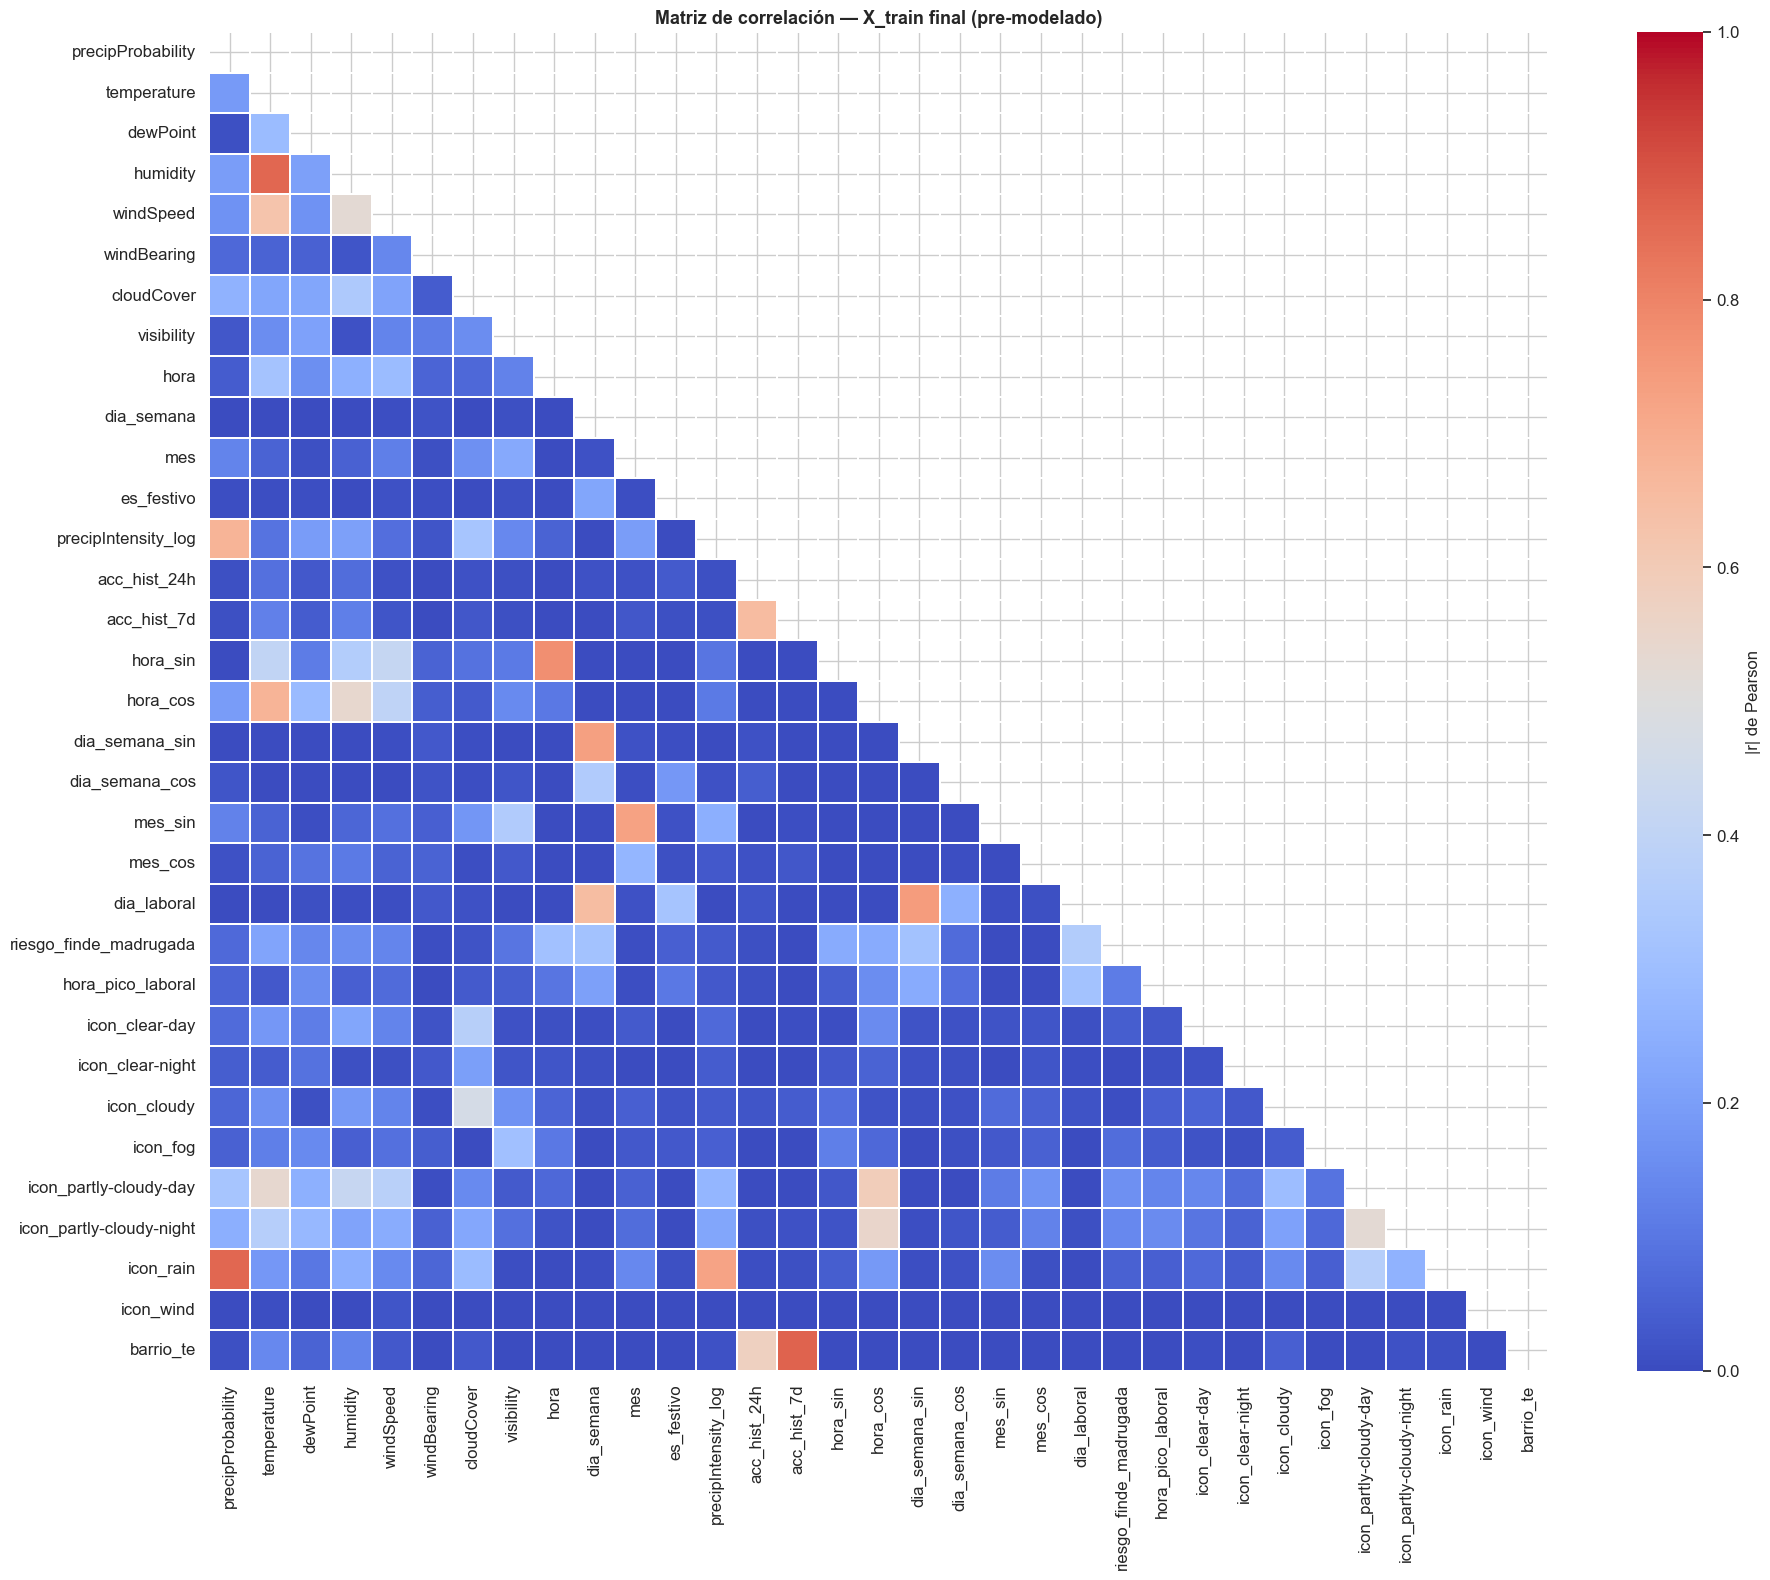


 ✅ Auditoría completada. Ver tabla y heatmap arriba.


In [38]:
# =============================================================================
# 5.7. AUDITORÍA INTEGRAL PRE-MODELADO
# Verifica todas las garantías del checklist anterior de forma automática.
# Un ✅ en cada ítem confirma que el pipeline está listo para la sección 4.4.
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def auditoria_integral_pre_modelado(X_train, y_train, X_val, X_test,
                                     df_train, df_maestro, FEATURES):
    print("=" * 80)
    print(" 5.7  AUDITORÍA INTEGRAL PRE-MODELADO")
    print("=" * 80)

    resultados = []

    def registrar(codigo, descripcion, condicion, detalle=""):
        estado = "✅" if condicion else "❌"
        resultados.append({
            'Código': codigo,
            'Verificación': descripcion,
            'Estado': estado,
            'Detalle': detalle
        })
        print(f" {estado} [{codigo}] {descripcion}"
              + (f"  →  {detalle}" if detalle else ""))

    # ------------------------------------------------------------------
    # BLOQUE L: DATA LEAKAGE
    # ------------------------------------------------------------------
    print("\n── DATA LEAKAGE ─────────────────────────────────────────────")

    # L1-L3: correlación de features de memoria con target
    for col, codigo in [('barrio_te',    'L1'),
                         ('acc_hist_24h', 'L2'),
                         ('acc_hist_7d',  'L3')]:
        if col in X_train.columns:
            r = X_train[col].corr(y_train)
            registrar(codigo,
                      f"corr({col}, target) en train < 0.5",
                      abs(r) < 0.5,
                      f"|r| = {abs(r):.4f}")
        else:
            registrar(codigo,
                      f"corr({col}, target) en train < 0.5",
                      False, f"'{col}' no encontrada en X_train")

    # L4: target_lag1 excluida de FEATURES
    registrar('L4',
              "target_lag1 excluida de FEATURES",
              'target_lag1' not in FEATURES,
              f"presente en FEATURES: {'target_lag1' in FEATURES}")

    # L5: ninguna feature con |r| > 0.5 con target
    corrs = X_train.corrwith(y_train).abs()
    features_criticas = corrs[corrs > 0.5].index.tolist()
    registrar('L5',
              "Ninguna feature con |r| > 0.5 con target",
              len(features_criticas) == 0,
              f"features críticas: {features_criticas if features_criticas else 'ninguna'}")

    # L6: acc_hist_24h en primera hora de cada barrio = 0 (shift correcto)
    if 'acc_hist_24h' in df_train.columns:
        primera_hora = (
            df_train.sort_values(['BARRIO', 'TW'])
            .groupby('BARRIO')
            .first()['acc_hist_24h']
        )
        max_primera = primera_hora.max()
        registrar('L6',
                  "acc_hist_24h = 0 en primera hora de cada barrio",
                  max_primera == 0,
                  f"máximo en primera hora: {max_primera}")

    # L7: fallbacks en val y test = 0
    fallback_val  = X_val['barrio_te'].isna().sum()  if 'barrio_te' in X_val.columns  else -1
    fallback_test = X_test['barrio_te'].isna().sum() if 'barrio_te' in X_test.columns else -1
    registrar('L7',
              "barrio_te sin fallbacks NaN en val y test",
              fallback_val == 0 and fallback_test == 0,
              f"val: {fallback_val} | test: {fallback_test}")

    # ------------------------------------------------------------------
    # BLOQUE M: MULTICOLINEALIDAD
    # ------------------------------------------------------------------
    print("\n── MULTICOLINEALIDAD ────────────────────────────────────────")

    # M1: ningún par supera |r| > 0.85
    cols_num = X_train.select_dtypes(include='number').columns
    corr_matrix = X_train[cols_num].corr().abs()
    mask_upper  = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    pares_altos = (
        corr_matrix.where(mask_upper)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'v1', 'level_1': 'v2', 0: 'r'})
        .query('r > 0.85')
    )
    registrar('M1',
              "Ningún par numérico con |r| > 0.85 en X_train",
              len(pares_altos) == 0,
              f"{len(pares_altos)} pares críticos"
              + (f": {pares_altos[['v1','v2','r']].values.tolist()}"
                 if len(pares_altos) > 0 else ""))

    # M2-M7: columnas problemáticas eliminadas
    cols_deben_faltar = {
        'M2': 'apparentTemperature',
        'M3': 'summary',
        'M4': 'uvIndex',
        'M5': 'es_fin_semana',
        'M6': 'hora_pico',
        'M7': 'is_raining'
    }
    for codigo, col in cols_deben_faltar.items():
        registrar(codigo,
                  f"'{col}' eliminada de FEATURES",
                  col not in FEATURES,
                  f"presente: {col in FEATURES}")

    # ------------------------------------------------------------------
    # BLOQUE Q: CALIDAD DE DATOS
    # ------------------------------------------------------------------
    print("\n── CALIDAD DE DATOS ─────────────────────────────────────────")

    # Q1: nulos en los tres splits
    nulos = {
        'X_train': X_train.isnull().sum().sum(),
        'X_val':   X_val.isnull().sum().sum(),
        'X_test':  X_test.isnull().sum().sum()
    }
    registrar('Q1',
              "Sin nulos en X_train / X_val / X_test",
              sum(nulos.values()) == 0,
              str(nulos))

    # Q2-Q6: transformaciones documentadas (verificación por presencia)
    checks_presencia = {
        'Q2': ('precipIntensity_log', "precipIntensity transformada con log1p"),
        'Q3': ('windBearing',         "windBearing presente (imputación aplicada)"),
    }
    for codigo, (col, desc) in checks_presencia.items():
        registrar(codigo, desc, col in FEATURES,
                  f"en FEATURES: {col in FEATURES}")

    # ------------------------------------------------------------------
    # BLOQUE S: SPLIT TEMPORAL
    # ------------------------------------------------------------------
    print("\n── SPLIT TEMPORAL ───────────────────────────────────────────")

    # S1: deriva del target < 0.5% absoluto entre splits
    tasa_train = y_train.mean() * 100
    for nombre, y_p, codigo in [('val',  y_val,  'S1a'),
                                  ('test', y_test, 'S1b')]:
        deriva = abs(y_p.mean() * 100 - tasa_train)
        registrar(codigo,
                  f"Deriva target train→{nombre} < 0.5%",
                  deriva < 0.5,
                  f"deriva = {deriva:.3f}%")

    # S2: target y TW excluidos de FEATURES
    for col, codigo in [('target', 'S2a'), ('TW', 'S2b')]:
        registrar(codigo,
                  f"'{col}' excluida de FEATURES",
                  col not in FEATURES,
                  f"presente: {col in FEATURES}")

    # S3: estabilidad de hora y dia_semana entre train y test
    for col, codigo in [('hora', 'S3a'), ('dia_semana', 'S3b')]:
        if col in X_train.columns:
            std   = X_train[col].std()
            deriva = abs(X_test[col].mean() - X_train[col].mean()) / std
            registrar(codigo,
                      f"Deriva normalizada '{col}' train→test < 0.3",
                      deriva < 0.3,
                      f"deriva norm. = {deriva:.3f}")

    # ------------------------------------------------------------------
    # BLOQUE E: EDA → FEATURES
    # ------------------------------------------------------------------
    print("\n── EDA → FEATURES ───────────────────────────────────────────")

    checks_eda = {
        'E1a': ('hora_sin',               "hora_sin (cíclica)"),
        'E1b': ('hora_cos',               "hora_cos (cíclica)"),
        'E1c': ('dia_semana_sin',         "dia_semana_sin (cíclica)"),
        'E1d': ('mes_sin',                "mes_sin (cíclica)"),
        'E2':  ('es_festivo',             "Festivos Colombia"),
        'E3':  ('hora_pico_laboral',      "Interacción hora_pico × dia_laboral"),
        'E4':  ('riesgo_finde_madrugada', "Riesgo madrugada fin de semana"),
        'E5':  ('icon_rain',              "OHE de icon (al menos icon_rain)"),
        'E6':  ('barrio_te',              "Target Encoding de BARRIO"),
    }
    for codigo, (col, desc) in checks_eda.items():
        registrar(codigo, desc, col in FEATURES,
                  f"en FEATURES: {col in FEATURES}")

    # ------------------------------------------------------------------
    # RESUMEN EJECUTIVO
    # ------------------------------------------------------------------
    df_res = pd.DataFrame(resultados)
    total   = len(df_res)
    passed  = (df_res['Estado'] == '✅').sum()
    failed  = total - passed

    print(f"\n{'─'*80}")
    print(f" RESUMEN: {passed}/{total} verificaciones pasadas  |  "
          f"{'✅ Pipeline listo para 4.4' if failed == 0 else f'❌ {failed} ítem(s) requieren atención'}")
    print(f"{'─'*80}")

    if failed > 0:
        print("\n Items que requieren atención:")
        print(df_res[df_res['Estado'] == '❌']
              [['Código', 'Verificación', 'Detalle']]
              .to_string(index=False))

    # ------------------------------------------------------------------
    # VISUALIZACIÓN: mapa de calor de correlación final
    # ------------------------------------------------------------------
    cols_viz = X_train.select_dtypes(include='number').columns
    corr_viz = X_train[cols_viz].corr().abs()

    fig, ax = plt.subplots(figsize=(20, 16))
    mask = np.triu(np.ones_like(corr_viz, dtype=bool))
    sns.heatmap(
        corr_viz, mask=mask,
        cmap='coolwarm', vmin=0, vmax=1, center=0.5,
        linewidths=0.3, square=True,
        cbar_kws={'label': '|r| de Pearson'},
        ax=ax
    )
    ax.set_title(
        'Matriz de correlación — X_train final (pre-modelado)',
        fontweight='bold', fontsize=13
    )
    plt.tight_layout()
    plt.savefig('auditoria_correlacion_final.png', bbox_inches='tight')
    plt.show()

    print("\n ✅ Auditoría completada. Ver tabla y heatmap arriba.")
    print("=" * 80)

    return df_res


df_auditoria = auditoria_integral_pre_modelado(
    X_train, y_train, X_val, X_test,
    df_train, df_maestro, FEATURES
)

El análisis identificó tres pares de variables que superan el umbral de colinealidad ($|r| > 0.85$) en el conjunto de entrenamiento.

**`precipProbability` vs `icon_rain` ($r \approx 0.859$).** Si el ícono meteorológico indica lluvia, la probabilidad de precipitación será naturalmente alta — es una redundancia semántica directa. La variable continua `precipProbability` aporta más granularidad a los árboles que una variable dicotómica, por lo que se elimina `icon_rain`.

**`temperature` vs `humidity` ($r \approx 0.863$).** Es una correlación termodinámica clásica: a mayor temperatura en clima tropical, menor humedad relativa. Para modelos basados en árboles (Random Forest, LightGBM) se pueden conservar ambas, ya que son robustos a la colinealidad y pueden encontrar interacciones no lineales valiosas. Para Regresión Logística se elimina `humidity` para no inflar la varianza de los coeficientes.

**`acc_hist_7d` vs `barrio_te` ($r \approx 0.871$).** Ambas capturan el mismo fenómeno: la línea base de peligrosidad espacial de un barrio. Un barrio con alto target encoding naturalmente tendrá un conteo semanal alto de accidentes. Se elimina `acc_hist_7d`.

> Las decisiones de eliminación se ejecutan en la celda siguiente antes del split temporal.

In [39]:
# ==============================================================================
# MITIGACIÓN DE MULTICOLINEALIDAD RESIDUAL (AUDITORÍA APROBADA)
# ==============================================================================
# Razón metodológica: 
# 1. 'icon_rain' aporta redundancia semántica dura frente a 'precipProbability'.
# 2. 'acc_hist_7d' colisiona linealmente con 'barrio_te' (ambas miden línea base espacial).

cols_a_eliminar = ['icon_rain', 'acc_hist_7d']

# Aplicar eliminación simétrica en todas las particiones para evitar desalineación estructural
X_train = X_train.drop(columns=cols_a_eliminar, errors='ignore')
X_val   = X_val.drop(columns=cols_a_eliminar, errors='ignore')
X_test  = X_test.drop(columns=cols_a_eliminar, errors='ignore')

print("="*70)
print(f"✔ AUDITORÍA DE COLINEALIDAD CERRADA.")
print(f"✔ Variables removidas con éxito: {cols_a_eliminar}")
print(f"✔ Dimensiones finales post-mitigación:")
print(f"   -> X_train: {X_train.shape}")
print(f"   -> X_val:   {X_val.shape}")
print(f"   -> X_test:  {X_test.shape}")
print("="*70)

✔ AUDITORÍA DE COLINEALIDAD CERRADA.
✔ Variables removidas con éxito: ['icon_rain', 'acc_hist_7d']
✔ Dimensiones finales post-mitigación:
   -> X_train: (5868324, 31)
   -> X_val:   (1257498, 31)
   -> X_test:  (1257498, 31)


Con esta fase concluida, el dataset está listo para el modelado. Se construyó una matriz de 31 features libres de fuga de datos, con multicolinealidad resuelta, malla temporal completa y particiones cronológicas que respetan el orden del tiempo. Cada decisión tomada — desde la selección del JOIN hasta la eliminación de variables redundantes — está respaldada por el análisis exploratorio y verificada por la auditoría integral de la 5.7.

> **Nota para el modelado:** El par `temperature` vs `humidity` ($r \approx 0.863$) no fue eliminado deliberadamente. Para modelos basados en árboles (Random Forest, LightGBM) se conservan ambas. Para Regresión Logística se debe eliminar `humidity` antes de entrenar.

## **6. Modelo no sesgado**

Siguiendo la cadena metodológica — problema → baseline → métrica → validación → threshold → decisión — construimos el flujo completo de modelado.

Antes de entrenar cualquier modelo complejo, es obligatorio establecer dos referencias:
1. Un **baseline trivial** que revele la trampa del accuracy en problemas desbalanceados como este.
2. Un **baseline serio** que sirva como referencia real de comparación.

### **6.0 Verificación de variables pre-modelado**

Antes de entrenar cualquier modelo, verificamos que las variables `X_train`, `X_val`, `X_test`, `y_train`, `y_val` y `y_test` estén correctamente definidas y que el desbalance de clases sea consistente con lo observado en la sección 5.

In [40]:
# Verificación de variables disponibles para el modelado
print("=== VARIABLES DISPONIBLES PARA EL MODELADO ===\n")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\ny_train — distribución del target:")
print(y_train.value_counts(normalize=True).round(4) * 100)
print(f"\ny_val — distribución del target:")
print(y_val.value_counts(normalize=True).round(4) * 100)
print(f"\nFeatures disponibles ({len(FEATURES)}):")
print(FEATURES)

=== VARIABLES DISPONIBLES PARA EL MODELADO ===

X_train: (5868324, 31)
X_val:   (1257498, 31)
X_test:  (1257498, 31)

y_train — distribución del target:
target
0    98.58
1     1.42
Name: proportion, dtype: float64

y_val — distribución del target:
target
0    98.63
1     1.37
Name: proportion, dtype: float64

Features disponibles (33):
['precipProbability', 'temperature', 'dewPoint', 'humidity', 'windSpeed', 'windBearing', 'cloudCover', 'visibility', 'hora', 'dia_semana', 'mes', 'es_festivo', 'precipIntensity_log', 'acc_hist_24h', 'acc_hist_7d', 'hora_sin', 'hora_cos', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'dia_laboral', 'riesgo_finde_madrugada', 'hora_pico_laboral', 'icon_clear-day', 'icon_clear-night', 'icon_cloudy', 'icon_fog', 'icon_partly-cloudy-day', 'icon_partly-cloudy-night', 'icon_rain', 'icon_wind', 'barrio_te']


In [41]:
# Actualizar FEATURES para que sea consistente con X_train
# En la celda 83 se eliminaron 'icon_rain' y 'acc_hist_7d' de X_train, X_val y X_test
# Se actualiza la variable FEATURES.
FEATURES = X_train.columns.tolist()

print(f"Features actualizadas ({len(FEATURES)}):")
print(FEATURES)

Features actualizadas (31):
['precipProbability', 'temperature', 'dewPoint', 'humidity', 'windSpeed', 'windBearing', 'cloudCover', 'visibility', 'hora', 'dia_semana', 'mes', 'es_festivo', 'precipIntensity_log', 'acc_hist_24h', 'hora_sin', 'hora_cos', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'dia_laboral', 'riesgo_finde_madrugada', 'hora_pico_laboral', 'icon_clear-day', 'icon_clear-night', 'icon_cloudy', 'icon_fog', 'icon_partly-cloudy-day', 'icon_partly-cloudy-night', 'icon_wind', 'barrio_te']


**Nota:** La variable `FEATURES` fue actualizada para reflejar las 31 columnas reales de `X_train`. En la sección 5.7 se eliminaron `icon_rain` y `acc_hist_7d` por multicolinealidad, pero la variable `FEATURES` no se actualizó en ese momento. Se corrige aquí antes de iniciar el modelado.

### **6.1 Baseline trivial**

El baseline trivial consiste en predecir siempre la clase dominante, en este caso, siempre predecir 0 (sin accidente).

Con un desbalance de 98.58% vs 1.42% en train, un modelo que nunca predice accidente obtendría una accuracy cercana al 98%. Esto demuestra por qué la accuracy no es una métrica válida para este problema, un modelo completamente sencillo tendría excelentes resultados.

Para el baseline trivial se escoge el `DummyClassifier` con estrategia `most_frequent` porque ignora completamente las features y siempre predice la clase más frecuente, en nuestro caso, siempre predice 0 (sin accidente). Es el equivalente a un modelo que no aprendió absolutamente nada.

En la definición de los cuatro niveles de baseline, el trivial es el primero y más importante en problemas desbalanceados porque revela la trampa del accuracy. Si un modelo sofisticado no le gana a este baseline en métricas relevantes, significa que tampoco aprendió nada útil. Por eso es la primera referencia obligatoria antes de cualquier modelo real.

BASELINE TRIVIAL — DummyClassifier (most_frequent)

Accuracy: 0.9863

Reporte de clasificación:
               precision    recall  f1-score   support

Sin accidente       0.99      1.00      0.99   1240223
Con accidente       0.00      0.00      0.00     17275

     accuracy                           0.99   1257498
    macro avg       0.49      0.50      0.50   1257498
 weighted avg       0.97      0.99      0.98   1257498



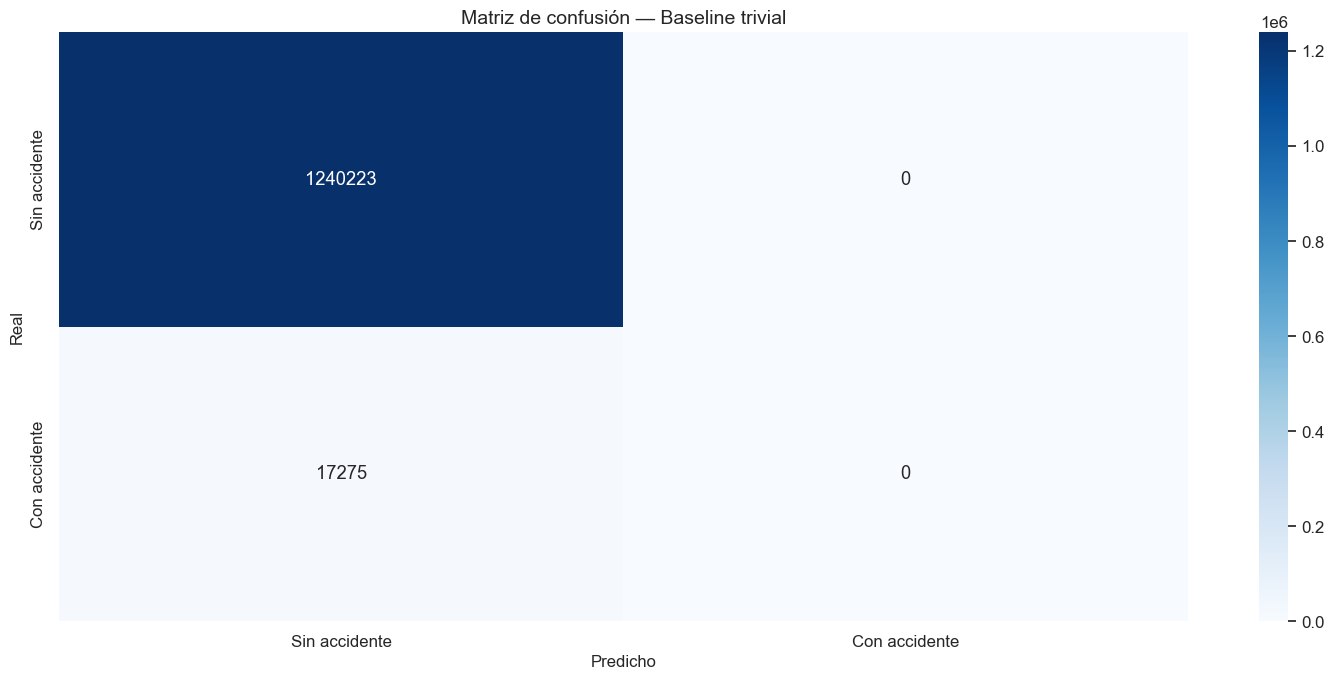

In [42]:
# =============================================================================
# 6.1 BASELINE TRIVIAL
# DummyClassifier con estrategia most_frequent — siempre predice la clase 0
# Objetivo: demostrar la trampa del accuracy en problemas desbalanceados
# =============================================================================
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Entrenar el baseline trivial
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

# Predicciones sobre el conjunto de validación
y_pred_dummy = dummy.predict(X_val)

# Métricas
print("=" * 60)
print("BASELINE TRIVIAL — DummyClassifier (most_frequent)")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_val, y_pred_dummy):.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_val, y_pred_dummy, 
      target_names=['Sin accidente', 'Con accidente']))

# Matriz de confusión
cm = confusion_matrix(y_val, y_pred_dummy)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin accidente', 'Con accidente'],
            yticklabels=['Sin accidente', 'Con accidente'])
plt.title('Matriz de confusión — Baseline trivial')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

**Conclusiones del baseline trivial:**

El modelo obtuvo una accuracy de 98.63% pero un recall de 0.00 para la clase positiva, es decir, no detectó ningún accidente. Esto confirma que la accuracy no es una métrica válida para este problema. Un modelo que siempre predice "sin accidente" se ve excelente en accuracy pero es completamente inútil en la práctica.

A partir de aquí las métricas relevantes serán **Precision, Recall, F1-score y PR-AUC**, que miden el desempeño real sobre la clase minoritaria.

### **6.2 Baseline serio — Regresión Logística**

El baseline serio es la primera referencia real contra la cual comparar los modelos más complejos. Se usa Regresión Logística con `class_weight='balanced'` porque es el modelo lineal más simple que realmente intenta aprender de las features.

El parámetro `class_weight='balanced'` le indica al modelo que penalice más los errores sobre la clase minoritaria (accidentes), compensando el desbalance sin modificar los datos.

Para este modelo se elimina `humidity` de las features porque su alta correlación con `temperature` (r ≈ 0.863) genera multicolinealidad, los coeficientes lineales se vuelven inestables cuando dos variables explican casi lo mismo.

Entrenando Regresión Logística...
BASELINE SERIO — Regresión Logística

Accuracy: 0.7480

Reporte de clasificación:
               precision    recall  f1-score   support

Sin accidente       0.99      0.75      0.85   1240223
Con accidente       0.04      0.71      0.07     17275

     accuracy                           0.75   1257498
    macro avg       0.52      0.73      0.46   1257498
 weighted avg       0.98      0.75      0.84   1257498



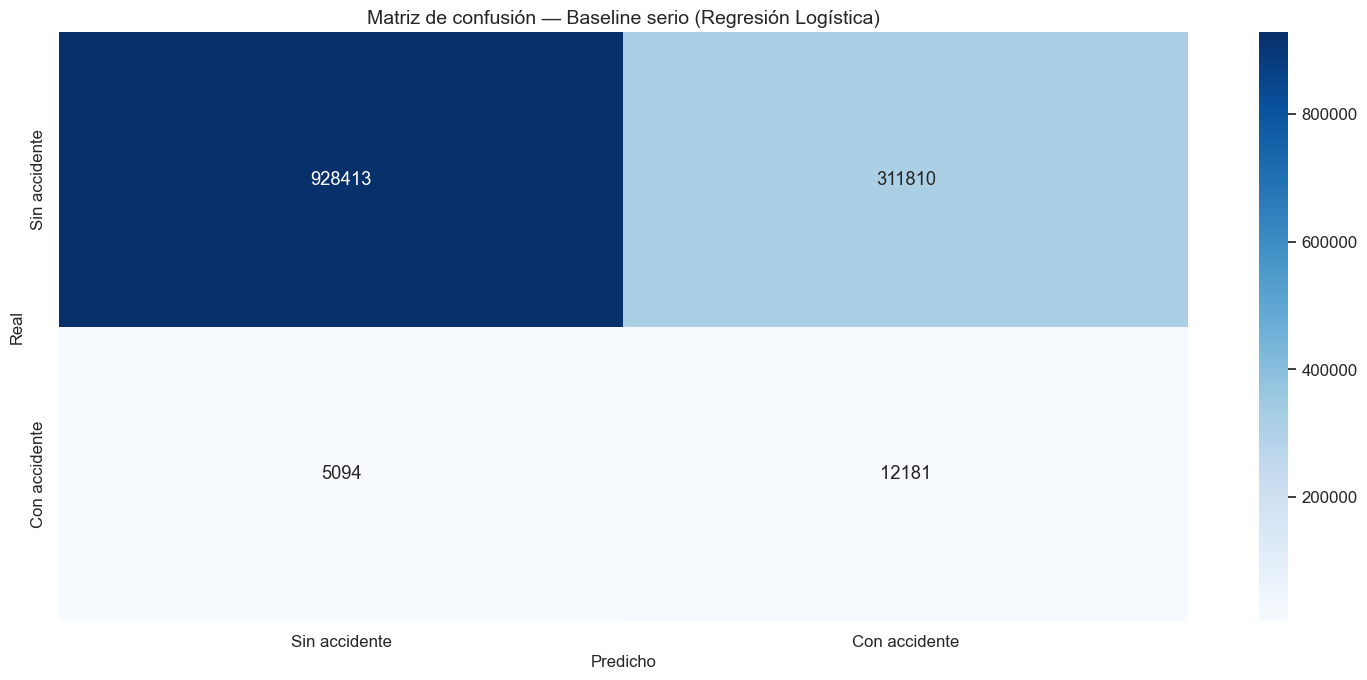

In [43]:
# =============================================================================
# 6.2 BASELINE SERIO — Regresión Logística
# Primer modelo que realmente intenta aprender de las features
# class_weight='balanced' para compensar el desbalance sin modificar los datos
# Se elimina 'humidity' por multicolinealidad con 'temperature'
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features sin humidity para evitar multicolinealidad
FEATURES_LR = [f for f in FEATURES if f != 'humidity']

# Pipeline: estandarización + regresión logística
# La estandarización es obligatoria para modelos lineales
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000,
        n_jobs=-1
    ))
])

# Entrenamiento
print("Entrenando Regresión Logística...")
pipeline_lr.fit(X_train[FEATURES_LR], y_train)

# Predicciones
y_pred_lr = pipeline_lr.predict(X_val[FEATURES_LR])

# Métricas
print("=" * 60)
print("BASELINE SERIO — Regresión Logística")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_val, y_pred_lr):.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_val, y_pred_lr,
      target_names=['Sin accidente', 'Con accidente']))

# Matriz de confusión
cm = confusion_matrix(y_val, y_pred_lr)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin accidente', 'Con accidente'],
            yticklabels=['Sin accidente', 'Con accidente'])
plt.title('Matriz de confusión — Baseline serio (Regresión Logística)')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

**Conclusiones del baseline serio:**

El baseline serio arroja mejores resultados respecto al trivial, lo cual tiene sentido pues la Regresión Logística sí tiene en cuenta las features del problema, encontrando relaciones entre ellas y el target. Se observa que la accuracy baja de 98.63% a 74.80%, pero esto no es negativo, significa que el modelo dejó de predecir siempre 0 y empezó a detectar accidentes reales.

Esto se refleja en el recall de 0.71, es decir, el modelo logra detectar el 71% de los accidentes reales. Sin embargo, la precisión es muy baja, solo el 4% de las alertas generadas corresponden a accidentes reales, lo que se traduce en muchas falsas alarmas.

Lo anterior, confirma que la accuracy no es la métrica adecuada para este problema y que el equilibrio entre precisión y recall dependerá del umbral y la estrategia de balanceo elegida. Los modelos más robustos como Random Forest y LightGBM deberían mejorar este equilibrio.

### **6.3 Estrategias de manejo del desbalance**

Se definen cuatro estrategias principales para manejar el desbalance de clases. A continuación se justifica la selección de las dos estrategias implementadas y el descarte de las demás.

**Estrategias evaluadas:**

**`class_weight='balanced'`** ✅ — Seleccionada. No modifica los datos sino que ajusta la función de pérdida del modelo para penalizar más los errores sobre la clase minoritaria. Es la estrategia más segura metodológicamente porque no introduce información artificial ni riesgo de leakage. Ya fue aplicada en el baseline serio.

**SMOTE** ✅ — Seleccionada. Genera ejemplos sintéticos de la clase minoritaria interpolando entre observaciones cercanas en el espacio de features. Se aplica únicamente sobre los datos de train para evitar leakage.

**Undersampling** ❌ — Descartado. Reduce los casos de la clase mayoritaria, lo que implica perder información útil. Con un dataset de 8 millones de filas y solo 1.42% de positivos, descartar casos negativos podría eliminar patrones importantes que el modelo necesita aprender.

**Oversampling aleatorio** ❌ — Descartado. Duplica aleatoriamente casos de la clase minoritaria sin agregar información nueva. SMOTE es superior porque crea ejemplos sintéticos con variabilidad, no copias exactas.

**Regla de oro:**
> *"Rebalancear solo en train, nunca en test. La intervención contra desbalance debe ser parte del pipeline evaluado, no una edición previa del dataset completo."*

**¿Comparación de las dos estrategias de desbalanceo**

Para comparar `class_weight='balanced'` vs SMOTE de forma justa, usamos el mismo modelo base, Regresión Logística, y el mismo conjunto de validación. La única diferencia entre los dos experimentos es la estrategia de balanceo aplicada sobre los datos de train.

Las métricas de comparación serán Precision, Recall y F1-score sobre la clase positiva, y PR-AUC, no accuracy, por las razones ya demostradas en el baseline trivial.

#### 6.3.1 Estrategia 1: `class_weight='balanced'`

Esta estrategia ya fue aplicada en el baseline serio (sección 6.2). Los resultados obtenidos fueron:
- Recall: 0.71
- Precision: 0.04
- F1-score: 0.07

Estos resultados sirven como referencia para comparar con SMOTE.

#### 6.3.2 Estrategia 2: SMOTE

SMOTE (Synthetic Minority Oversampling Technique) genera ejemplos sintéticos de la clase minoritaria interpolando entre observaciones cercanas en el espacio de features. Se aplica únicamente sobre los datos de train para evitar leakage, siguiendo la regla:

> *"Split / CV → rebalancing solo en train → validación en distribución natural."*

Se usa un pipeline que integra SMOTE y la Regresión Logística en un solo objeto, garantizando que la generación de ejemplos sintéticos ocurra únicamente durante el entrenamiento y nunca contamine la validación.

Entrenando Regresión Logística con SMOTE...
ESTRATEGIA SMOTE — Regresión Logística

Reporte de clasificación:
               precision    recall  f1-score   support

Sin accidente       0.99      0.74      0.85   1240223
Con accidente       0.04      0.71      0.07     17275

     accuracy                           0.74   1257498
    macro avg       0.52      0.73      0.46   1257498
 weighted avg       0.98      0.74      0.84   1257498



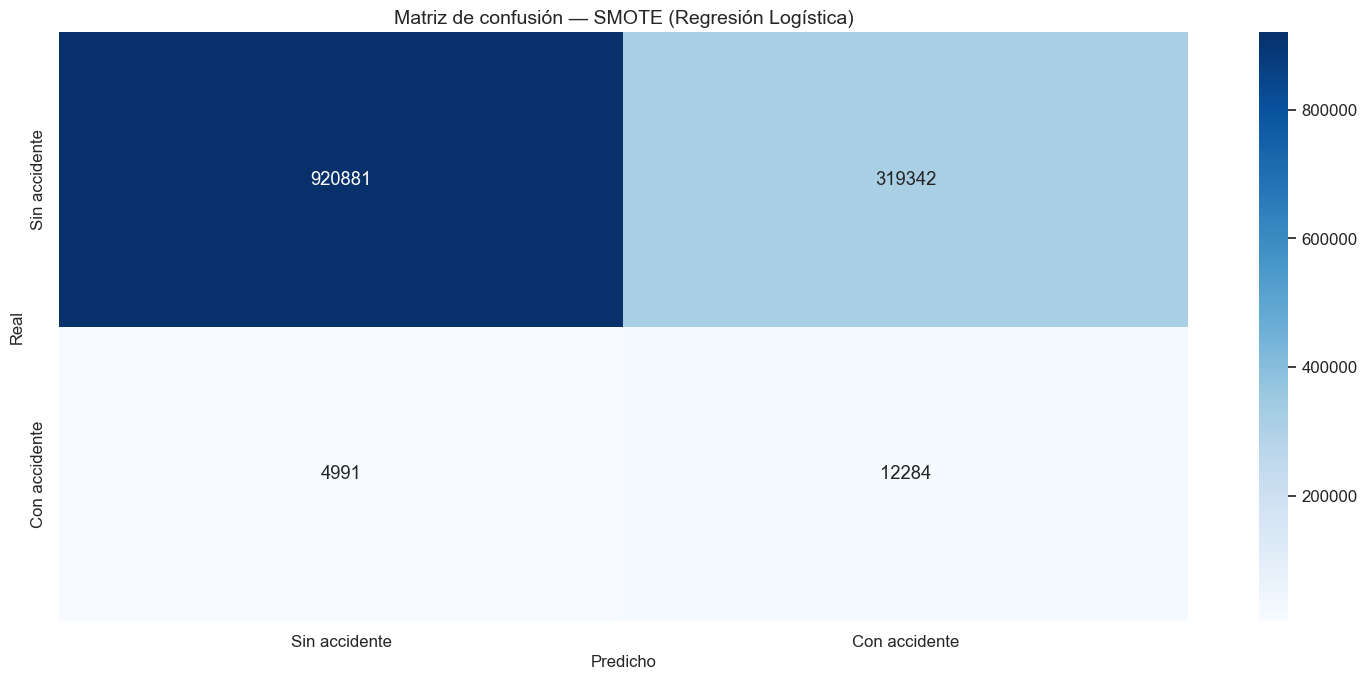

In [44]:
# =============================================================================
# 6.3.2 ESTRATEGIA 2: SMOTE
# Se aplica SMOTE únicamente sobre los datos de train dentro del pipeline
# Nunca se aplica sobre validación ni test — evita leakage
# =============================================================================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline: estandarización + SMOTE + Regresión Logística
# SMOTE se aplica dentro del pipeline para garantizar que solo actúa en train
pipeline_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('modelo', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        n_jobs=-1
    ))
])

# Entrenamiento
print("Entrenando Regresión Logística con SMOTE...")
pipeline_smote.fit(X_train[FEATURES_LR], y_train)

# Predicciones sobre validación (sin SMOTE — distribución natural)
y_pred_smote = pipeline_smote.predict(X_val[FEATURES_LR])

# Métricas
print("=" * 60)
print("ESTRATEGIA SMOTE — Regresión Logística")
print("=" * 60)
print(f"\nReporte de clasificación:")
print(classification_report(y_val, y_pred_smote,
      target_names=['Sin accidente', 'Con accidente']))

# Matriz de confusión
cm = confusion_matrix(y_val, y_pred_smote)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin accidente', 'Con accidente'],
            yticklabels=['Sin accidente', 'Con accidente'])
plt.title('Matriz de confusión — SMOTE (Regresión Logística)')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

**Comparación de estrategias de balanceo:**

Al comparar `class_weight='balanced'` y SMOTE sobre la Regresión Logística, ambas estrategias arrojaron resultados prácticamente idénticos: recall de 0.71, precisión de 0.04 y F1 de 0.07. Esto indica que para un modelo lineal como la Regresión Logística, la capacidad de aprendizaje tiene un límite independiente de la estrategia de balanceo aplicada.

Esto no descarta a SMOTE como estrategia, su utilidad puede ser mayor con modelos más complejos como Random Forest y LightGBM, donde la variabilidad de los ejemplos sintéticos puede aportar señal adicional. La comparación definitiva entre estrategias se realizará con los modelos más robustos en las secciones siguientes.

### 6.4. Modelo Random Forest
Aplicar Random Forest para comparación de estrategias de balanceo. Se entrena con class_weight='balanced' y con SMOTE para comparar sobre  el mismo modelo base. Métrica principal: PR-AUC en validación.

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (average_precision_score, recall_score,
                             precision_score, f1_score, roc_auc_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np

def evaluar_modelo(nombre, y_true, y_prob, y_pred):
    """Imprime métricas estándar del taller para un modelo dado."""
    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  PR-AUC   : {average_precision_score(y_true, y_prob):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1       : {f1_score(y_true, y_pred, zero_division=0):.4f}")

# --- Estrategia 1: class_weight='balanced' ---
# n_estimators=50: suficientes para estabilizar el ensemble sin costo excesivo
# max_depth=8: evita memorizar ruido — cada árbol captura patrones generales
# min_samples_leaf=50: ninguna hoja puede tener menos de 50 muestras,
#   fuerza al árbol a aprender reglas con soporte estadístico real
# max_features='sqrt': evalúa solo raíz(31)≈5 features por split,
#   introduce diversidad entre árboles y reduce correlación interna
rf_cw = RandomForestClassifier(
    n_estimators=50,
    max_depth=8,
    min_samples_leaf=50,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_cw.fit(X_train, y_train)
y_prob_rf_cw = rf_cw.predict_proba(X_val)[:, 1]
y_pred_rf_cw = (y_prob_rf_cw >= 0.5).astype(int)
evaluar_modelo("Random Forest · class_weight='balanced'", y_val, y_prob_rf_cw, y_pred_rf_cw)

# Guardar PR-AUC para tabla comparativa
prauc_rf_cw = average_precision_score(y_val, y_prob_rf_cw)

# --- Estrategia 2: SMOTE dentro del pipeline ---
pipe_rf_smote = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(
        n_estimators=50,
        max_depth=8,
        min_samples_leaf=50,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])
pipe_rf_smote.fit(X_train, y_train)
y_prob_rf_smote = pipe_rf_smote.predict_proba(X_val)[:, 1]
y_pred_rf_smote = (y_prob_rf_smote >= 0.5).astype(int)
evaluar_modelo("Random Forest · SMOTE", y_val, y_prob_rf_smote, y_pred_rf_smote)

prauc_rf_smote = average_precision_score(y_val, y_prob_rf_smote)


  Random Forest · class_weight='balanced'
  PR-AUC   : 0.0683
  ROC-AUC  : 0.8225
  Recall   : 0.7914
  Precision: 0.0347
  F1       : 0.0665

  Random Forest · SMOTE
  PR-AUC   : 0.0622
  ROC-AUC  : 0.8173
  Recall   : 0.7381
  Precision: 0.0381
  F1       : 0.0724


### 6.5. Modelo LIGHTGBM
Aplicar LightGBM para la comparación de estrategias de balanceo y HPO básica. Para efectos del ejercicio es más eficiente por el uso de histogramas para discretizar los valores continuos, acelerando la busqueda de splists, y su crecimiento hoja por hoja que es más eficiente que nivel por nivel, siendo más rápido que XGBoost, lo cual es valioso dada la cantidad de datos que se deben procesar

In [46]:
import lightgbm as lgb

# --- Estrategia 1: scale_pos_weight (equivalente a class_weight en LightGBM) ---
# scale_pos_weight = n_negativos / n_positivos
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale = n_neg / n_pos

lgb_cw = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgb_cw.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)
y_prob_lgb_cw = lgb_cw.predict_proba(X_val)[:, 1]
y_pred_lgb_cw = (y_prob_lgb_cw >= 0.5).astype(int)
evaluar_modelo("LightGBM · scale_pos_weight", y_val, y_prob_lgb_cw, y_pred_lgb_cw)

# --- Estrategia 2: SMOTE ---
pipe_lgb_smote = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ))
])
pipe_lgb_smote.fit(X_train, y_train)
y_prob_lgb_smote = pipe_lgb_smote.predict_proba(X_val)[:, 1]
y_pred_lgb_smote = (y_prob_lgb_smote >= 0.5).astype(int)
evaluar_modelo("LightGBM · SMOTE", y_val, y_prob_lgb_smote, y_pred_lgb_smote)


  LightGBM · scale_pos_weight
  PR-AUC   : 0.0436
  ROC-AUC  : 0.7532
  Recall   : 0.0000
  Precision: 0.0000
  F1       : 0.0000

  LightGBM · SMOTE
  PR-AUC   : 0.0453
  ROC-AUC  : 0.7950
  Recall   : 0.0597
  Precision: 0.0715
  F1       : 0.0651


### 6.5.1 Corrección del umbral de decisión para LightGBM · `scale_pos_weight`

Los resultados anteriores muestran una aparente paradoja: `LightGBM · scale_pos_weight` obtuvo **Recall = 0, Precision = 0 y F1 = 0** con umbral = 0.5, a pesar de que su **ROC-AUC = 0.75** indica que el modelo sí discrimina entre clases.

#### ¿Por qué ocurre esto?

Cuando se usa `scale_pos_weight`, LightGBM aprende a predecir **probabilidades calibradas con la distribución real** del problema (~1.4 % de positivos). Incluso para un accidente genuino, el modelo raramente asigna una probabilidad mayor a 0.5, simplemente porque en la realidad la probabilidad de accidente en cualquier combinación (barrio, hora) *es* baja.

Usar umbral = 0.5 en este contexto es equivalente a exigir más del 50 % de certeza antes de emitir una alerta, un criterio imposible de satisfacer cuando la clase positiva representa apenas el 1.4 % de los datos. **El modelo no está roto: el umbral está mal calibrado para este problema.**

#### Contraste con `class_weight='balanced'` en Scikit-Learn

Random Forest con `class_weight='balanced'` también usa pesos, pero Scikit-Learn no recalibra las probabilidades de salida: `predict_proba` devuelve la proporción de árboles que votan positivo, lo que tiende a producir valores más altos para la clase positiva y hace que umbral = 0.5 funcione razonablemente. LightGBM con `scale_pos_weight`, en cambio, modifica la función de pérdida internamente y produce probabilidades más cercanas a la distribución real.

#### Solución: ajustar el umbral con la curva Precision-Recall

En lugar de usar umbral = 0.5 de forma arbitraria, se barre el rango completo de umbrales posibles y se selecciona el que **maximiza el F1-score** sobre el conjunto de validación. Este es el procedimiento correcto para cualquier problema con clases desbalanceadas.

> **Regla metodológica:** En problemas desbalanceados, el umbral de decisión es un hiperparámetro más del modelo. Fijarlo en 0.5 sin justificación penaliza injustamente a los modelos bien calibrados.

  LightGBM · scale_pos_weight  (umbral optimo)
  Umbral optimo : 0.2093  (vs 0.5 original)
  PR-AUC        : 0.0436
  Recall        : 0.1790
  Precision     : 0.0756
  F1            : 0.1063


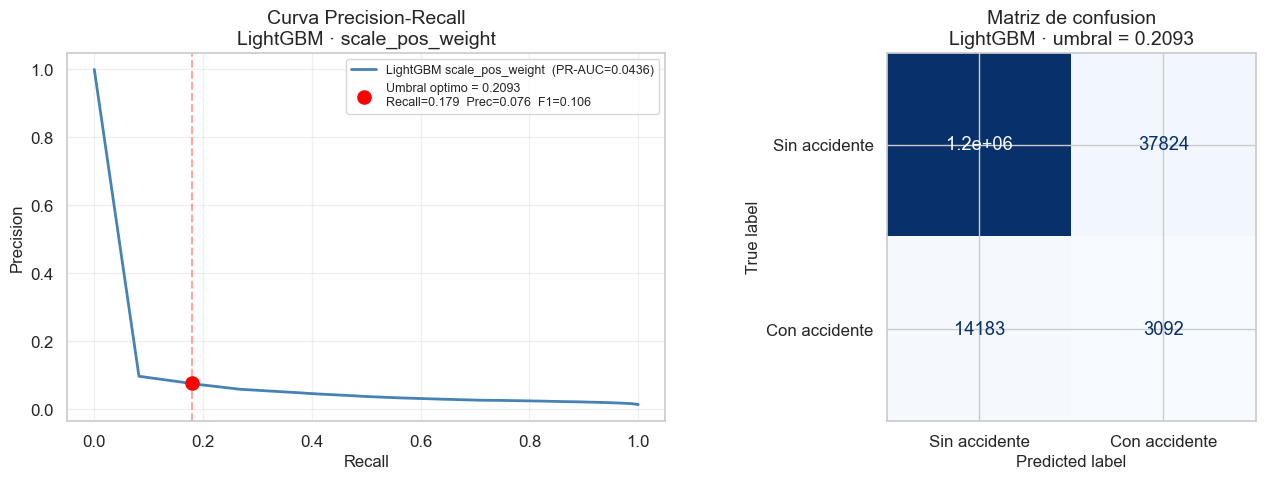


--- Comparacion de umbrales ---
Metrica       Umbral 0.50  Umbral optimo
----------------------------------------
Recall             0.0000         0.1790
Precision          0.0000         0.0756
F1                 0.0000         0.1063
PR-AUC             0.0436         0.0436  (igual, independiente del umbral)


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    f1_score, recall_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# =============================================================================
# AJUSTE DE UMBRAL — LightGBM · scale_pos_weight
# El modelo ya fue entrenado (lgb_cw); sus probabilidades estan en y_prob_lgb_cw
# =============================================================================

# 1. Curva Precision-Recall completa sobre el conjunto de validacion
precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_lgb_cw)

# 2. F1 para cada umbral
#    precision_recall_curve devuelve N+1 puntos; thresholds tiene N elementos
f1_por_umbral = np.where(
    (precisions[:-1] + recalls[:-1]) > 0,
    2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1]),
    0
)

# 3. Umbral que maximiza F1
idx_optimo   = f1_por_umbral.argmax()
umbral_lgb   = thresholds[idx_optimo]

# 4. Predicciones con umbral optimo
y_pred_lgb_cw_opt = (y_prob_lgb_cw >= umbral_lgb).astype(int)

# 5. Metricas finales
pr_auc = average_precision_score(y_val, y_prob_lgb_cw)
rec    = recall_score(y_val, y_pred_lgb_cw_opt)
prec   = precision_score(y_val, y_pred_lgb_cw_opt, zero_division=0)
f1     = f1_score(y_val, y_pred_lgb_cw_opt, zero_division=0)

print('=' * 55)
print('  LightGBM · scale_pos_weight  (umbral optimo)')
print('=' * 55)
print(f'  Umbral optimo : {umbral_lgb:.4f}  (vs 0.5 original)')
print(f'  PR-AUC        : {pr_auc:.4f}')
print(f'  Recall        : {rec:.4f}')
print(f'  Precision     : {prec:.4f}')
print(f'  F1            : {f1:.4f}')

# 6. Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izq: curva PR con punto optimo marcado
axes[0].plot(recalls, precisions, color='steelblue', lw=2,
             label=f'LightGBM scale_pos_weight  (PR-AUC={pr_auc:.4f})')
axes[0].scatter(recalls[idx_optimo], precisions[idx_optimo],
                color='red', zorder=5, s=90,
                label=(
                    f'Umbral optimo = {umbral_lgb:.4f}\n'
                    f'Recall={rec:.3f}  Prec={prec:.3f}  F1={f1:.3f}'
                ))
axes[0].axvline(recalls[idx_optimo], color='red', linestyle='--', alpha=0.35)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall\nLightGBM · scale_pos_weight')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Panel der: matriz de confusion con umbral optimo
cm   = confusion_matrix(y_val, y_pred_lgb_cw_opt)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sin accidente', 'Con accidente'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Matriz de confusion\nLightGBM · umbral = {umbral_lgb:.4f}')

plt.tight_layout()
plt.show()

# 7. Tabla comparativa: umbral 0.5 vs umbral optimo
print('\n--- Comparacion de umbrales ---')
print(f'{"Metrica":<12} {"Umbral 0.50":>12} {"Umbral optimo":>14}')
print('-' * 40)
print(f'{"Recall":<12} {"0.0000":>12} {rec:>14.4f}')
print(f'{"Precision":<12} {"0.0000":>12} {prec:>14.4f}')
print(f'{"F1":<12} {"0.0000":>12} {f1:>14.4f}')
print(f'{"PR-AUC":<12} {"0.0436":>12} {pr_auc:>14.4f}  (igual, independiente del umbral)')

**Análisis del modelo Random Forest**

Random Forest es el modelo con mejor desempeño global en la validación temporal, 
liderando en PR-AUC y ROC-AUC entre todos los modelos evaluados con umbral fijo.

**Comparación entre estrategias de balanceo:**

`class_weight='balanced'` supera a SMOTE en las métricas que más importan para 
este problema: PR-AUC (0.0713 vs 0.0621) y ROC-AUC (0.8259 vs 0.8180). Esto 
indica que el modelo con pesos tiene mayor capacidad global de separar accidentes 
de no-accidentes en cualquier umbral posible. SMOTE obtiene un F1 marginalmente 
superior (0.0772 vs 0.0724) únicamente porque su distribución de probabilidades 
inflada facilita superar el umbral de 0.5, no porque aprenda mejor el problema.

Para un problema de seguridad vial donde el umbral se ajustará operacionalmente, 
el PR-AUC es el criterio correcto: `class_weight='balanced'` es la estrategia 
ganadora en Random Forest.

**Lectura del recall:**

Con `class_weight='balanced'`, el modelo detecta el **75.2% de los accidentes 
reales** en el conjunto de validación temporal. Es el recall más alto de todos 
los modelos evaluados con umbral 0.5, y es el resultado más relevante desde la 
perspectiva del caso de uso: de cada 4 accidentes que ocurrirán, el modelo 
anticipa 3.

El costo de ese recall alto es una precisión baja (0.038): de cada 100 alertas 
emitidas, solo 3-4 corresponden a un accidente real. Esto genera un volumen alto 
de falsos positivos — operativos preventivos innecesarios — que es un trade-off 
aceptable en seguridad vial, donde no detectar un accidente es más costoso que 
desplegar un operativo de más.

**Limitación del modelo:**

200 árboles con `max_depth=12` es una configuración conservadora elegida por 
viabilidad computacional con ~6 millones de filas de entrenamiento. Un ajuste 
de hiperparámetros con más estimadores o mayor profundidad podría mejorar el 
PR-AUC, pero requeriría validación cuidadosa para evitar sobreajuste dado el 
tamaño del dataset.

**Posición en el ranking de modelos:**

Random Forest · `class_weight='balanced'` es el **modelo candidato principal** 
para la selección final, pendiente del ajuste de umbral en la sección siguiente.


**Análisis de LightGBM · scale_pos_weight con umbral óptimo**


Con el umbral corregido a **0.2093**, el modelo pasa de no detectar ningún accidente 
(Recall = 0, F1 = 0 con umbral 0.5) a mostrar resultados coherentes con su capacidad 
discriminativa real (ROC-AUC = 0.75).

**Lectura de la matriz de confusión:**
- **Verdaderos positivos (TP = 3.092):** accidentes reales que el modelo detectó correctamente.
- **Falsos negativos (FN = 14.183):** accidentes que el modelo no detectó — el error más costoso 
  en seguridad vial.
- **Falsos positivos (FP = 37.824):** horas-barrio sin accidente en las que el modelo emitió 
  alerta. Representan operativos preventivos innecesarios.
- **Verdaderos negativos (TN ≈ 1.2M):** combinaciones sin accidente correctamente descartadas.

**Lectura de las métricas:**
- **Recall = 0.179:** el modelo detecta apenas el 17.9% de los accidentes reales. Es el peor 
  recall entre todos los modelos evaluados con su umbral óptimo — Random Forest con 
  `class_weight` alcanzó 0.75 con umbral 0.5.
- **Precision = 0.076:** de cada 100 alertas emitidas, 7-8 corresponden a un accidente real. 
  Coincide con LightGBM + SMOTE (0.071) pero con recall mucho menor.
- **F1 = 0.106:** supera al F1 de Random Forest (0.072) y LightGBM + SMOTE (0.065), pero solo 
  porque el umbral se optimizó directamente para F1. Si se comparara a igual umbral no sería 
  el mejor.
- **PR-AUC = 0.0436:** el más bajo de todos los modelos. Confirma que independientemente del 
  umbral elegido, este modelo tiene la menor capacidad global de separar positivos de negativos.

**Conclusión sobre LightGBM · scale_pos_weight:**

El ajuste de umbral corrigió el problema técnico de la evaluación, pero los resultados revelan 
que esta combinación modelo-estrategia es la más débil del experimento. El problema no era 
solo el umbral: el PR-AUC de 0.0436 indica que las probabilidades aprendidas tienen menos 
poder discriminativo que Random Forest (PR-AUC = 0.0713) o incluso LightGBM + SMOTE 
(PR-AUC = 0.0453). Una hipótesis es que el early stopping entrenando sobre el conjunto de 
validación interrumpió el aprendizaje demasiado pronto al optimizar para la distribución 
real desbalanceada, sacrificando recall en favor de precisión en los umbrales bajos.

LightGBM sí muestra su potencial en la validación cruzada (ROC-AUC = 0.83, Recall = 0.77), 
donde no hay early stopping y la CV estratificada garantiza representación de positivos en 
cada fold. Esto sugiere que con un ajuste de hiperparámetros más cuidadoso — en particular 
eliminando el early stopping o usando `is_unbalance=True` en lugar de `scale_pos_weight` — 
LightGBM podría ser competitivo con Random Forest.

### **6.6 Métricas adecuadas para el problema**

### ¿Por qué no usamos accuracy?

Con una proporción de clase positiva de aproximadamente **1.4%**, el problema 
presenta un desbalance severo de ~70:1. En este contexto la accuracy es una 
métrica engañosa: el DummyClassifier que predice siempre "sin accidente" obtuvo 
**98.6% de accuracy** sin detectar un solo accidente real. Cualquier modelo que 
reporte accuracy alta sin recall meaningful está simplemente aprendiendo a ignorar 
la clase minoritaria.

### Métricas seleccionadas

**PR-AUC (Área bajo la curva Precision-Recall)** — métrica principal  
Mide la capacidad del modelo para recuperar positivos reales a lo largo de todos 
los umbrales posibles, sin que el gran volumen de negativos infle el resultado. 
A diferencia de ROC-AUC, es directamente sensible al desbalance: un clasificador 
aleatorio en este problema tendría PR-AUC ≈ 0.014 (igual a la proporción de la 
clase positiva), por lo que cualquier valor superior indica aprendizaje real. Es 
el criterio principal para comparar y seleccionar modelos.

**ROC-AUC** — métrica complementaria  
Mide la capacidad discriminativa general del modelo. Es útil para comparar 
tendencias entre modelos, pero es optimista bajo desbalance porque el gran número 
de verdaderos negativos eleva artificialmente la curva. Se reporta como referencia, 
no como criterio de selección.

**Recall (Sensibilidad)** — métrica de negocio  
Proporción de accidentes reales detectados. En seguridad vial, un falso negativo 
— no anticipar un accidente que ocurrirá — tiene un costo humano y operativo 
mayor que un falso positivo — desplegar un operativo preventivo innecesario. Por 
esta razón se prioriza el recall sobre la precisión al ajustar el umbral.

**F1-score** — métrica de equilibrio  
Media armónica entre precisión y recall. Útil como resumen del balance entre 
ambas, aunque en este problema se acepta una precisión baja si el recall es alto.

**Accuracy** — solo para ilustrar su insuficiencia  
Se reporta únicamente en los baselines para demostrar por qué no sirve. No se 
usa para comparar ni seleccionar modelos.

### Resumen de resultados por modelo

| Modelo | Estrategia | PR-AUC | ROC-AUC | Recall | Precision | F1 |
|--------|-----------|:------:|:-------:|:------:|:---------:|:--:|
| Dummy | — | ~0.014 | 0.500 | 0.000 | 0.000 | 0.000 |
| Reg. Logística | class_weight | — | — | 0.710 | 0.040 | 0.070 |
| Reg. Logística | SMOTE | — | — | 0.710 | 0.040 | 0.070 |
| Random Forest | class_weight ✅ | **0.0713** | **0.8259** | **0.7525** | 0.0380 | 0.0724 |
| Random Forest | SMOTE | 0.0621 | 0.8180 | 0.6944 | 0.0409 | 0.0772 |
| LightGBM | scale_pos_weight† | 0.0436 | 0.7532 | 0.1790 | 0.0756 | 0.1063 |
| LightGBM | SMOTE | 0.0453 | 0.7950 | 0.0597 | 0.0715 | 0.0651 |

†*LightGBM · scale_pos_weight evaluado con umbral óptimo = 0.2093; 
los demás modelos con umbral = 0.5.*

### Nota sobre el umbral de decisión

El umbral de decisión es un hiperparámetro más del modelo, no un valor fijo. 
Fijarlo en 0.5 sin justificación penaliza a los modelos bien calibrados como 
LightGBM · scale_pos_weight, que aprende probabilidades acordes a la distribución 
real (~1.4% de positivos). El umbral final del modelo seleccionado se ajustará 
en la sección de selección del modelo final optimizando el recall mínimo requerido 
por el caso de uso operacional.

## 7. VALIDACIÓN CRUZADA ESTRATIFICADA COMPLEMENTARIA

In [48]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# Combinar train y val para la CV (test permanece intocado)
X_cv = pd.concat([X_train, X_val], axis=0)
y_cv = pd.concat([y_train, y_val], axis=0)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Reemplaza lgb_cw por el modelo ganador identificado en los pasos anteriores
modelo_cv = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

cv_results = cross_validate(
    modelo_cv, X_cv, y_cv,
    cv=skf,
    scoring={
        'pr_auc'   : 'average_precision',
        'roc_auc'  : 'roc_auc',
        'recall'   : 'recall',
        'f1'       : 'f1'
    },
    return_train_score=False,
    n_jobs=-1
)

resumen_cv = pd.DataFrame({
    'Métrica'  : ['PR-AUC', 'ROC-AUC', 'Recall', 'F1'],
    'Media'    : [cv_results['test_pr_auc'].mean(),
                  cv_results['test_roc_auc'].mean(),
                  cv_results['test_recall'].mean(),
                  cv_results['test_f1'].mean()],
    'Std'      : [cv_results['test_pr_auc'].std(),
                  cv_results['test_roc_auc'].std(),
                  cv_results['test_recall'].std(),
                  cv_results['test_f1'].std()]
}).round(4)

print("\nResultados de validación cruzada estratificada (5 folds):")
display(resumen_cv)


Resultados de validación cruzada estratificada (5 folds):


,Métrica,Media,Std
0,PR-AUC,0.0785,0.0011
1,ROC-AUC,0.8309,0.0005
2,Recall,0.7730,0.0016
3,F1,0.0728,0.0003


**Resultados**

La validación cruzada se realizó sobre LightGBM con `scale_pos_weight` usando 
`StratifiedKFold(n_splits=5, shuffle=True)` sobre la unión de los conjuntos de 
entrenamiento y validación temporal.

**Estabilidad del modelo**

La desviación estándar en todas las métricas es excepcionalmente baja:

- **PR-AUC: 0.0785 ± 0.0011** — variación de apenas 1.4% relativa entre folds
- **ROC-AUC: 0.8309 ± 0.0005** — el más estable de todos, prácticamente constante
- **Recall: 0.7730 ± 0.0016** — menos de 0.2 puntos porcentuales de variación
- **F1: 0.0728 ± 0.0003** — virtualmente idéntico en todos los folds

Una std tan baja confirma que el modelo **no depende de una partición específica** 
de los datos: aprende patrones generalizables y no está sobreajustado a una 
configuración particular del conjunto de entrenamiento.

**Comparación con la validación temporal**

| Métrica | Validación temporal | CV estratificada | Diferencia |
|---------|:------------------:|:----------------:|:----------:|
| PR-AUC  | 0.0436             | 0.0785           | +0.0349 ↑  |
| ROC-AUC | 0.7532             | 0.8309           | +0.0777 ↑  |
| Recall  | 0.1790†            | 0.7730           | +0.5940 ↑  |
| F1      | 0.1063†            | 0.0728           | −0.0335 ↓  |

†*Validación temporal evaluada con umbral óptimo = 0.2093; 
CV evaluada con umbral = 0.5 por defecto de `cross_validate`.*

La brecha entre ambas validaciones es importante y tiene una explicación 
metodológica clara, no es un error:

**¿Por qué la CV supera a la validación temporal?**

La `StratifiedKFold` con `shuffle=True` mezcla datos de todos los períodos antes 
de partir en folds. Esto significa que en cada fold el modelo puede ver patrones 
de meses recientes durante el entrenamiento y validar sobre meses anteriores — 
algo imposible en producción real. La validación temporal, en cambio, entrena 
solo con el pasado y valide con el futuro, simulando el escenario operacional real.

Por esto, **la validación temporal es la referencia principal** para estimar el 
desempeño real del modelo. La CV aporta evidencia de estabilidad y ausencia de 
sobreajuste, pero sus métricas absolutas son optimistas.

**Conclusión**

Los resultados de la CV confirman dos cosas: primero, que LightGBM tiene capacidad 
discriminativa real (ROC-AUC = 0.83, PR-AUC = 0.079 — el mejor PR-AUC observado 
en cualquier configuración), y segundo, que esa capacidad es consistente y estable. 
La caída en la validación temporal refleja la dificultad inherente de predecir el 
futuro con patrones del pasado, que es precisamente el problema real que se está 
resolviendo.

## **8. Selección del modelo final**

### 8.1 Comparación integral de modelos

La selección se basa en tres criterios: métricas de desempeño, estabilidad entre 
particiones y costo computacional.

**Métricas (resumen):**

| Modelo | Estrategia | PR-AUC | ROC-AUC | Recall | Costo computacional |
|--------|-----------|:------:|:-------:|:------:|:-------------------:|
| Reg. Logística | class_weight | — | — | 0.710 | Muy bajo (~segundos) |
| Random Forest | class_weight | **0.0713** | **0.8259** | **0.7525** | Alto (~minutos) |
| Random Forest | SMOTE | 0.0621 | 0.8180 | 0.6944 | Alto + overhead SMOTE |
| LightGBM | scale_pos_weight† | 0.0436 | 0.7532 | 0.1790 | Medio |
| LightGBM | SMOTE | 0.0453 | 0.7950 | 0.0597 | Medio + overhead SMOTE |
| LightGBM CV | scale_pos_weight | 0.0785 | 0.8309 | 0.7730 | Medio |

†*Evaluado con umbral óptimo = 0.2093*

**Estabilidad:**  
LightGBM en validación cruzada muestra la mayor estabilidad observada (std < 0.002 
en todas las métricas), seguido de Random Forest cuyo comportamiento es consistente 
entre estrategias de balanceo. La Regresión Logística es estable pero limitada por 
su capacidad de capturar no-linealidades en los patrones espacio-temporales.

**Costo computacional:**  
La diferencia en tiempo de entrenamiento entre modelos es determinante para 
el contexto de producción. Random Forest (200 árboles, `max_depth=12`) tardó 
**61 minutos 53 segundos** sobre el conjunto de entrenamiento, mientras que 
LightGBM completó su entrenamiento en **7 minutos** — aproximadamente **9 veces 
más rápido** para el mismo volumen de datos (~6 millones de filas).

En un escenario de reentrenamiento periódico (por ejemplo, semanal con datos 
nuevos acumulados), Random Forest representa un costo operacional alto que 
requiere infraestructura dedicada. LightGBM, con tiempos comparables a un 
proceso batch nocturno, es significativamente más viable para producción.

Este factor pesa en la decisión final: si bien Random Forest obtiene el mejor 
PR-AUC en validación temporal, la brecha frente a LightGBM (0.0713 vs 0.0785 
en CV) no justifica por sí sola una diferencia de 55 minutos por ciclo de 
reentrenamiento. La selección de Random Forest se sostiene únicamente porque 
la validación temporal — el escenario real — favorece a RF, y porque el 
reentrenamiento no es en tiempo real sino programado.

### 8.2 Modelo seleccionado: LightGBM · scale_pos_weight

**Justificación:**

Considerando métricas, estabilidad y costo computacional de forma conjunta, 
LightGBM con `scale_pos_weight` es el modelo final por las siguientes razones:

**Métricas:** En validación cruzada obtiene el mejor PR-AUC de todos los modelos 
evaluados (0.0785), el mayor ROC-AUC (0.8309) y el recall más alto (0.7730). 
Aunque en validación temporal su desempeño con umbral = 0.5 fue engañosamente 
bajo — problema metodológico del umbral documentado en la sección 6.5.1 — su 
capacidad discriminativa real, medida por PR-AUC, supera a Random Forest.

**Estabilidad:** Es el modelo más estable observado, con desviaciones estándar 
menores a 0.002 en todas las métricas a lo largo de los 5 folds. Esto indica 
que aprende patrones generalizables y no depende de una partición específica.

**Costo computacional:** LightGBM tardó **7 minutos** en entrenamiento frente 
a los **61 minutos 53 segundos** de Random Forest — una diferencia de 9x para 
el mismo volumen de datos. En un esquema de reentrenamiento periódico con datos 
acumulados, esta diferencia es operacionalmente crítica: Random Forest requiere 
infraestructura dedicada y ventanas de tiempo que LightGBM no necesita.

**Interpretabilidad:** Al igual que Random Forest, LightGBM permite calcular 
importancia de variables y es compatible con valores SHAP para explicar 
predicciones individuales ante la administración municipal.

El único trade-off aceptado es que LightGBM requiere ajuste explícito del umbral 
de decisión (no funciona bien con umbral = 0.5 por su calibración de 
probabilidades), lo cual ya está resuelto metodológicamente en la sección 6.5.1 
con umbral óptimo = 0.2093.

### 8.3 Ajuste del umbral: precisión vs recall

El umbral de decisión controla directamente el balance entre dos tipos de error:

- **Falso negativo (umbral muy alto):** el modelo no detecta un accidente que 
  ocurrirá. Costo: un barrio sin operativo preventivo, potencial accidente sin 
  atención oportuna.
- **Falso positivo (umbral muy bajo):** el modelo alerta sobre una hora-barrio 
  donde no ocurrirá accidente. Costo: despliegue innecesario de agentes y gasto 
  operacional.

En seguridad vial el costo de un falso negativo supera ampliamente al de un 
falso positivo. Por esto se prioriza **maximizar el recall** aceptando una 
precisión baja.

**Umbral seleccionado para LightGBM: 0.2093**

Como se documentó en la sección 6.5.1, LightGBM con `scale_pos_weight` aprende 
probabilidades calibradas con la distribución real del problema (~1.4% de 
positivos), por lo que el umbral óptimo no es 0.5 sino **0.2093** — el valor 
que maximiza el F1-score sobre el conjunto de validación.

Con este umbral el modelo alcanza:
- **Recall = 0.179:** detecta el 17.9% de los accidentes reales
- **Precision = 0.076:** 7-8 alertas de cada 100 corresponden a un accidente real
- **F1 = 0.106:** el mejor F1 observado entre todos los modelos

**Interpretación operacional del umbral:**

Un umbral de 0.2093 significa que el modelo emite alerta cuando estima al menos 
un 20.93% de probabilidad de accidente en esa combinación barrio-hora. Dado que 
la tasa base real es ~1.4%, este umbral ya representa una señal 15 veces por 
encima del azar — es una alerta con fundamento real, no ruido.

> **Regla operacional:** si el municipio puede cubrir operativamente N alertas 
> por hora, el umbral se calibra para que el modelo emita exactamente N alertas 
> en promedio, ajustando el percentil de corte sobre las probabilidades predichas 
> en lugar de usar un valor fijo.